# v4 35k + 계층적 손실 (L_Top + L_Contr) 실험

**이 노트북은 `v4_35k_baseline모델.ipynb`와 데이터 조건·분할·시각화가 100% 동일하고, 손실함수만 다르다.**
기존은 CE 단독; 여기서는 `L_total = L_CE + λ_top·L_Top + λ_contr·L_Contr` (λ_top=0.3, λ_contr=0.1, τ=0.07).

- L_Top: subclass 확률을 top으로 합산한 top-level NLL (논문 B 지표의 미분가능 surrogate).
- L_Contr: latent z에서 같은 top-class끼리 당기는 supervised contrastive.
- 데이터/분할/KFold/평가/시각화는 v4 노트북 그대로 (train_pool 80% + BSD35k(all/ge2/ge3/ge4), KFold(5), test 2192 고정).

비교: 같은 셀의 CE 결과는 `outputs/v4_35k_baseline_model/`, 이 노트북(계층손실)은 `outputs/v4_35k_hier_loss/`.

---

# v4 35k baseline 모델

Goal:

- Keep a fixed BSD10k split: train 80% / final test 20%.
- Use the same `dcase2026_task1_baseline` `BaseClassifier` and metrics.
- Add BSD35k v4-filtered data and evaluate on the untouched BSD10k final test set.

Datasets compared:

- `v4_all`: BSD10k train80 + all usable BSD35k rows from the v4 prediction file.
- `v4_ge2`, `v4_ge3`, `v4_ge4`: BSD10k train80 + BSD35k filtered by v4 pseudo confidence.


Important: v4 score is not a direct 1-5 classifier. This notebook follows the existing convention:

```text
predicted_confidence_score = 1 + 4 * v4_filter_score
ge2 = predicted_confidence_score >= 2
ge3 = predicted_confidence_score >= 3
ge4 = predicted_confidence_score >= 4
```

In [1]:
# Install optional visualization dependency if it is missing.
try:
    import umap  # noqa: F401
    print('umap-learn already installed')
except ImportError:
    !python -m pip install -q umap-learn
    print('installed umap-learn')

umap-learn already installed


In [2]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import StratifiedKFold

HERE = Path.cwd()
if not (HERE / 'baseline_confidnce_train').exists():
    # Allows running this notebook from the notebooks/ directory.
    ROOT = HERE.parent
else:
    ROOT = HERE

sys.path.insert(0, str(ROOT / 'baseline_confidnce_train'))
sys.path.insert(0, str(ROOT / 'dcase2026_task1_baseline'))

import confidence_baseline_common as cbc

SEED = 1821
BASELINE_MODES = ('both',)
USE_KFOLD = True
N_FOLDS = 5
NUM_EPOCHS = 100
BATCH_SIZE = 64
OUTPUT_ROOT = ROOT / 'baseline_confidnce_train' / 'outputs' / 'v4_35k_hier_loss'
PLOTS_DIR = OUTPUT_ROOT / 'plots'
DATASET_DIR = OUTPUT_ROOT / 'datasets'
for path in [OUTPUT_ROOT, PLOTS_DIR, DATASET_DIR]:
    path.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
cbc.seed_everything(SEED)

print('ROOT:', ROOT)
print('OUTPUT_ROOT:', OUTPUT_ROOT)
print('device:', cbc.device_summary())

ROOT: c:\Users\solok\Desktop\Dcase baseline
OUTPUT_ROOT: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss
device: cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)


## 1. Fixed BSD10k 80/20 split

`final_test` is held out before any BSD35k addition and is used only for final evaluation.

In [3]:
full_df, class_dict, top_class_dict = cbc.load_baseline_assets(ROOT)
train_pool, final_test, split_df = cbc.make_fixed_holdout(full_df, OUTPUT_ROOT, seed=SEED, test_size=0.2)

print('BSD10k full:', len(full_df))
print('BSD10k train_pool 80%:', len(train_pool))
print('BSD10k final_test 20%:', len(final_test))
print('classes in train_pool:', train_pool['class'].nunique())
print('classes in final_test:', final_test['class'].nunique())
display(split_df.head())

BSD10k full: 10956
BSD10k train_pool 80%: 8764
BSD10k final_test 20%: 2192
classes in train_pool: 23
classes in final_test: 23


,sound_id,class,class_idx,split
0,148475,is-k,6,train_pool
1,246968,is-w,5,train_pool
2,247907,is-s,4,train_pool
3,93909,is-p,3,train_pool
4,78499,ss-u,21,train_pool


## 2. Load BSD35k v4 predictions and build DCASE-compatible rows

The existing v4 file already contains v2/v3-derived scores for BSD35k:

- `binary_mlp_prob` from v3 binary confidence model
- `fiveclass_score`, `fiveclass_p45` from v2 5-class model
- `v4_filter_score` from v4 rank-average ensemble

In [4]:
BSD35K_V4_PATH = ROOT / 'outputs' / 'confidence_filter_v4' / 'predictions' / 'BSD35k-CS_filter_predictions_v4.csv'
assert BSD35K_V4_PATH.exists(), f'Missing file: {BSD35K_V4_PATH}'

def build_bsd35k_dcase_dataframe(v4_path: Path) -> pd.DataFrame:
    score_df = pd.read_csv(v4_path)
    score_df['sound_id'] = score_df['sound_id'].astype(str)
    top_col = 'class_top' if 'class_top' in score_df.columns else 'top_class'
    needed = ['sound_id', 'class', top_col, 'v4_filter_score', 'binary_mlp_prob', 'fiveclass_score', 'fiveclass_p45']
    missing = [col for col in needed if col not in score_df.columns]
    if missing:
        raise ValueError(f'Missing columns in BSD35k v4 file: {missing}')

    # Do NOT reuse score_df['class_idx']: in the BSD35k v4 file it is not the
    # DCASE baseline 0-22 class index. Re-map from class/top_class using
    # data/class_dict.json and data/top_class_dict.json.
    out = score_df[needed].copy().rename(columns={top_col: 'top_class'})
    out['index'] = out['sound_id'].astype(str)
    out['class'] = out['class'].astype(str)
    out['top_class'] = out['top_class'].astype(str)
    out['class_idx'] = out['class'].map(class_dict)
    out['top_class_idx'] = out['top_class'].map(top_class_dict)

    # BSD10k and BSD35k embeddings are stored in different folders.
    bsd35k_audio_dir = ROOT / 'data' / 'features' / 'BSD35k_clap_audio_embeddings'
    bsd35k_text_dir = ROOT / 'data' / 'features' / 'BSD35k-CS_clap_text_embeddings'
    if not bsd35k_audio_dir.exists():
        raise FileNotFoundError(f'Missing BSD35k audio embedding folder: {bsd35k_audio_dir}')
    if not bsd35k_text_dir.exists():
        raise FileNotFoundError(f'Missing BSD35k text embedding folder: {bsd35k_text_dir}')
    out['audio_emb_filepath'] = out['index'].map(lambda sid: str(bsd35k_audio_dir / f'{sid}.npy'))
    out['text_emb_filepath'] = out['index'].map(lambda sid: str(bsd35k_text_dir / f'{sid}.npy'))
    out['predicted_confidence_score'] = 1.0 + 4.0 * out['v4_filter_score'].astype(float)

    before = len(out)
    bsd10k_ids = set(full_df['index'].astype(str))
    out = out[~out['index'].isin(bsd10k_ids)].copy()

    unknown_class = out['class_idx'].isna().sum()
    unknown_top = out['top_class_idx'].isna().sum()
    missing_audio = (~out['audio_emb_filepath'].map(lambda p: Path(p).exists())).sum()
    missing_text = (~out['text_emb_filepath'].map(lambda p: Path(p).exists())).sum()
    print(f'Unknown DCASE class rows: {unknown_class:,}')
    print(f'Unknown DCASE top-class rows: {unknown_top:,}')
    print(f'Missing BSD35k audio embeddings: {missing_audio:,}')
    print(f'Missing BSD35k text embeddings: {missing_text:,}')

    out = out[out['class_idx'].notna() & out['top_class_idx'].notna()].copy()
    out = out[out['audio_emb_filepath'].map(lambda p: Path(p).exists())].copy()
    out = out[out['text_emb_filepath'].map(lambda p: Path(p).exists())].copy()
    out['class_idx'] = out['class_idx'].astype(int)
    out['top_class_idx'] = out['top_class_idx'].astype(int)
    out = out.reset_index(drop=True)
    print(f'BSD35k rows before compatibility filtering: {before:,}')
    print(f'BSD35k rows usable by DCASE baseline: {len(out):,}')
    print(f'BSD35k classes retained: {out["class"].nunique()}')
    return out

bsd35k_all = build_bsd35k_dcase_dataframe(BSD35K_V4_PATH)
bsd35k_all.to_csv(DATASET_DIR / 'bsd35k_all_usable.csv', index=False)
display(bsd35k_all.head())

Unknown DCASE class rows: 0
Unknown DCASE top-class rows: 0
Missing BSD35k audio embeddings: 0
Missing BSD35k text embeddings: 0
BSD35k rows before compatibility filtering: 31,464
BSD35k rows usable by DCASE baseline: 31,464
BSD35k classes retained: 23


,sound_id,class,top_class,v4_filter_score,binary_mlp_prob,fiveclass_score,fiveclass_p45,index,class_idx,top_class_idx,audio_emb_filepath,text_emb_filepath,predicted_confidence_score
0,796088,fx-h,fx,0.851735,0.745651,3.783054,0.784744,796088,14,3,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,4.406941
1,796133,fx-n,fx,0.384630,0.501452,3.406448,0.441924,796133,16,3,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,2.538520
2,796149,ss-n,ss,0.327088,0.471124,3.375044,0.448676,796149,19,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,2.308352
3,796181,ss-n,ss,0.661121,0.588156,3.671201,0.702746,796181,19,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,3.644483
4,796221,is-e,is,0.069842,0.357983,2.913855,0.241068,796221,7,1,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\fea...,1.279367


## 3. Build v4 ge2/ge3/ge4 subsets and visualize counts

Each subset is created from BSD35k only. The BSD10k train80 anchor is added later during downstream training.

,subset,threshold,samples,ratio_of_usable_bsd35k,num_classes
0,ge2,2.0,23851,0.758041,23
1,ge3,3.0,15566,0.494724,23
2,ge4,4.0,7633,0.242595,23


,dataset_label,bsd10k_train80_samples,added_bsd35k_samples,total_train_samples,bsd10k_train80_classes,added_bsd35k_classes,total_classes
0,v4_all,8764,31464,40228,23,23,23
1,v4_ge2,8764,23851,32615,23,23,23
2,v4_ge3,8764,15566,24330,23,23,23
3,v4_ge4,8764,7633,16397,23,23,23


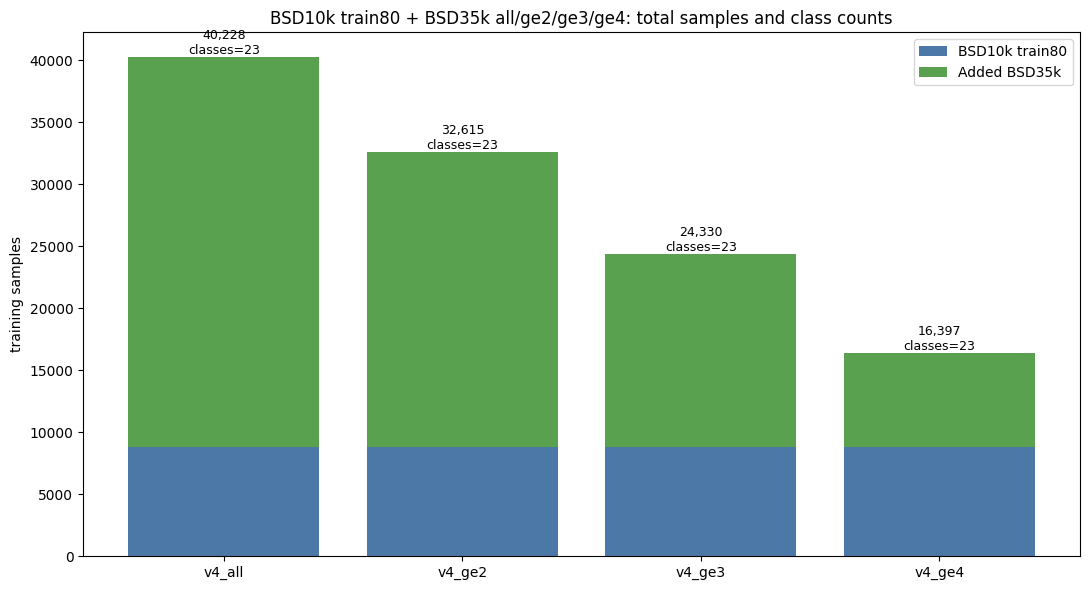

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\bsd10k_train80_plus_bsd35k_combined_counts.png


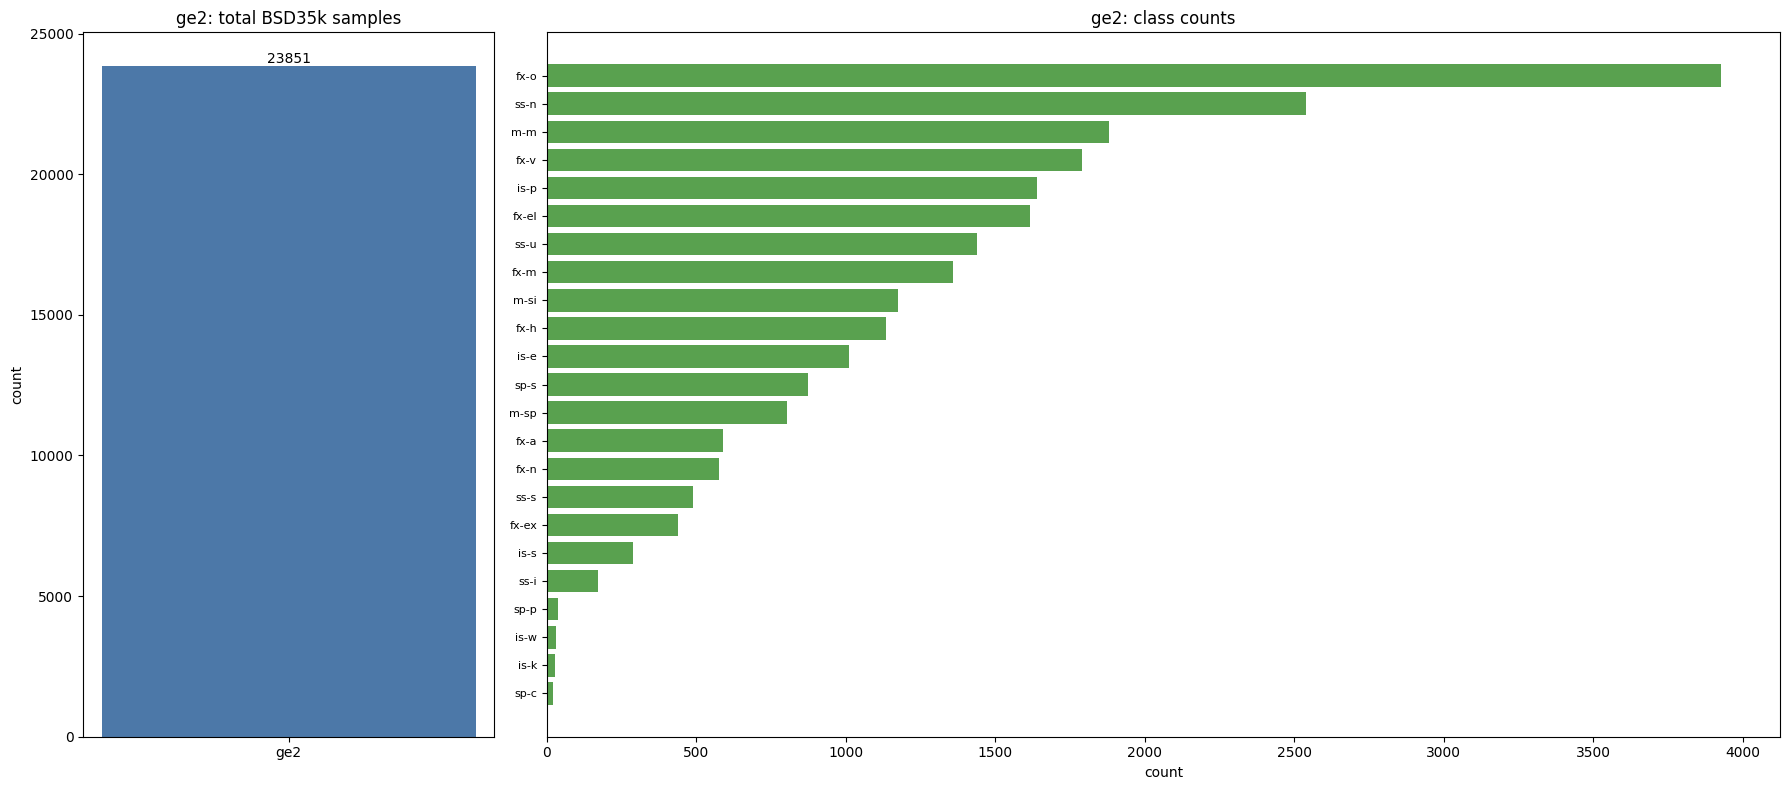

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\bsd35k_ge2_counts.png


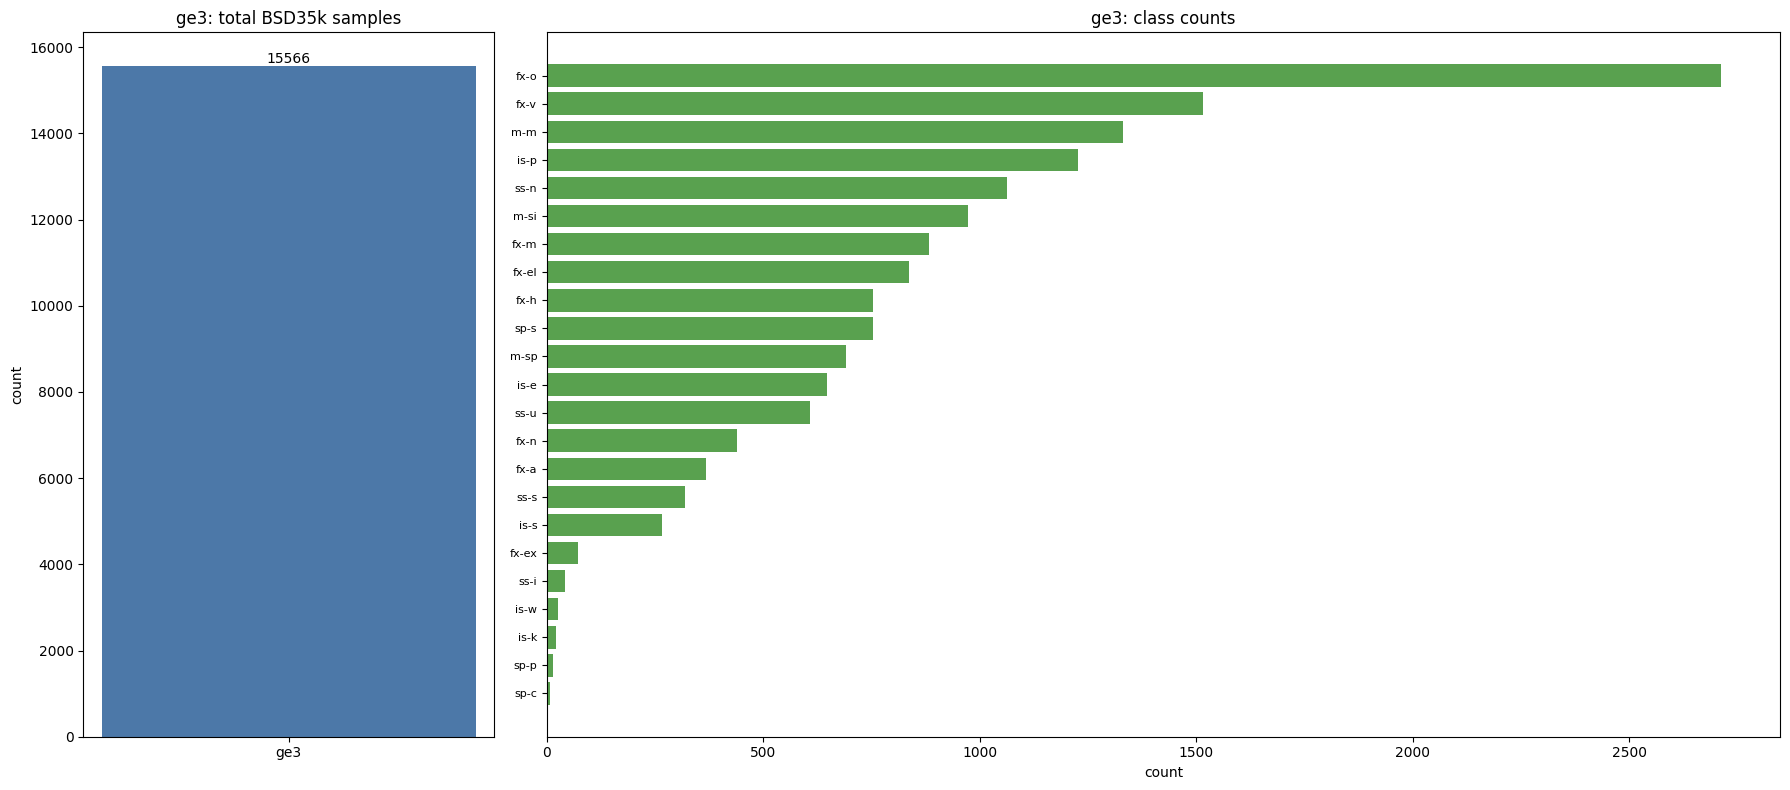

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\bsd35k_ge3_counts.png


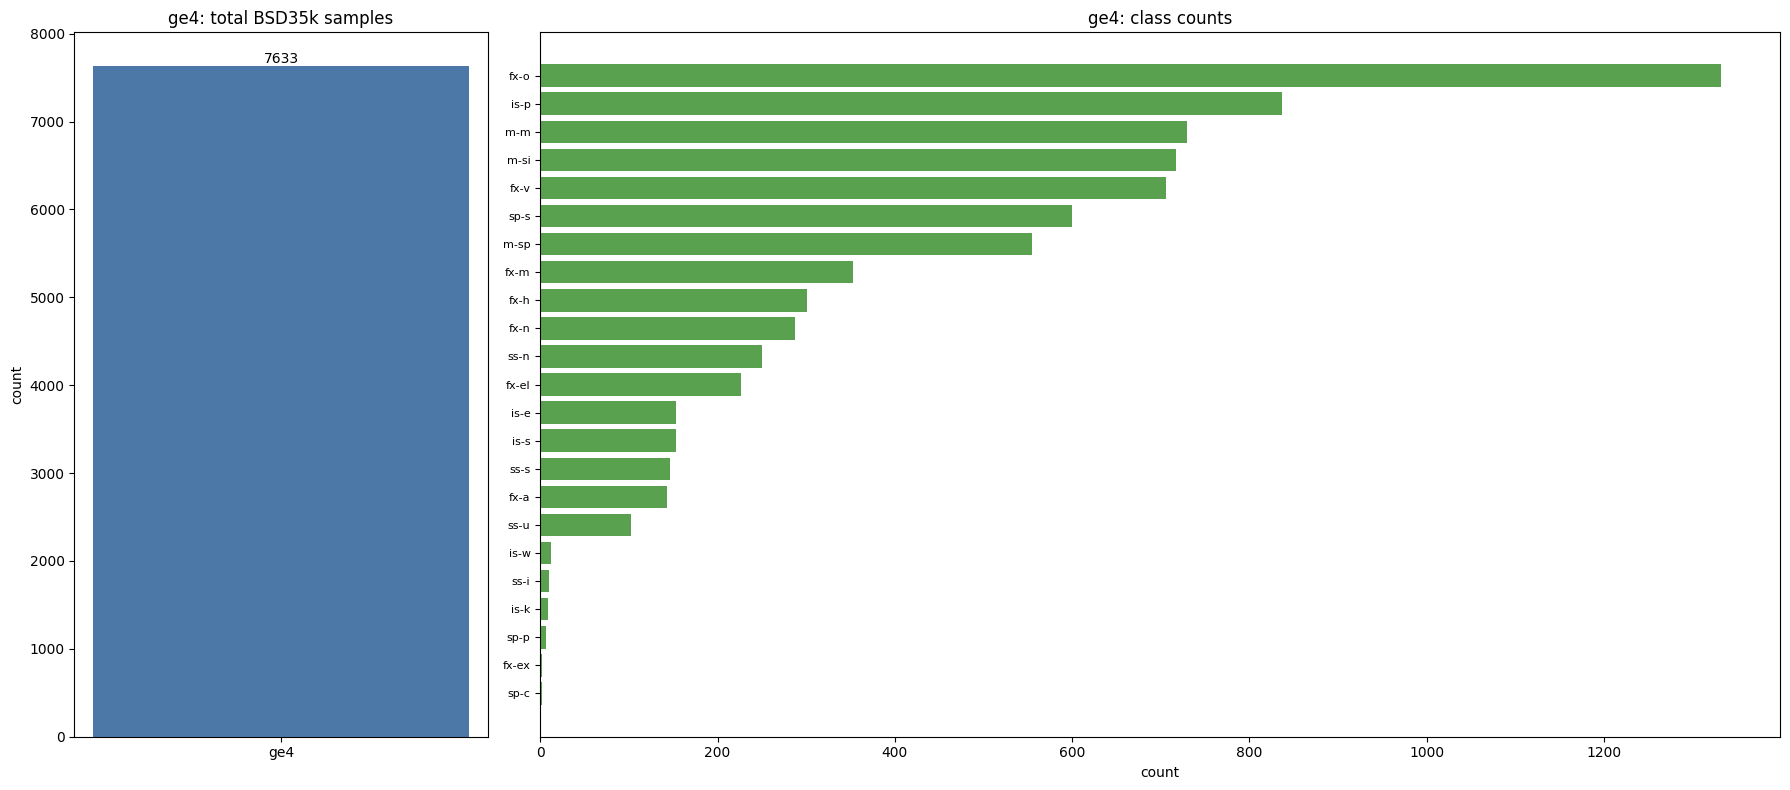

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\bsd35k_ge4_counts.png


In [5]:
THRESHOLD_SPECS = [
    {'label': 'ge2', 'threshold': 2.0},
    {'label': 'ge3', 'threshold': 3.0},
    {'label': 'ge4', 'threshold': 4.0},
]

v4_subsets = {}
for spec in THRESHOLD_SPECS:
    label = spec['label']
    threshold = spec['threshold']
    subset = bsd35k_all[bsd35k_all['predicted_confidence_score'] >= threshold].reset_index(drop=True)
    v4_subsets[label] = subset
    subset.to_csv(DATASET_DIR / f'bsd35k_v4_{label}.csv', index=False)

counts_rows = []
for label, subset in v4_subsets.items():
    counts_rows.append({
        'subset': label,
        'threshold': next(s['threshold'] for s in THRESHOLD_SPECS if s['label'] == label),
        'samples': len(subset),
        'ratio_of_usable_bsd35k': len(subset) / len(bsd35k_all),
        'num_classes': subset['class'].nunique(),
    })

subset_counts = pd.DataFrame(counts_rows)
subset_counts.to_csv(OUTPUT_ROOT / 'v4_bsd35k_subset_counts.csv', index=False)
display(subset_counts)

combined_count_sets = {'v4_all': bsd35k_all, **{f'v4_{label}': subset for label, subset in v4_subsets.items()}}
combined_count_rows = []
for dataset_label, add_df in combined_count_sets.items():
    combined = pd.concat([train_pool, add_df[train_pool.columns]], ignore_index=True)
    combined_count_rows.append({
        'dataset_label': dataset_label,
        'bsd10k_train80_samples': len(train_pool),
        'added_bsd35k_samples': len(add_df),
        'total_train_samples': len(combined),
        'bsd10k_train80_classes': train_pool['class'].nunique(),
        'added_bsd35k_classes': add_df['class'].nunique() if len(add_df) else 0,
        'total_classes': combined['class'].nunique(),
    })

combined_counts = pd.DataFrame(combined_count_rows)
combined_counts.to_csv(OUTPUT_ROOT / 'bsd10k_train80_plus_bsd35k_combined_counts.csv', index=False)
display(combined_counts)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(combined_counts))
ax.bar(x, combined_counts['bsd10k_train80_samples'], label='BSD10k train80', color='#4C78A8')
ax.bar(
    x,
    combined_counts['added_bsd35k_samples'],
    bottom=combined_counts['bsd10k_train80_samples'],
    label='Added BSD35k',
    color='#59A14F',
)
ax.set_xticks(x)
ax.set_xticklabels(combined_counts['dataset_label'], rotation=0)
ax.set_ylabel('training samples')
ax.set_title('BSD10k train80 + BSD35k all/ge2/ge3/ge4: total samples and class counts')
ax.legend(loc='upper right')
for i, row in combined_counts.iterrows():
    ax.text(
        i,
        row['total_train_samples'],
        f"{int(row['total_train_samples']):,}\nclasses={int(row['total_classes'])}",
        ha='center',
        va='bottom',
        fontsize=9,
    )
fig.tight_layout()
combined_counts_plot = PLOTS_DIR / 'bsd10k_train80_plus_bsd35k_combined_counts.png'
fig.savefig(combined_counts_plot, dpi=180, bbox_inches='tight')
plt.show()
print('saved:', combined_counts_plot)

def plot_subset_total_and_class_counts(label: str, subset: pd.DataFrame):
    class_counts = subset['class'].value_counts().sort_values(ascending=True)
    class_counts.to_csv(OUTPUT_ROOT / f'class_counts_{label}.csv', header=['count'])

    fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1, 3]})
    axes[0].bar([label], [len(subset)], color='#4C78A8')
    axes[0].set_title(f'{label}: total BSD35k samples')
    axes[0].set_ylabel('count')
    axes[0].bar_label(axes[0].containers[0], fmt='%d')

    axes[1].barh(class_counts.index.astype(str), class_counts.values, color='#59A14F')
    axes[1].set_title(f'{label}: class counts')
    axes[1].set_xlabel('count')
    axes[1].tick_params(axis='y', labelsize=8)
    fig.tight_layout()
    save_path = PLOTS_DIR / f'bsd35k_{label}_counts.png'
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', save_path)

for label, subset in v4_subsets.items():
    plot_subset_total_and_class_counts(label, subset)

## 4. Build downstream datasets

This version includes the requested unfiltered BSD35k-all addition plus the three v4-filtered BSD35k additions.

In [6]:
addition_sets = {
    'v4_all': bsd35k_all,
    'v4_ge2': v4_subsets['ge2'],
    'v4_ge3': v4_subsets['ge3'],
    'v4_ge4': v4_subsets['ge4'],
}

dataset_rows = []
for label, add_df in addition_sets.items():
    combined = pd.concat([train_pool, add_df[train_pool.columns]], ignore_index=True)
    dataset_path = DATASET_DIR / f'{label}_train_dataset.csv'
    combined.to_csv(dataset_path, index=False)
    add_df.to_csv(DATASET_DIR / f'{label}_added_bsd35k_rows.csv', index=False)
    dataset_rows.append({
        'dataset_label': label,
        'bsd10k_train80_samples': len(train_pool),
        'added_bsd35k_samples': len(add_df),
        'total_train_pool_samples': len(combined),
        'added_bsd35k_classes': add_df['class'].nunique() if len(add_df) else 0,
        'total_classes': combined['class'].nunique(),
        'dataset_csv': str(dataset_path),
    })

dataset_manifest = pd.DataFrame(dataset_rows)
dataset_manifest.to_csv(OUTPUT_ROOT / 'dataset_manifest.csv', index=False)
display(dataset_manifest)

,dataset_label,bsd10k_train80_samples,added_bsd35k_samples,total_train_pool_samples,added_bsd35k_classes,total_classes,dataset_csv
0,v4_all,8764,31464,40228,23,23,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,v4_ge2,8764,23851,32615,23,23,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,v4_ge3,8764,15566,24330,23,23,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,v4_ge4,8764,7633,16397,23,23,c:\Users\solok\Desktop\Dcase baseline\baseline...


## 4b. 계층적 손실 정의 + custom train (loss만 추가)

`cbc.train_and_evaluate_one`(CE 전용)을 그대로 복제하되 학습 루프에만 L_Top·L_Contr를 더한 `train_and_evaluate_one_hier`를 정의한다. 모델·로더·평가·confusion matrix·history 포맷은 baseline과 동일.

In [7]:
import os
import time
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from models import BaseClassifier
from losses import CrossEntropyLoss
from evaluate import evaluate_model
from utils import build_class_to_topclass_mapping, build_class_to_topclass_tensor

# ---- 손실 하이퍼파라미터 (논문 B) ----
LAM_TOP_SWEEP = [0.1, 0.3, 0.5, 1.0]
DEFAULT_LAM_TOP = 0.3
LAM_CONTR = 0.1
TAU = 0.07

def format_lam_top(value: float) -> str:
    return ('lam_top_' + str(value).replace('.', 'p')).replace('-', 'm')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_TOP = len(top_class_dict)
class_to_top = build_class_to_topclass_tensor(class_dict, top_class_dict, device)   # [C] -> top idx
class_to_top_map = build_class_to_topclass_mapping(class_dict, top_class_dict)       # {class_id: top_id}


class TopLevelLoss(nn.Module):
    """미분가능 L_Top: subclass 확률을 top-class로 합산한 top-level NLL."""
    def __init__(self, class_to_top, num_top):
        super().__init__()
        C = class_to_top.numel()
        M = torch.zeros(num_top, C)
        M[class_to_top.cpu(), torch.arange(C)] = 1.0
        self.register_buffer('M', M)

    def forward(self, class_logits, top_labels):
        probs = F.softmax(class_logits, dim=1)
        top_probs = probs @ self.M.t().to(probs.device)
        return F.nll_loss(torch.log(top_probs.clamp_min(1e-8)), top_labels)


class SupConLoss(nn.Module):
    """supervised contrastive. positive = 같은 top-class."""
    def __init__(self, temperature=0.07):
        super().__init__()
        self.t = temperature

    def forward(self, feats, labels):
        feats = F.normalize(feats, dim=1)
        sim = feats @ feats.t() / self.t
        sim = sim - sim.max(dim=1, keepdim=True).values.detach()
        B = feats.size(0)
        self_mask = torch.eye(B, dtype=torch.bool, device=feats.device)
        exp = torch.exp(sim).masked_fill(self_mask, 0.0)
        log_prob = sim - torch.log(exp.sum(1, keepdim=True).clamp_min(1e-12))
        pos = (labels[:, None] == labels[None, :]) & (~self_mask)
        pcount = pos.sum(1)
        loss = -(log_prob * pos).sum(1) / pcount.clamp_min(1)
        loss = loss[pcount > 0]
        return loss.mean() if loss.numel() > 0 else feats.new_tensor(0.0)


def train_model_hier(model, train_loader, val_loader, device, num_epochs, lr, output_dir,
                     lam_top=DEFAULT_LAM_TOP, lam_contr=LAM_CONTR, tau=TAU, patience=5, early_stopping_factor=3):
    """baseline train_model과 동일(Adam wd=1e-5, StepLR 20/0.5, val=acc, 동일 checkpoint/early-stop/history)
    + 학습 손실에 L_Top·L_Contr 추가."""
    os.makedirs(output_dir, exist_ok=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
    ce = CrossEntropyLoss()
    ltop = TopLevelLoss(class_to_top, NUM_TOP).to(device)
    sup = SupConLoss(tau)
    best_accuracy = 0.0
    epochs_without_improvement = 0
    history = defaultdict(list)
    for epoch in range(num_epochs):
        model.train()
        agg = {'total': 0.0, 'cls': 0.0, 'top': 0.0, 'contr': 0.0}
        total_samples = 0
        for data in train_loader:
            class_labels = data['class_idx'].to(device)
            top_labels = data['top_class_idx'].to(device)
            audio_emb = data.get('audio_embedding', None)
            text_emb = data.get('text_embedding', None)
            if audio_emb is not None:
                audio_emb = audio_emb.to(device)
            if text_emb is not None:
                text_emb = text_emb.to(device)
            optimizer.zero_grad()
            z, class_logit, _ = model(audio_emb, text_emb)
            l_cls = ce(class_logit, class_labels)
            l_top = ltop(class_logit, top_labels) if lam_top > 0 else class_logit.new_tensor(0.0)
            l_co = sup(z, top_labels) if lam_contr > 0 else class_logit.new_tensor(0.0)
            loss = l_cls + lam_top * l_top + lam_contr * l_co
            loss.backward()
            optimizer.step()
            bs = class_labels.size(0)
            total_samples += bs
            agg['total'] += loss.item() * bs
            agg['cls'] += l_cls.item() * bs
            agg['top'] += float(l_top) * bs
            agg['contr'] += float(l_co) * bs
        for k in agg:
            history[f'train_{k}_loss'].append(agg[k] / total_samples)
        history['learning_rates'].append(optimizer.param_groups[0]['lr'])

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for data in val_loader:
                labels = data['class_idx'].to(device)
                audio_emb = data.get('audio_embedding', None)
                text_emb = data.get('text_embedding', None)
                if audio_emb is not None:
                    audio_emb = audio_emb.to(device)
                if text_emb is not None:
                    text_emb = text_emb.to(device)
                _, class_logit, _ = model(audio_emb, text_emb)
                _, pred = torch.max(class_logit.data, 1)
                total += labels.size(0)
                correct += (pred == labels).sum().item()
        val_acc = 100 * correct / total
        history['val_accuracy'].append(val_acc)
        with open(os.path.join(output_dir, 'history.json'), 'w') as f:
            json.dump(cbc.make_serializable(dict(history)), f, indent=2)
        print(f"Epoch [{epoch + 1}/{num_epochs}] - Val acc: {val_acc:.2f}%")
        scheduler.step()
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            epochs_without_improvement = 0
            model_config = {'hidden_size': model.hidden_size, 'num_classes': model.num_classes,
                            'emb_size_audio': model.emb_size_audio, 'emb_size_text': model.emb_size_text,
                            'dropout': model.dropout, 'use_batch_norm': True, 'mode': model.mode}
            torch.save({'model_state': model.state_dict(), 'config': model_config},
                       os.path.join(output_dir, 'best_model.pth'))
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience * early_stopping_factor:
                print('Early stopping triggered.')
                break
    return best_accuracy, dict(history), model


def train_and_evaluate_one_hier(train_df, val_df, final_test_df, class_dict, top_class_dict, output_dir,
                                mode='both', seed=SEED, batch_size=64, num_epochs=100, lr=0.001,
                                patience=5, early_stopping_factor=3, lam_top=DEFAULT_LAM_TOP,
                                lam_contr=LAM_CONTR, tau=TAU):
    """cbc.train_and_evaluate_one과 동일 구조; train_model_hier만 사용."""
    cbc.seed_everything(seed)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    emb_a = 512 if mode in ['audio', 'both'] else 0
    emb_t = 512 if mode in ['text', 'both'] else 0
    model = BaseClassifier(hidden_size=128, num_classes=len(class_dict), emb_size_audio=emb_a,
                           emb_size_text=emb_t, dropout=0.1, use_batch_norm=True, mode=mode).to(device)
    model.apply(cbc.init_weights)
    train_loader = cbc.build_loader(train_df, batch_size=batch_size, shuffle=True, aug=True)
    val_loader = cbc.build_loader(val_df, batch_size=batch_size, shuffle=False, aug=False)
    test_loader = cbc.build_loader(final_test_df, batch_size=batch_size, shuffle=False, aug=False)
    print(f"\n[hier run] {output_dir}\n  samples: train={len(train_df)}, val={len(val_df)}, test={len(final_test_df)}"
          f"  | lam_top={lam_top}, lam_contr={lam_contr}, tau={tau}")
    started = time.time()
    best_acc, history, trained = train_model_hier(model, train_loader, val_loader, device,
                                                  num_epochs, lr, str(output_dir),
                                                  lam_top=lam_top, lam_contr=lam_contr, tau=tau,
                                                  patience=patience, early_stopping_factor=early_stopping_factor)
    elapsed = (time.time() - started) / 60.0
    history['model_info'] = {'model_class': trained.__class__.__name__, 'mode': mode, 'batch_size': batch_size,
                             'num_epochs': num_epochs, 'random_seed': seed,
                             'lam_top': lam_top, 'lam_contr': lam_contr, 'tau': tau,
                             'elapsed_train_minutes': float(elapsed)}
    with open(output_dir / 'history.json', 'w', encoding='utf-8') as f:
        json.dump(cbc.make_serializable(history), f, indent=2, ensure_ascii=False)
    metrics = evaluate_model(model_class=BaseClassifier, model_path=str(output_dir / 'best_model.pth'),
                             data_loader=test_loader, device=device, class_to_topclass=class_to_top_map,
                             output_dir=str(output_dir), fold_id='final_test', class_dict=class_dict)
    cbc.write_confusion_matrix(output_dir, class_dict, title=f'{output_dir.name} hier confusion matrix')
    print(f'  completed in {elapsed:.1f} min')
    return best_acc, metrics

print('hier losses + train_and_evaluate_one_hier ready | lam_top sweep=%s lam_contr=%.2f tau=%.2f' % (LAM_TOP_SWEEP, LAM_CONTR, TAU))

hier losses + train_and_evaluate_one_hier ready | lam_top sweep=[0.1, 0.3, 0.5, 1.0] lam_contr=0.10 tau=0.07


## 5. Train DCASE baseline on each dataset

This uses the same model and evaluation code from `dcase2026_task1_baseline` via `confidence_baseline_common.train_and_evaluate_one`.

To reduce runtime while debugging, edit `RUN_DATASET_LABELS` before executing the cell.

In [8]:
RUN_DATASET_LABELS = [
    'v4_all',
    'v4_ge2',
    'v4_ge3',
    'v4_ge4',
]

def make_combined_dataset(addition_df: pd.DataFrame) -> pd.DataFrame:
    if len(addition_df) == 0:
        return train_pool.reset_index(drop=True).copy()
    return pd.concat([train_pool, addition_df[train_pool.columns]], ignore_index=True).reset_index(drop=True)

def run_one_dataset(dataset_label: str, combined_df: pd.DataFrame) -> list[dict]:
    rows = []
    dataset_dir = OUTPUT_ROOT / dataset_label
    dataset_dir.mkdir(parents=True, exist_ok=True)
    combined_df.to_csv(dataset_dir / 'combined_train_pool.csv', index=False)

    splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    splits = list(splitter.split(np.zeros(len(combined_df)), combined_df['class_idx']))

    for lam_top in LAM_TOP_SWEEP:
        lam_tag = format_lam_top(lam_top)
        for mode in BASELINE_MODES:
            for fold, (train_idx, val_idx) in enumerate(splits):
                split_name = f'fold_{fold}'
                run_dir = dataset_dir / lam_tag / mode / split_name
                tr_df = combined_df.iloc[train_idx].reset_index(drop=True)
                va_df = combined_df.iloc[val_idx].reset_index(drop=True)

                base_row = {
                    'dataset_label': dataset_label,
                    'lam_top': float(lam_top),
                    'lam_tag': lam_tag,
                    'lam_contr': float(LAM_CONTR),
                    'tau': float(TAU),
                    'mode': mode,
                    'split': split_name,
                    'train_pool_samples_before_kfold': int(len(combined_df)),
                    'train_samples': int(len(tr_df)),
                    'val_samples': int(len(va_df)),
                    'final_test_samples': int(len(final_test)),
                    'bsd10k_train80_samples': int(len(train_pool)),
                    'added_bsd35k_samples': int(max(len(combined_df) - len(train_pool), 0)),
                    'output_dir': str(run_dir),
                }

                metrics_path = run_dir / 'evaluation' / 'results.txt'
                if metrics_path.exists():
                    metrics = cbc.read_metrics_file(metrics_path)
                    rows.append({**base_row, 'status': 'completed_existing', **metrics})
                    print('[skip] existing completed run:', run_dir)
                    continue

                best_val_acc, metrics = train_and_evaluate_one_hier(
                    tr_df,
                    va_df,
                    final_test,
                    class_dict,
                    top_class_dict,
                    run_dir,
                    mode=mode,
                    seed=SEED,
                    batch_size=BATCH_SIZE,
                    num_epochs=NUM_EPOCHS,
                    lr=0.001,
                    patience=5,
                    early_stopping_factor=3,
                    lam_top=lam_top,
                    lam_contr=LAM_CONTR,
                    tau=TAU,
                )
                rows.append({**base_row, 'status': 'ok', 'best_val_accuracy': float(best_val_acc), **metrics})
                pd.DataFrame(rows).to_csv(dataset_dir / 'summary_results_partial.csv', index=False)
    return rows

all_rows = []
for dataset_label in RUN_DATASET_LABELS:
    print('\n' + '=' * 100)
    print('Running dataset:', dataset_label)
    combined_df = make_combined_dataset(addition_sets[dataset_label])
    rows = run_one_dataset(dataset_label, combined_df)
    all_rows.extend(rows)
    pd.DataFrame(all_rows).to_csv(OUTPUT_ROOT / 'summary_results.csv', index=False)

summary = pd.DataFrame(all_rows)
summary.to_csv(OUTPUT_ROOT / 'summary_results.csv', index=False)
display(summary)


Running dataset: v4_all
[skip] existing completed run: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\v4_all\lam_top_0p1\both\fold_0
[skip] existing completed run: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\v4_all\lam_top_0p1\both\fold_1
[skip] existing completed run: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\v4_all\lam_top_0p1\both\fold_2
[skip] existing completed run: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\v4_all\lam_top_0p1\both\fold_3
[skip] existing completed run: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\v4_all\lam_top_0p1\both\fold_4
[skip] existing completed run: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\v4_all\lam_top_0p3\both\fold_0
[skip] existing completed run: c:\Users\solok\Desktop\Dcase baseline\baseli

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 77.01%
[BaseClassifier | Fold final_test] Top class accuracy: 87.23%
[BaseClassifier | Fold final_test] Macro accuracy: 70.84%
[BaseClassifier | Fold final_test] Macro top class accuracy: 82.39%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 76.62%
[BaseClassifier | Fold final_test] Hierarchical precision: 77.78%
[BaseClassifier | Fold final_test] Hierarchical recall: 75.17%
[BaseClassifier | Fold final_test] Hierarchical F1: 75.55%
  completed in 32.5 min

[hier run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\v4_all\lam_top_0p5\both\fold_1
  samples: train=32182, val=8046, test=2192  | lam_top=0.5, lam_contr=0.1, tau=0.07
Epoch [1/100] - Val acc: 69.16%
Epoch [2/100] - Val acc: 74.72%
Epoch [3/100] - Val acc: 76.55%
Epoch [4/100] - Val acc: 77.32%
Epoch [5/100] - Val acc: 78.19%
Epoch [6/100] - Val acc: 78.72%
Epoch [7/100] - Val acc: 79.38%
Epoch [8/100] - Val acc: 80.21%
Epoch [9/100

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 77.51%
[BaseClassifier | Fold final_test] Top class accuracy: 86.86%
[BaseClassifier | Fold final_test] Macro accuracy: 70.47%
[BaseClassifier | Fold final_test] Macro top class accuracy: 82.02%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 76.24%
[BaseClassifier | Fold final_test] Hierarchical precision: 77.75%
[BaseClassifier | Fold final_test] Hierarchical recall: 74.80%
[BaseClassifier | Fold final_test] Hierarchical F1: 75.61%
  completed in 28.1 min

[hier run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\v4_all\lam_top_0p5\both\fold_2
  samples: train=32182, val=8046, test=2192  | lam_top=0.5, lam_contr=0.1, tau=0.07
Epoch [1/100] - Val acc: 72.35%
Epoch [2/100] - Val acc: 76.06%
Epoch [3/100] - Val acc: 77.79%
Epoch [4/100] - Val acc: 78.13%
Epoch [5/100] - Val acc: 78.34%
Epoch [6/100] - Val acc: 79.48%
Epoch [7/100] - Val acc: 79.73%
Epoch [8/100] - Val acc: 79.82%
Epoch [9/100

...

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 79.47%
[BaseClassifier | Fold final_test] Top class accuracy: 88.96%
[BaseClassifier | Fold final_test] Macro accuracy: 74.30%
[BaseClassifier | Fold final_test] Macro top class accuracy: 85.55%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 79.93%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.16%
[BaseClassifier | Fold final_test] Hierarchical recall: 78.52%
[BaseClassifier | Fold final_test] Hierarchical F1: 78.60%
  completed in 7.0 min

[hier run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\v4_ge4\lam_top_1p0\both\fold_4
  samples: train=13118, val=3279, test=2192  | lam_top=1.0, lam_contr=0.1, tau=0.07
Epoch [1/100] - Val acc: 64.71%
Epoch [2/100] - Val acc: 70.66%
Epoch [3/100] - Val acc: 75.60%
Epoch [4/100] - Val acc: 77.74%
Epoch [5/100] - Val acc: 78.13%
Epoch [6/100] - Val acc: 78.90%
Epoch [7/100] - Val acc: 79.75%
Epoch [8/100] - Val acc: 79.17%
Epoch [9/100]

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 79.43%
[BaseClassifier | Fold final_test] Top class accuracy: 88.78%
[BaseClassifier | Fold final_test] Macro accuracy: 73.45%
[BaseClassifier | Fold final_test] Macro top class accuracy: 84.48%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 78.96%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.64%
[BaseClassifier | Fold final_test] Hierarchical recall: 77.58%
[BaseClassifier | Fold final_test] Hierarchical F1: 78.22%
  completed in 10.7 min


,dataset_label,lam_top,lam_tag,lam_contr,tau,mode,split,train_pool_samples_before_kfold,train_samples,val_samples,...,status,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,best_val_accuracy
0,v4_all,0.1,lam_top_0p1,0.1,0.07,both,fold_0,40228,32182,8046,...,completed_existing,77.460000,86.680000,71.030000,81.930000,76.480000,76.680000,75.120000,75.530000,NaN
1,v4_all,0.1,lam_top_0p1,0.1,0.07,both,fold_1,40228,32182,8046,...,completed_existing,76.690000,86.410000,69.480000,81.240000,75.360000,75.800000,73.890000,74.360000,NaN
2,v4_all,0.1,lam_top_0p1,0.1,0.07,both,fold_2,40228,32182,8046,...,completed_existing,76.730000,86.950000,69.750000,81.800000,75.770000,77.510000,74.270000,74.970000,NaN
3,v4_all,0.1,lam_top_0p1,0.1,0.07,both,fold_3,40228,32183,8045,...,completed_existing,76.870000,86.860000,69.800000,81.610000,75.700000,75.940000,74.230000,74.540000,NaN
4,v4_all,0.1,lam_top_0p1,0.1,0.07,both,fold_4,40228,32183,8045,...,completed_existing,77.420000,86.950000,71.330000,82.920000,77.120000,77.460000,75.680000,76.050000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,v4_ge4,1.0,lam_top_1p0,0.1,0.07,both,fold_0,16397,13117,3280,...,ok,79.698905,88.503650,73.346521,84.303710,78.825116,78.765464,77.455467,77.718165,83.018293
76,v4_ge4,1.0,lam_top_1p0,0.1,0.07,both,fold_1,16397,13117,3280,...,ok,77.919708,88.047445,71.423700,82.912296,77.167998,76.633625,75.731924,75.863018,83.963415
77,v4_ge4,1.0,lam_top_1p0,0.1,0.07,both,fold_2,16397,13118,3279,...,ok,79.242701,88.458029,72.752004,83.439773,78.095889,78.315115,76.759918,77.292658,84.354986
78,v4_ge4,1.0,lam_top_1p0,0.1,0.07,both,fold_3,16397,13118,3279,...,ok,79.470803,88.959854,74.304068,85.551410,79.927739,79.156044,78.521821,78.598850,83.806038


## 6. View fold-level results

In [9]:
summary_path = OUTPUT_ROOT / 'summary_results.csv'
summary = pd.read_csv(summary_path)
numeric_cols = [
    'lam_top', 'lam_contr', 'tau',
    'best_val_accuracy', 'accuracy', 'top_accuracy', 'macro_accuracy', 'macro_top_accuracy',
    'hierarchical_accuracy', 'hierarchical_precision', 'hierarchical_recall', 'hierarchical_f1',
    'train_pool_samples_before_kfold', 'train_samples', 'val_samples', 'final_test_samples',
    'bsd10k_train80_samples', 'added_bsd35k_samples'
]
for col in numeric_cols:
    if col in summary.columns:
        summary[col] = pd.to_numeric(summary[col], errors='coerce')

view_cols = [
    'dataset_label', 'lam_top', 'lam_tag', 'mode', 'split', 'bsd10k_train80_samples', 'added_bsd35k_samples',
    'train_pool_samples_before_kfold', 'train_samples', 'val_samples', 'final_test_samples',
    'best_val_accuracy', 'accuracy', 'top_accuracy', 'macro_accuracy', 'macro_top_accuracy',
    'hierarchical_accuracy', 'hierarchical_precision', 'hierarchical_recall', 'hierarchical_f1',
    'output_dir'
]
view = summary[[c for c in view_cols if c in summary.columns]].sort_values(
    ['dataset_label', 'lam_top', 'mode', 'split']
).reset_index(drop=True)
view.to_csv(OUTPUT_ROOT / 'all_run_results_view.csv', index=False)

def mean_pm_std(values):
    values = pd.to_numeric(values, errors='coerce').dropna()
    if len(values) == 0:
        return ''
    std = values.std(ddof=1) if len(values) > 1 else 0.0
    return f'{values.mean():.2f}% ± {std:.2f}%'

compact_rows = []
for (dataset_label, lam_top), group in view.groupby(['dataset_label', 'lam_top'], sort=False):
    compact_rows.append({
        'dataset_label': dataset_label,
        'lam_top': lam_top,
        'folds': len(group),
        'added_bsd35k_samples': int(group['added_bsd35k_samples'].iloc[0]),
        'accuracy': mean_pm_std(group['accuracy']),
        'hierarchical_accuracy': mean_pm_std(group['hierarchical_accuracy']),
        'hierarchical_f1': mean_pm_std(group['hierarchical_f1']),
        'macro_accuracy': mean_pm_std(group['macro_accuracy']),
        'top_accuracy': mean_pm_std(group['top_accuracy']),
        'best_val_accuracy': mean_pm_std(group['best_val_accuracy']),
    })

compact_view = pd.DataFrame(compact_rows)
compact_view.to_csv(OUTPUT_ROOT / 'compact_mean_std_view.csv', index=False)
display(compact_view)

,dataset_label,lam_top,folds,added_bsd35k_samples,accuracy,hierarchical_accuracy,hierarchical_f1,macro_accuracy,top_accuracy,best_val_accuracy
0,v4_all,0.1,5,31464,77.03% ± 0.38%,76.09% ± 0.71%,75.09% ± 0.70%,70.28% ± 0.84%,86.77% ± 0.23%,
1,v4_all,0.3,5,31464,77.40% ± 0.33%,76.36% ± 0.41%,75.30% ± 0.36%,70.51% ± 0.56%,87.04% ± 0.31%,
2,v4_all,0.5,5,31464,77.00% ± 0.40%,76.04% ± 0.39%,75.13% ± 0.42%,70.24% ± 0.53%,86.71% ± 0.40%,83.45% ± 0.31%
3,v4_all,1.0,5,31464,77.00% ± 0.52%,76.35% ± 0.58%,75.17% ± 0.75%,70.43% ± 0.68%,86.77% ± 0.64%,83.59% ± 0.29%
4,v4_ge2,0.1,5,23851,77.36% ± 0.80%,77.21% ± 0.89%,75.99% ± 0.82%,71.43% ± 0.99%,87.19% ± 0.60%,84.00% ± 0.30%
5,v4_ge2,0.3,5,23851,77.20% ± 0.74%,77.08% ± 1.06%,75.72% ± 0.84%,71.32% ± 1.53%,86.90% ± 0.32%,83.89% ± 0.23%
6,v4_ge2,0.5,5,23851,78.28% ± 0.46%,77.43% ± 0.52%,76.42% ± 0.49%,71.75% ± 0.68%,87.55% ± 0.25%,83.80% ± 0.44%
7,v4_ge2,1.0,5,23851,77.05% ± 0.39%,76.23% ± 0.27%,75.13% ± 0.31%,70.28% ± 0.40%,86.90% ± 0.51%,83.79% ± 0.32%
8,v4_ge3,0.1,5,15566,78.49% ± 0.47%,77.97% ± 0.56%,76.86% ± 0.59%,72.30% ± 0.80%,87.76% ± 0.18%,83.84% ± 0.27%
9,v4_ge3,0.3,5,15566,78.09% ± 0.79%,77.67% ± 0.18%,76.45% ± 0.26%,71.81% ± 0.22%,87.70% ± 0.36%,83.69% ± 0.31%


## 7. Mean ± std summary

This prints the compact format requested, while the previous cell keeps all fold-level details.

In [10]:
SUMMARY_METRICS = [
    'accuracy',
    'hierarchical_accuracy',
    'hierarchical_f1',
    'hierarchical_precision',
    'hierarchical_recall',
    'macro_accuracy',
    'macro_top_accuracy',
    'top_accuracy',
]

def summarize_mean_std(summary_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (dataset_label, lam_top), group in summary_df.groupby(['dataset_label', 'lam_top'], sort=False):
        row = {'dataset_label': dataset_label, 'lam_top': float(lam_top), 'fold_count': len(group)}
        for col in ['bsd10k_train80_samples', 'added_bsd35k_samples', 'final_test_samples']:
            if col in group.columns:
                row[col] = int(group[col].iloc[0])
        for metric in SUMMARY_METRICS:
            values = pd.to_numeric(group[metric], errors='coerce').dropna()
            row[f'{metric}_mean'] = values.mean() if len(values) else np.nan
            row[f'{metric}_std'] = values.std(ddof=1) if len(values) > 1 else 0.0
        rows.append(row)
    return pd.DataFrame(rows)

fold_summary = summarize_mean_std(summary)
fold_summary.to_csv(OUTPUT_ROOT / 'fold_metric_summary_mean_std.csv', index=False)
display(fold_summary)

for _, row in fold_summary.iterrows():
    label = f"{row['dataset_label']} | lam_top={row['lam_top']}"
    print('\n' + label)
    print('-' * len(label))
    print(f"  folds                   : {int(row['fold_count'])}")
    print(f"  BSD10k train80 samples  : {int(row['bsd10k_train80_samples'])}")
    print(f"  added BSD35k samples    : {int(row['added_bsd35k_samples'])}")
    for metric in SUMMARY_METRICS:
        mean = row[f'{metric}_mean']
        std = row[f'{metric}_std']
        print(f"  {metric:<22}: {mean:.2f}% ± {std:.2f}%")

,dataset_label,lam_top,fold_count,bsd10k_train80_samples,added_bsd35k_samples,final_test_samples,accuracy_mean,accuracy_std,hierarchical_accuracy_mean,hierarchical_accuracy_std,...,hierarchical_precision_mean,hierarchical_precision_std,hierarchical_recall_mean,hierarchical_recall_std,macro_accuracy_mean,macro_accuracy_std,macro_top_accuracy_mean,macro_top_accuracy_std,top_accuracy_mean,top_accuracy_std
0,v4_all,0.1,5,8764,31464,2192,77.034000,0.376869,76.086000,0.707163,...,76.678000,0.809209,74.638000,0.738153,70.278000,0.839089,81.900000,0.626698,86.770000,0.229456
1,v4_all,0.3,5,8764,31464,2192,77.396000,0.325929,76.364000,0.411983,...,77.018000,0.487822,74.898000,0.431358,70.512000,0.564686,82.214000,0.467258,87.044000,0.310371
2,v4_all,0.5,5,8764,31464,2192,76.998175,0.396924,76.042196,0.385421,...,77.251885,0.653739,74.590429,0.409419,70.235126,0.531717,81.849266,0.410750,86.706204,0.397186
3,v4_all,1.0,5,8764,31464,2192,76.998175,0.521552,76.346834,0.582709,...,76.703216,0.892568,74.868075,0.602345,70.431797,0.684580,82.261872,0.553622,86.770073,0.639500
4,v4_ge2,0.1,5,8764,23851,2192,77.363139,0.796335,77.208175,0.892042,...,77.025616,0.952777,75.763044,0.913371,71.427653,0.989892,82.988698,0.831811,87.189781,0.603846
5,v4_ge2,0.3,5,8764,23851,2192,77.198905,0.741525,77.084885,1.056120,...,76.996261,0.595552,75.643211,1.171049,71.318189,1.527265,82.851580,0.643171,86.897810,0.318364
6,v4_ge2,0.5,5,8764,23851,2192,78.275547,0.455520,77.430881,0.518306,...,77.696302,0.517552,76.010566,0.550503,71.749622,0.679104,83.112139,0.471677,87.554745,0.248621
7,v4_ge2,1.0,5,8764,23851,2192,77.052920,0.389781,76.229413,0.269888,...,76.713569,0.390714,74.740974,0.241283,70.275656,0.398833,82.183169,0.610346,86.897810,0.509440
8,v4_ge3,0.1,5,8764,15566,2192,78.494526,0.469248,77.970971,0.558272,...,77.969939,0.684153,76.552805,0.615206,72.298309,0.800169,83.643633,0.382994,87.755474,0.178445
9,v4_ge3,0.3,5,8764,15566,2192,78.093066,0.792405,77.667437,0.179175,...,77.548894,0.623189,76.202355,0.182451,71.807108,0.216336,83.527766,0.209672,87.700730,0.360084



v4_all | lam_top=0.1
--------------------
  folds                   : 5
  BSD10k train80 samples  : 8764
  added BSD35k samples    : 31464
  accuracy              : 77.03% ± 0.38%
  hierarchical_accuracy : 76.09% ± 0.71%
  hierarchical_f1       : 75.09% ± 0.70%
  hierarchical_precision: 76.68% ± 0.81%
  hierarchical_recall   : 74.64% ± 0.74%
  macro_accuracy        : 70.28% ± 0.84%
  macro_top_accuracy    : 81.90% ± 0.63%
  top_accuracy          : 86.77% ± 0.23%

v4_all | lam_top=0.3
--------------------
  folds                   : 5
  BSD10k train80 samples  : 8764
  added BSD35k samples    : 31464
  accuracy              : 77.40% ± 0.33%
  hierarchical_accuracy : 76.36% ± 0.41%
  hierarchical_f1       : 75.30% ± 0.36%
  hierarchical_precision: 77.02% ± 0.49%
  hierarchical_recall   : 74.90% ± 0.43%
  macro_accuracy        : 70.51% ± 0.56%
  macro_top_accuracy    : 82.21% ± 0.47%
  top_accuracy          : 87.04% ± 0.31%

v4_all | lam_top=0.5
--------------------
  folds              

## 8. Loss curves

The baseline trainer records training loss and validation accuracy. This cell plots training loss for every fold.

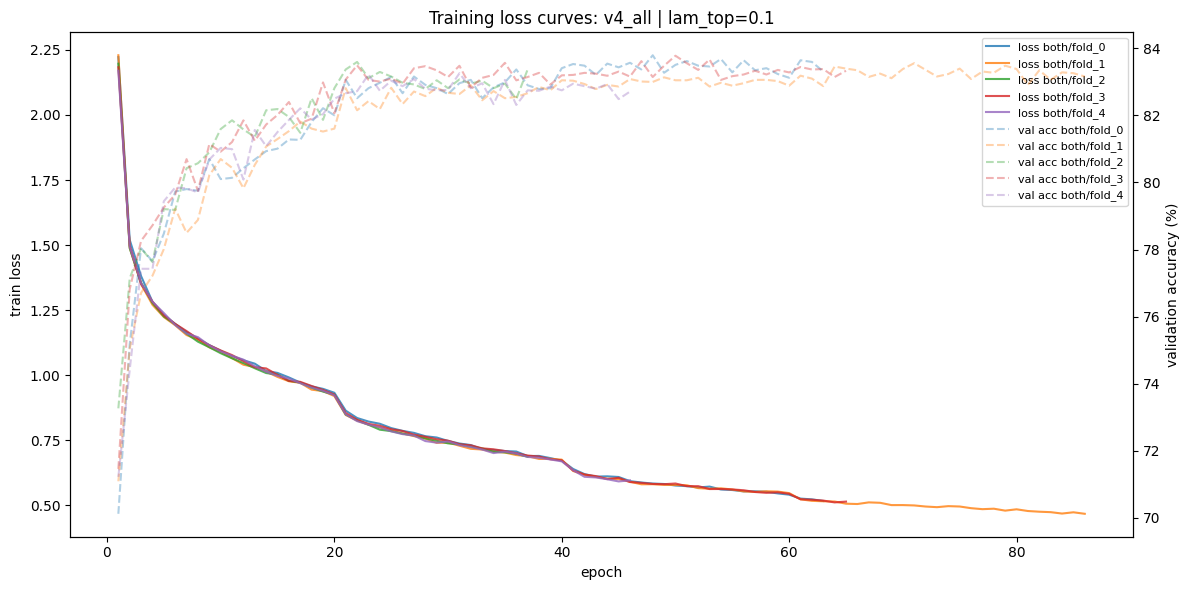

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_all_lam_top_0p1.png


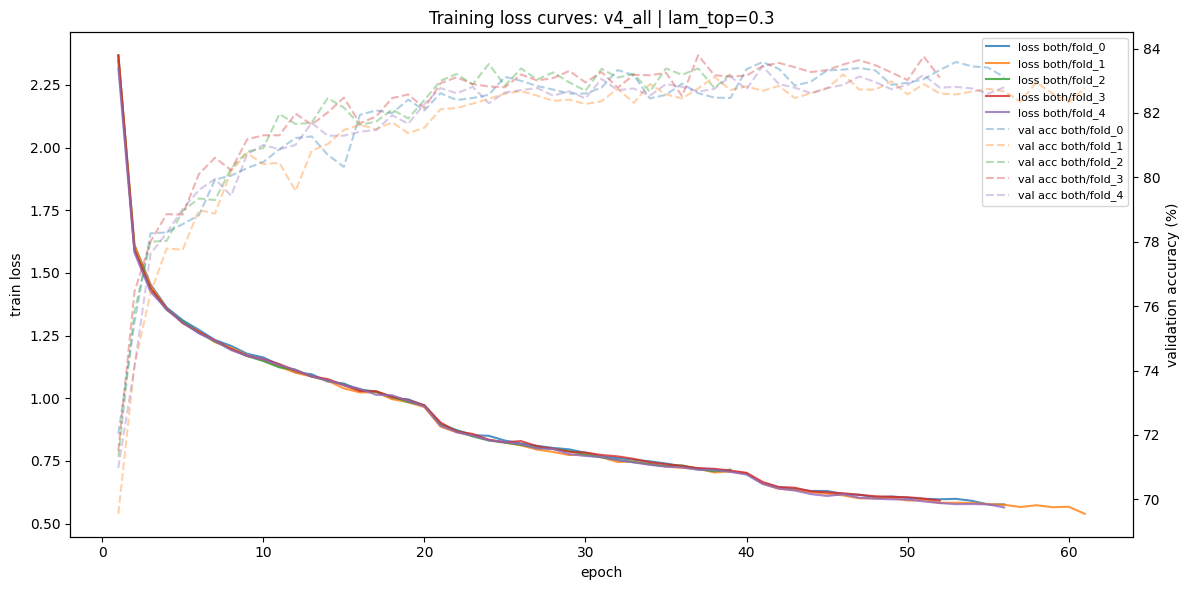

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_all_lam_top_0p3.png


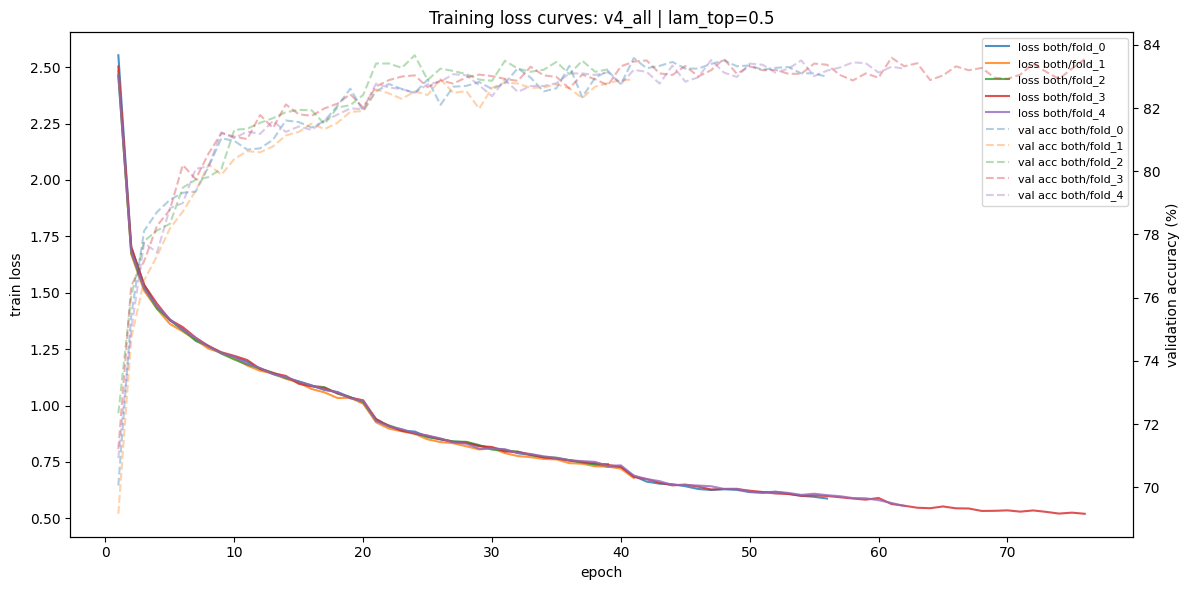

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_all_lam_top_0p5.png


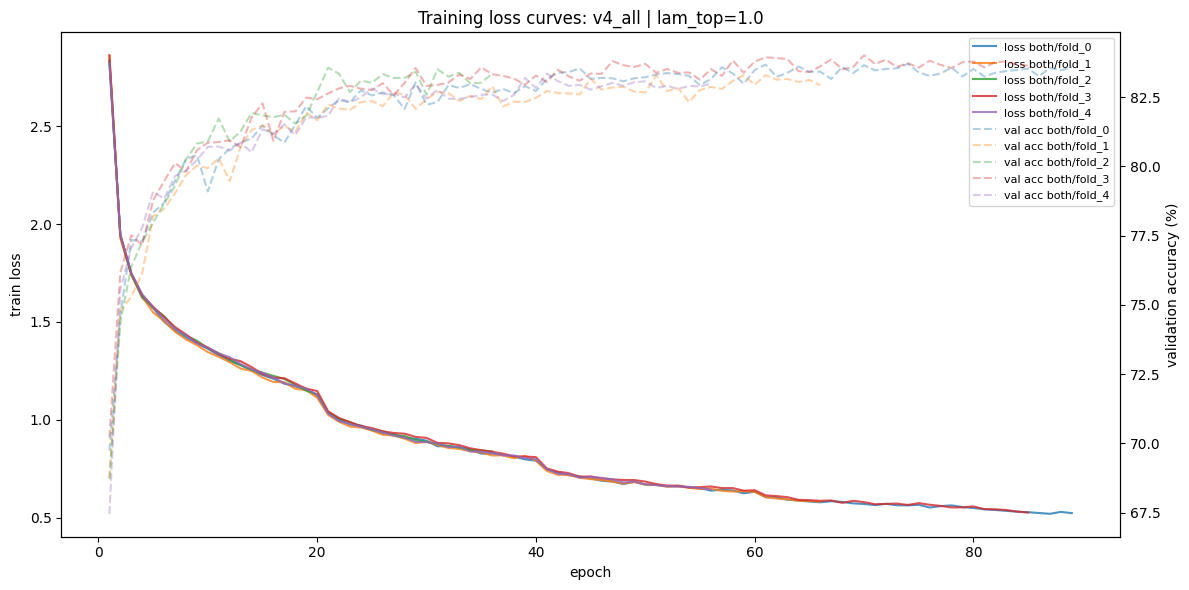

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_all_lam_top_1p0.png


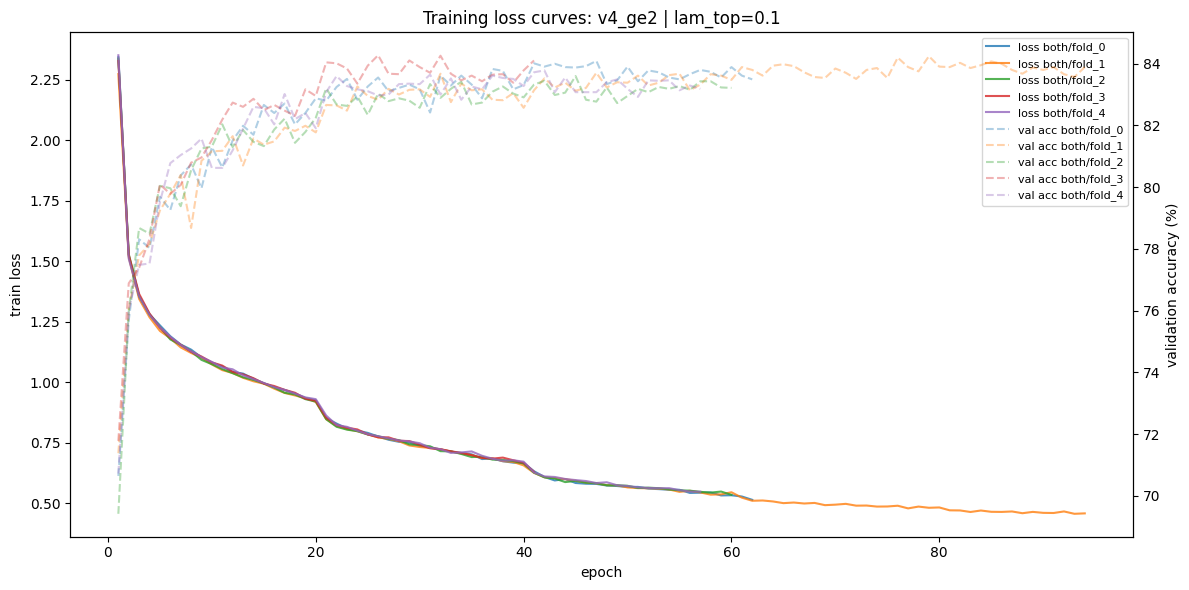

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge2_lam_top_0p1.png


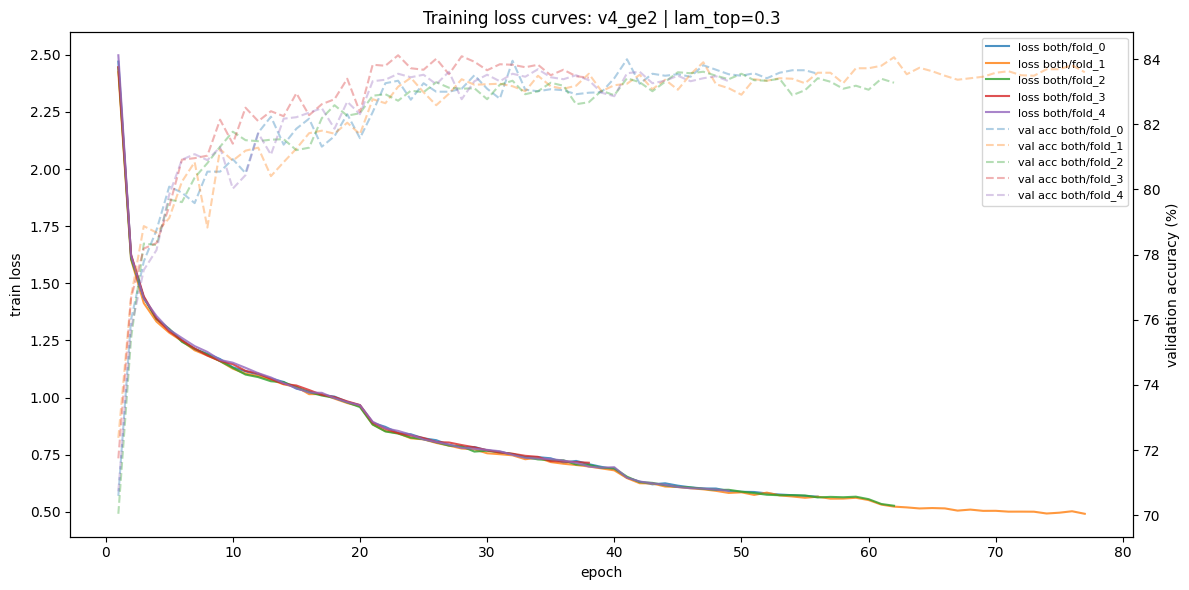

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge2_lam_top_0p3.png


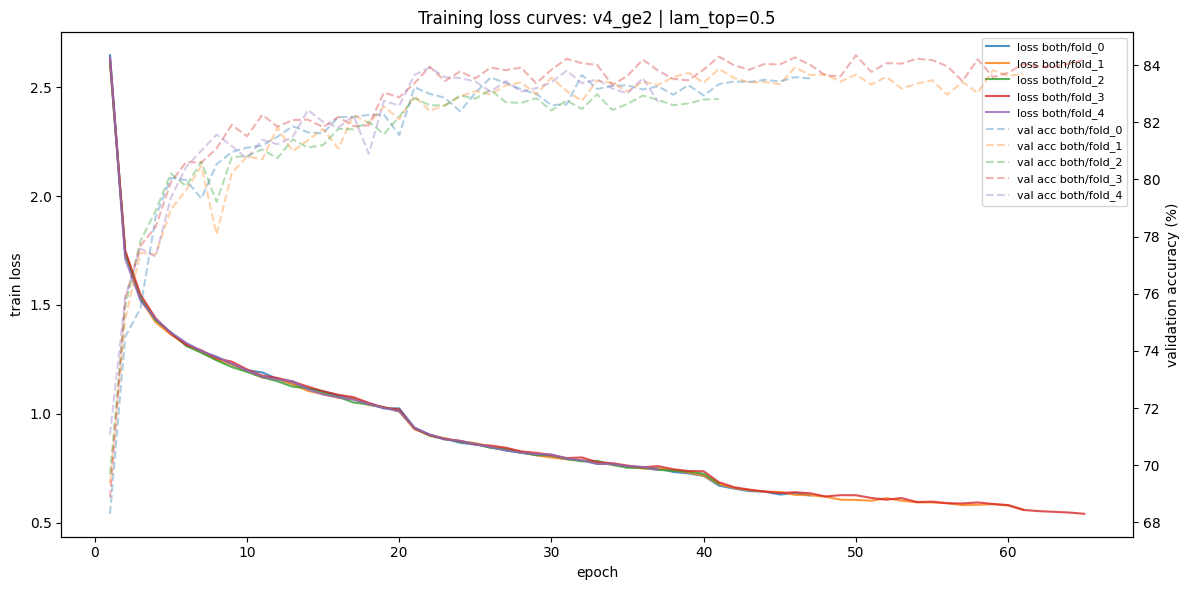

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge2_lam_top_0p5.png


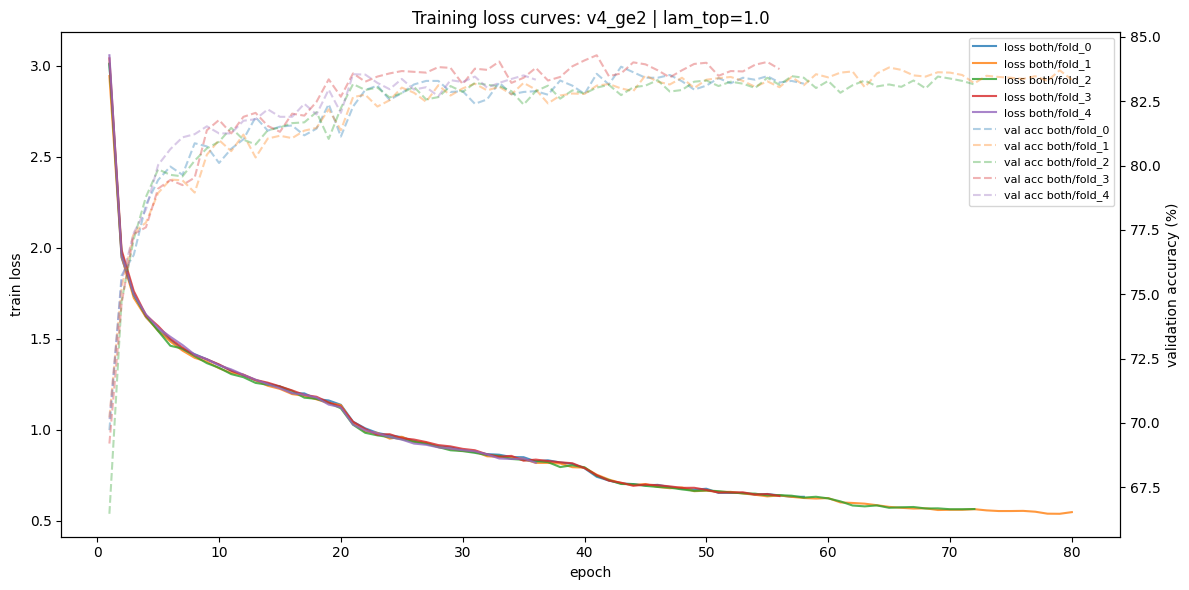

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge2_lam_top_1p0.png


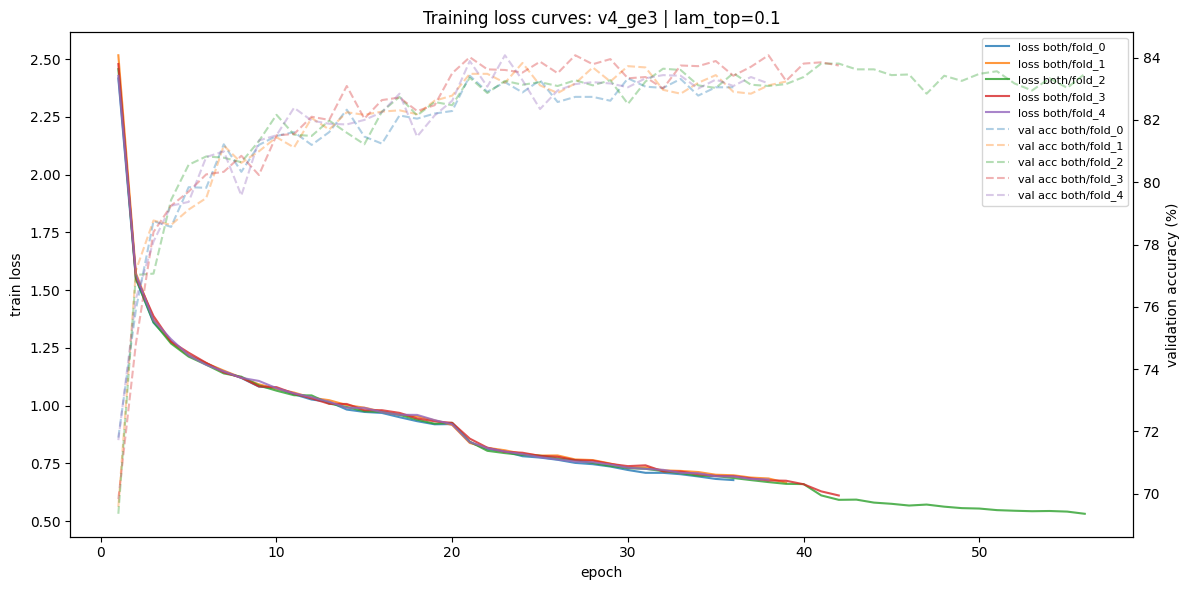

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge3_lam_top_0p1.png


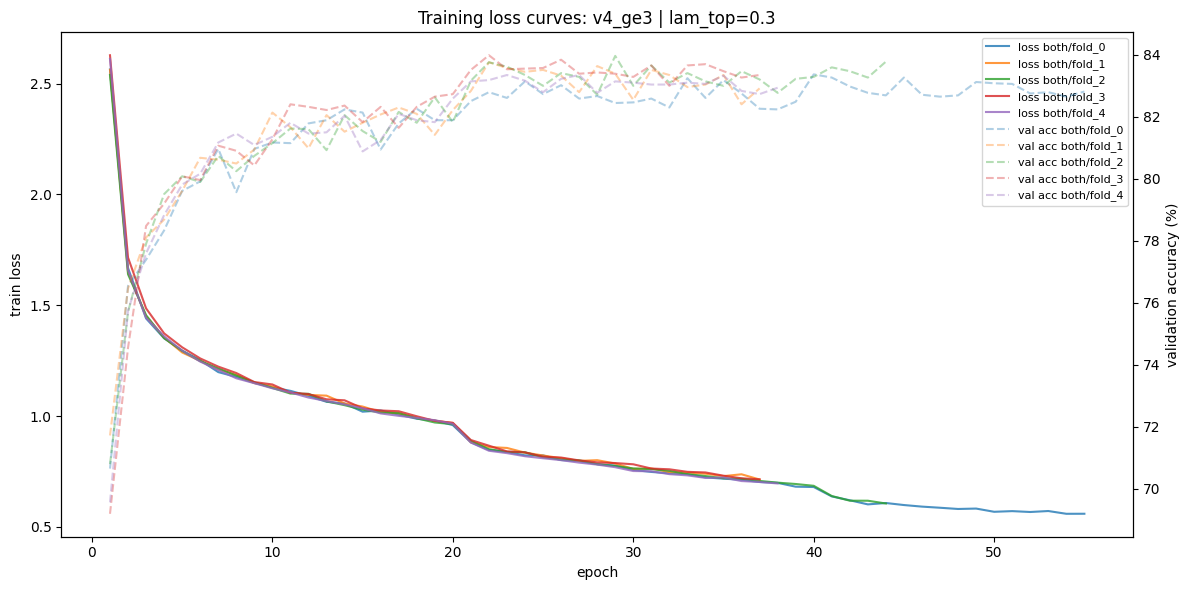

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge3_lam_top_0p3.png


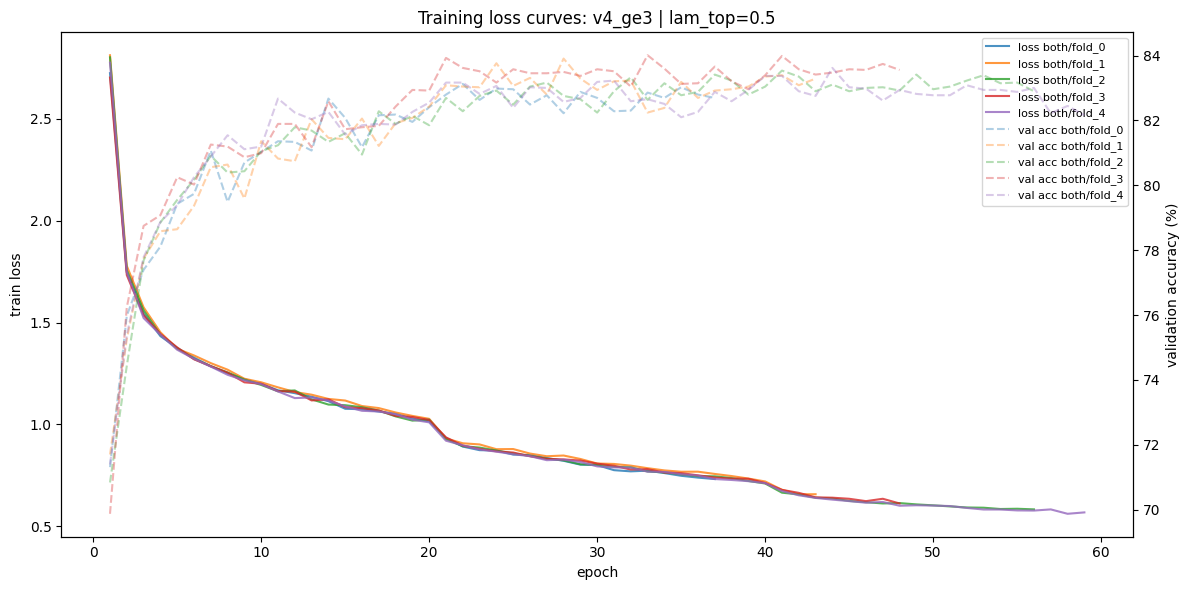

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge3_lam_top_0p5.png


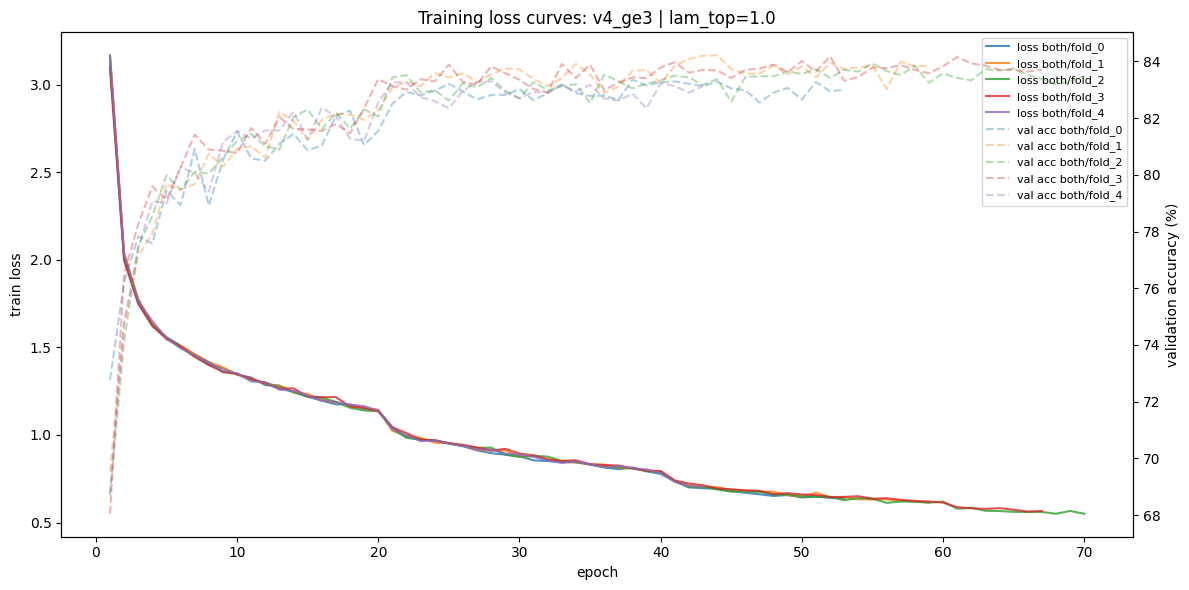

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge3_lam_top_1p0.png


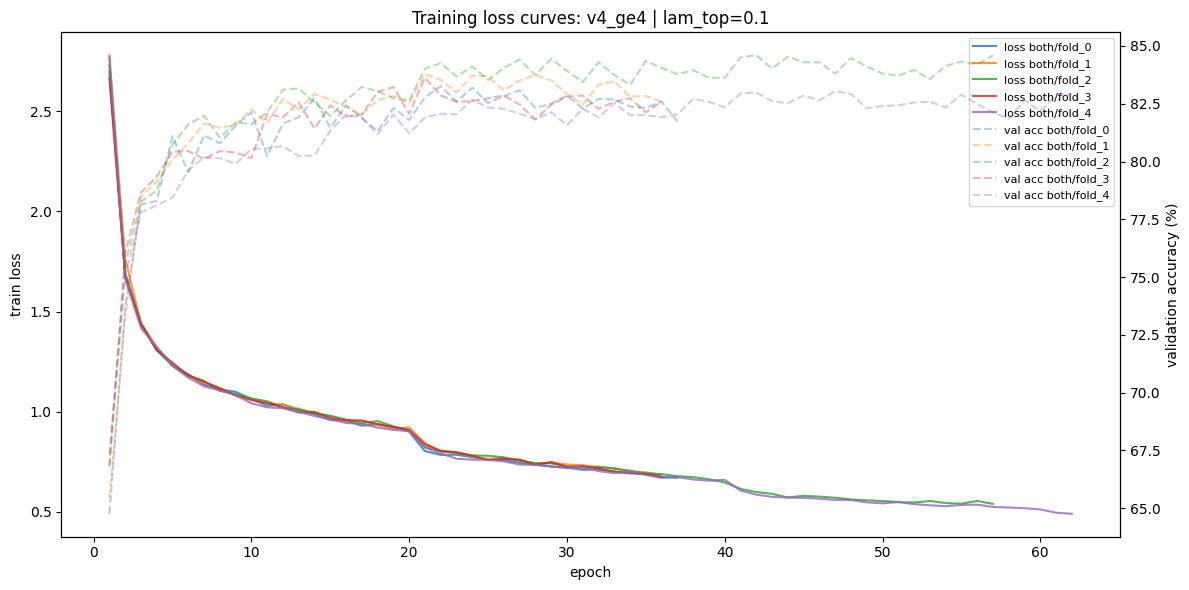

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge4_lam_top_0p1.png


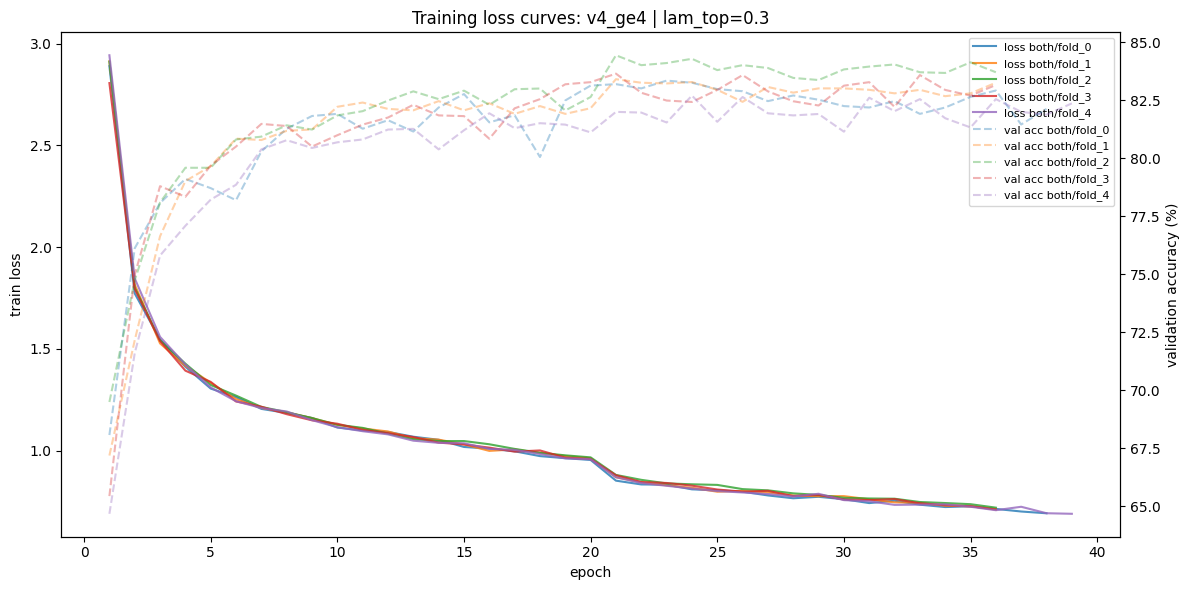

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge4_lam_top_0p3.png


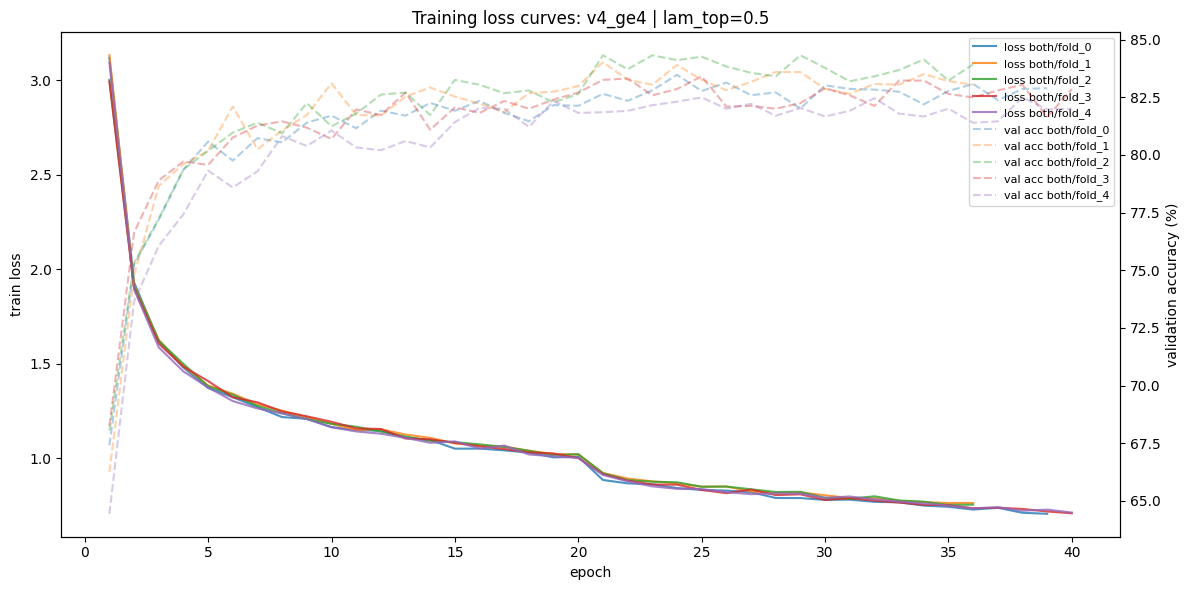

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge4_lam_top_0p5.png


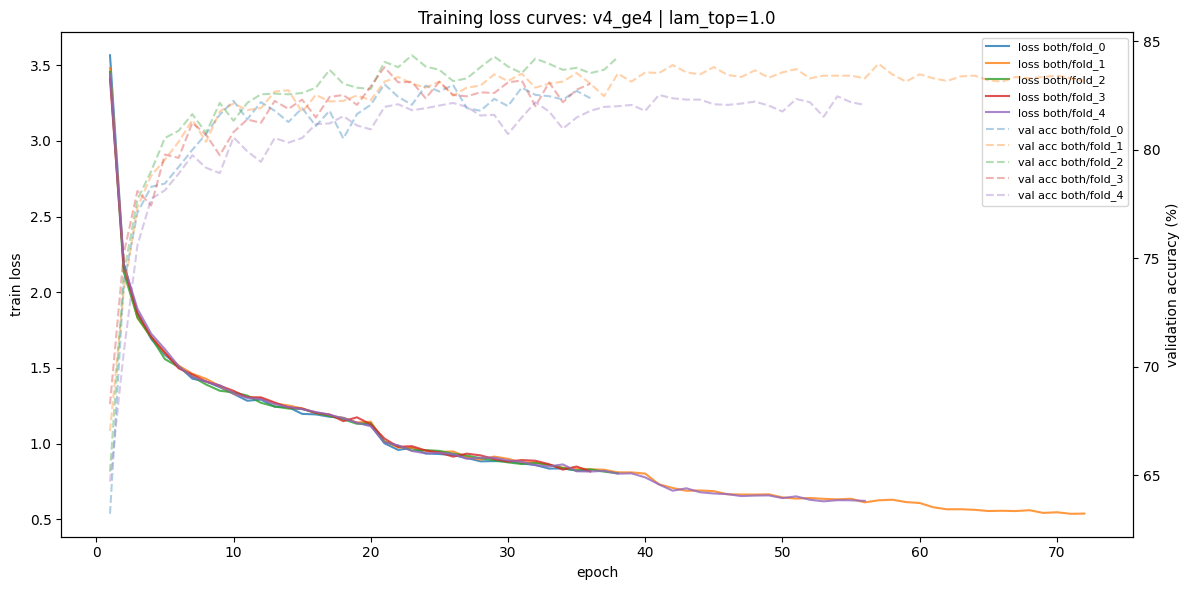

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\loss_curves_v4_ge4_lam_top_1p0.png


In [11]:
def load_history(run_dir: str | Path) -> dict:
    history_path = Path(run_dir) / 'history.json'
    if not history_path.exists():
        return {}
    return json.loads(history_path.read_text(encoding='utf-8'))

def plot_loss_curves(summary_df: pd.DataFrame):
    for (dataset_label, lam_top), group in summary_df.groupby(['dataset_label', 'lam_top'], sort=False):
        fig, ax1 = plt.subplots(figsize=(12, 6))
        ax2 = ax1.twinx()
        plotted = False
        for _, row in group.iterrows():
            hist = load_history(row['output_dir'])
            if not hist:
                continue
            loss = hist.get('train_total_loss') or hist.get('train_cls_loss')
            val_acc = hist.get('val_accuracy')
            label = f"{row['mode']}/{row['split']}"
            if loss:
                ax1.plot(range(1, len(loss) + 1), loss, alpha=0.8, label=f'loss {label}')
                plotted = True
            if val_acc:
                ax2.plot(range(1, len(val_acc) + 1), val_acc, alpha=0.35, linestyle='--', label=f'val acc {label}')
        ax1.set_title(f'Training loss curves: {dataset_label} | lam_top={lam_top}')
        ax1.set_xlabel('epoch')
        ax1.set_ylabel('train loss')
        ax2.set_ylabel('validation accuracy (%)')
        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(handles1 + handles2, labels1 + labels2, fontsize=8, loc='best')
        fig.tight_layout()
        save_path = PLOTS_DIR / f'loss_curves_{dataset_label}_{format_lam_top(lam_top)}.png'
        fig.savefig(save_path, dpi=180, bbox_inches='tight')
        if plotted:
            plt.show()
        else:
            plt.close(fig)
        print('saved:', save_path)

plot_loss_curves(summary)

## 9. Mean confusion matrices across folds

For each `(dataset_label, lam_top)` pair, this cell averages the row-normalized confusion matrices over all folds and annotates each cell as `mean±std`. With 4 datasets and 4 `lam_top` values, this produces 16 mean confusion matrices.

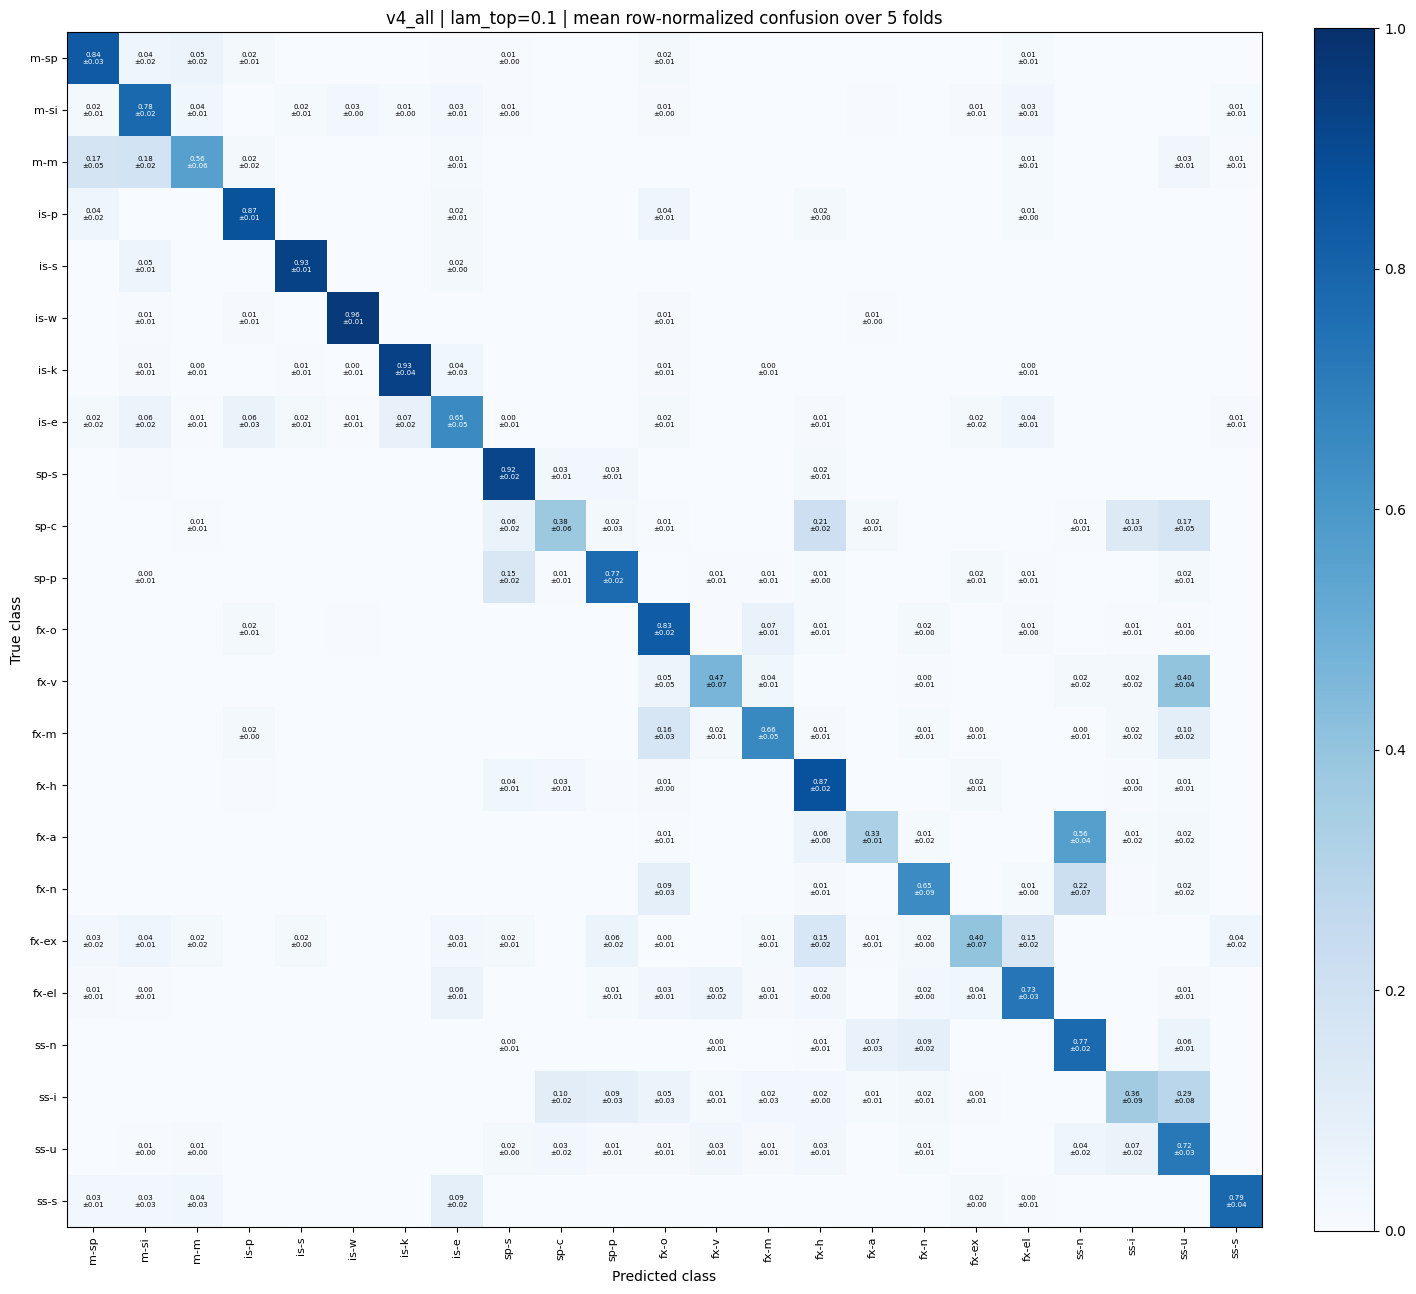

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_all_lam_top_0p1.png


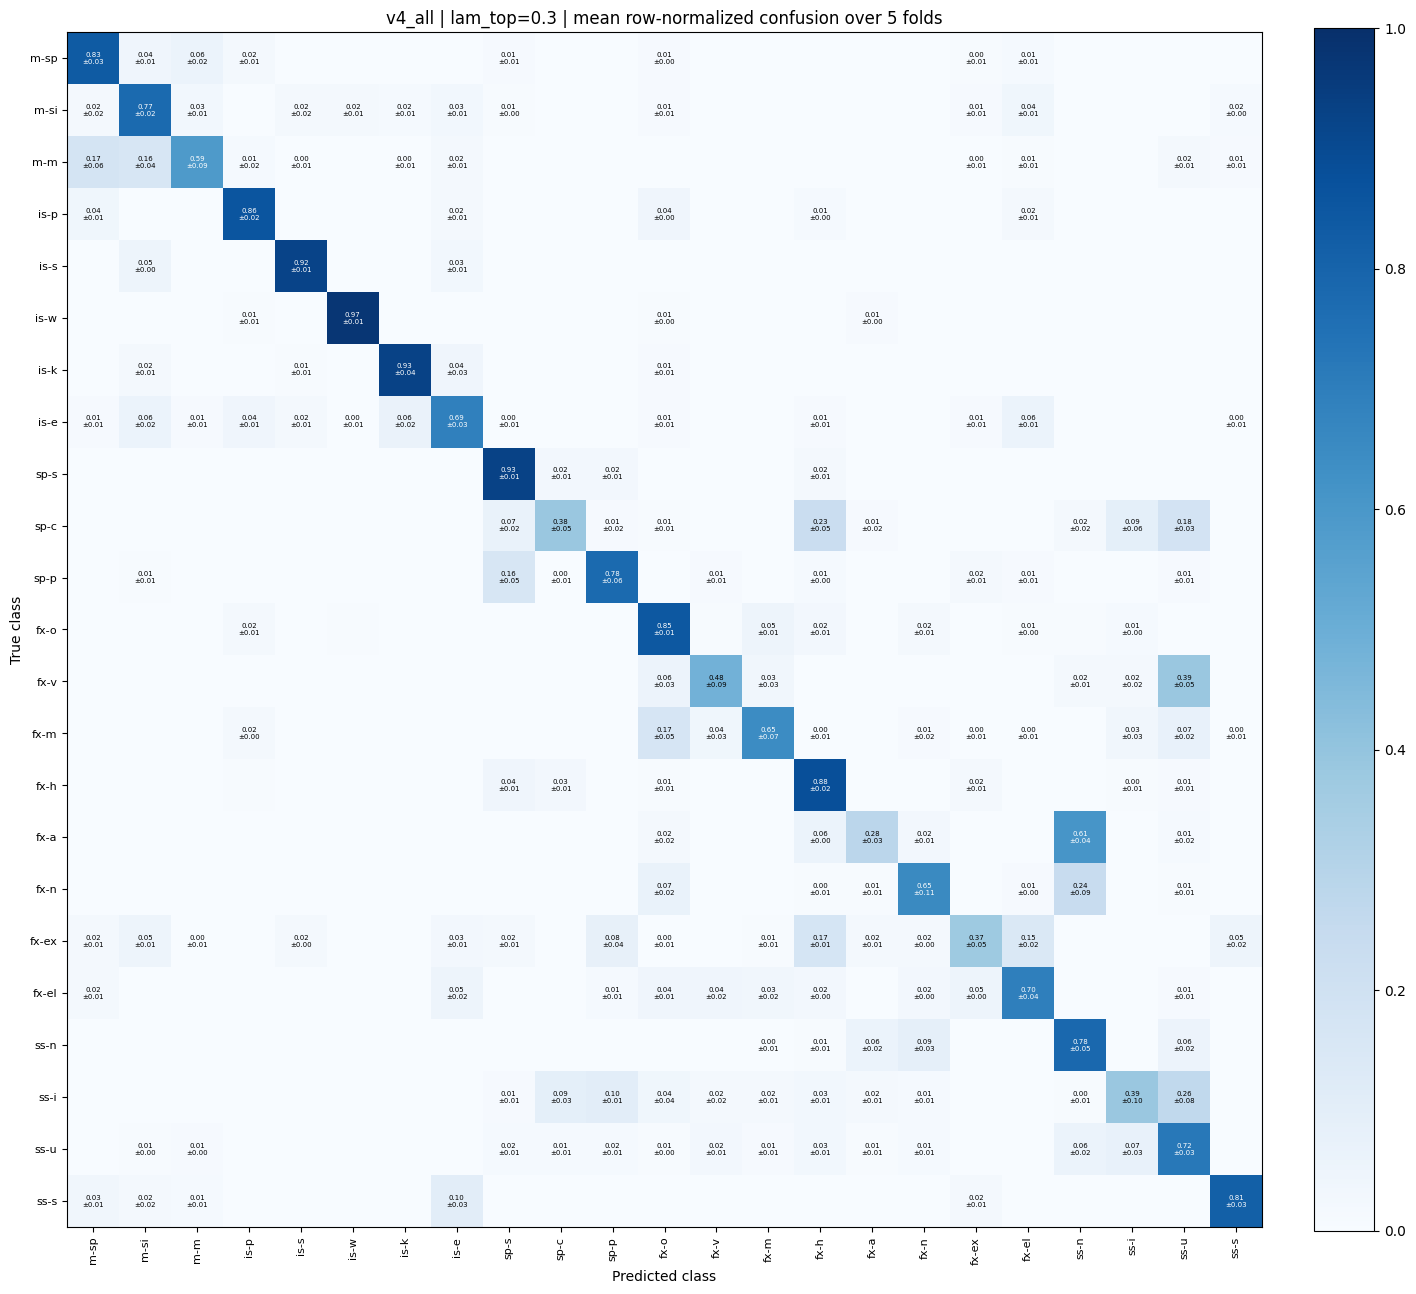

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_all_lam_top_0p3.png


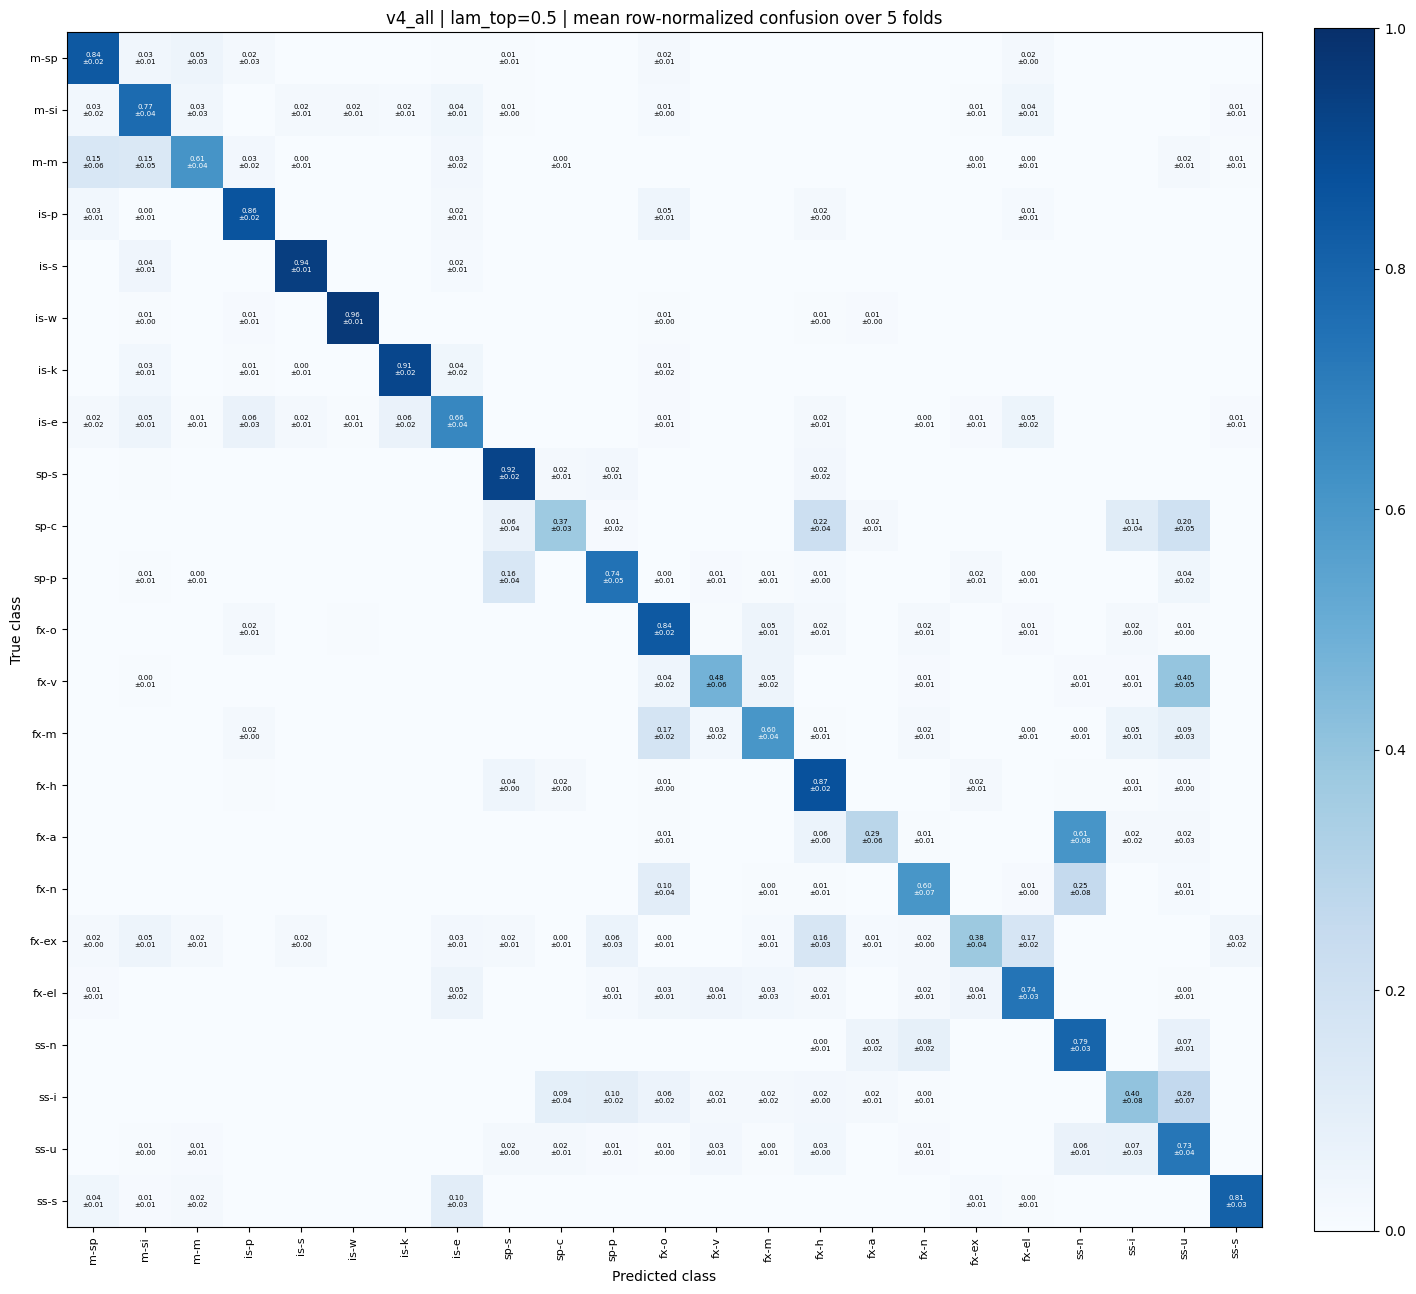

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_all_lam_top_0p5.png


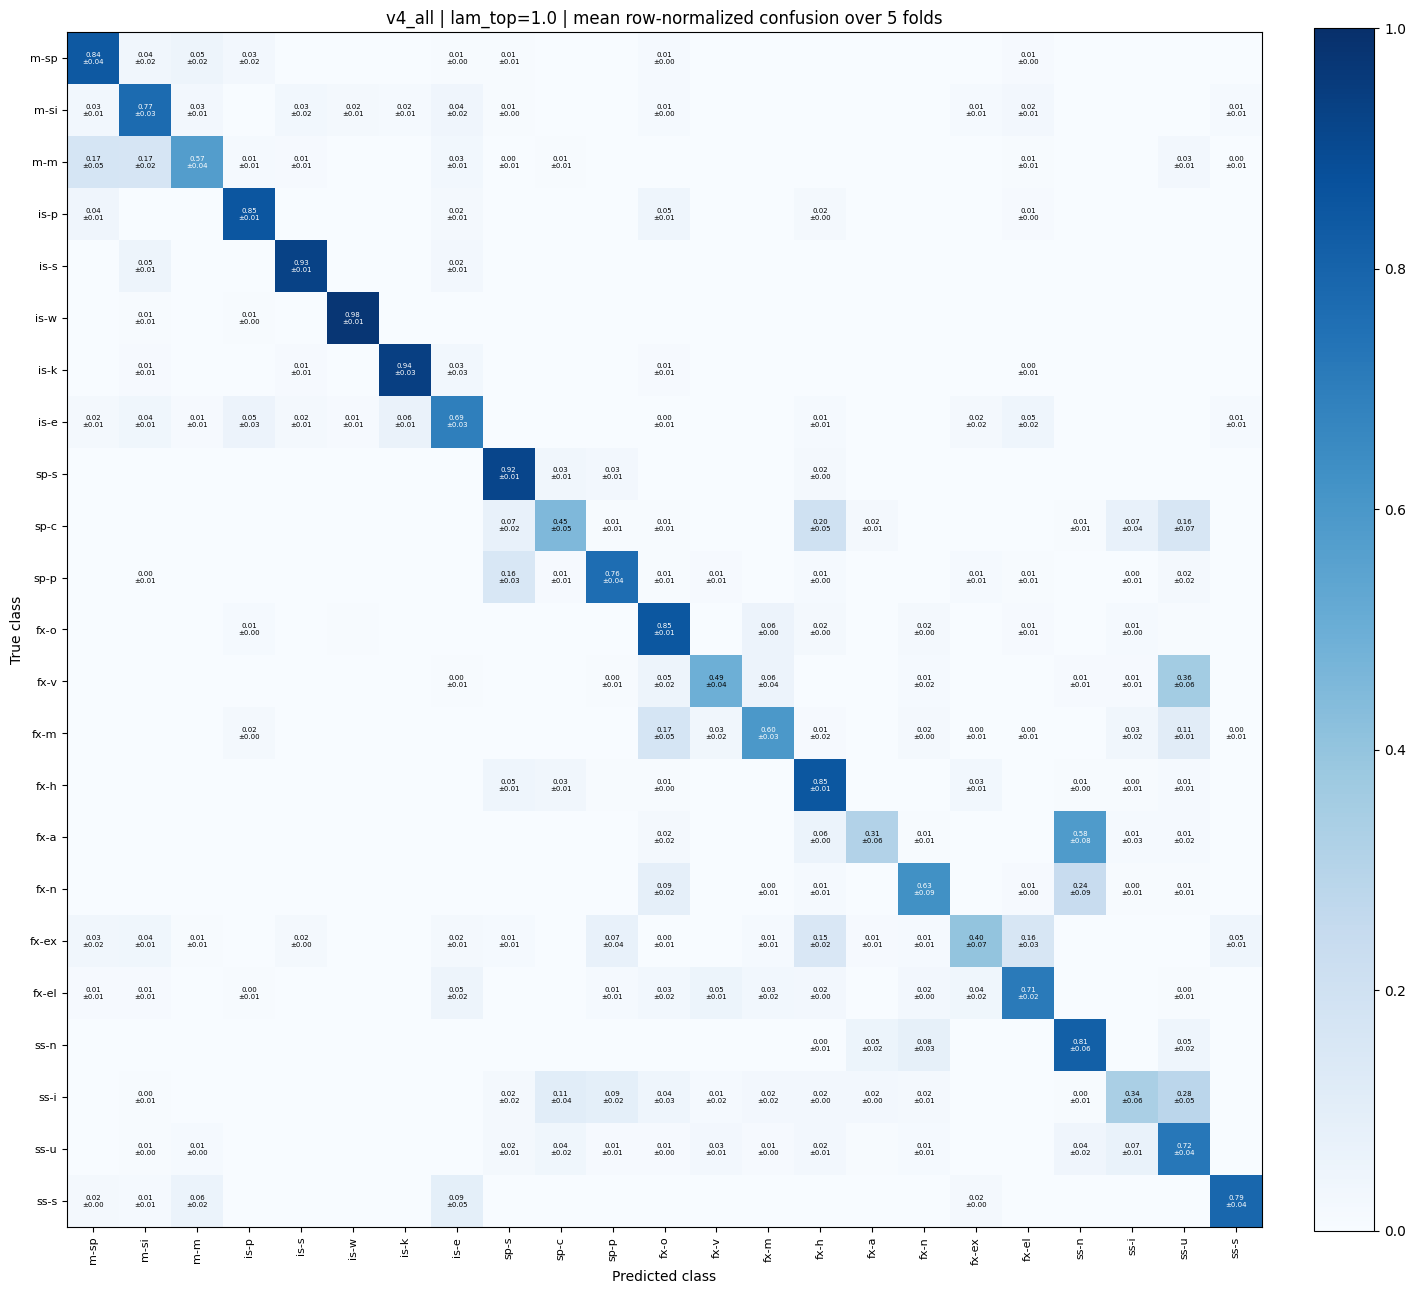

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_all_lam_top_1p0.png


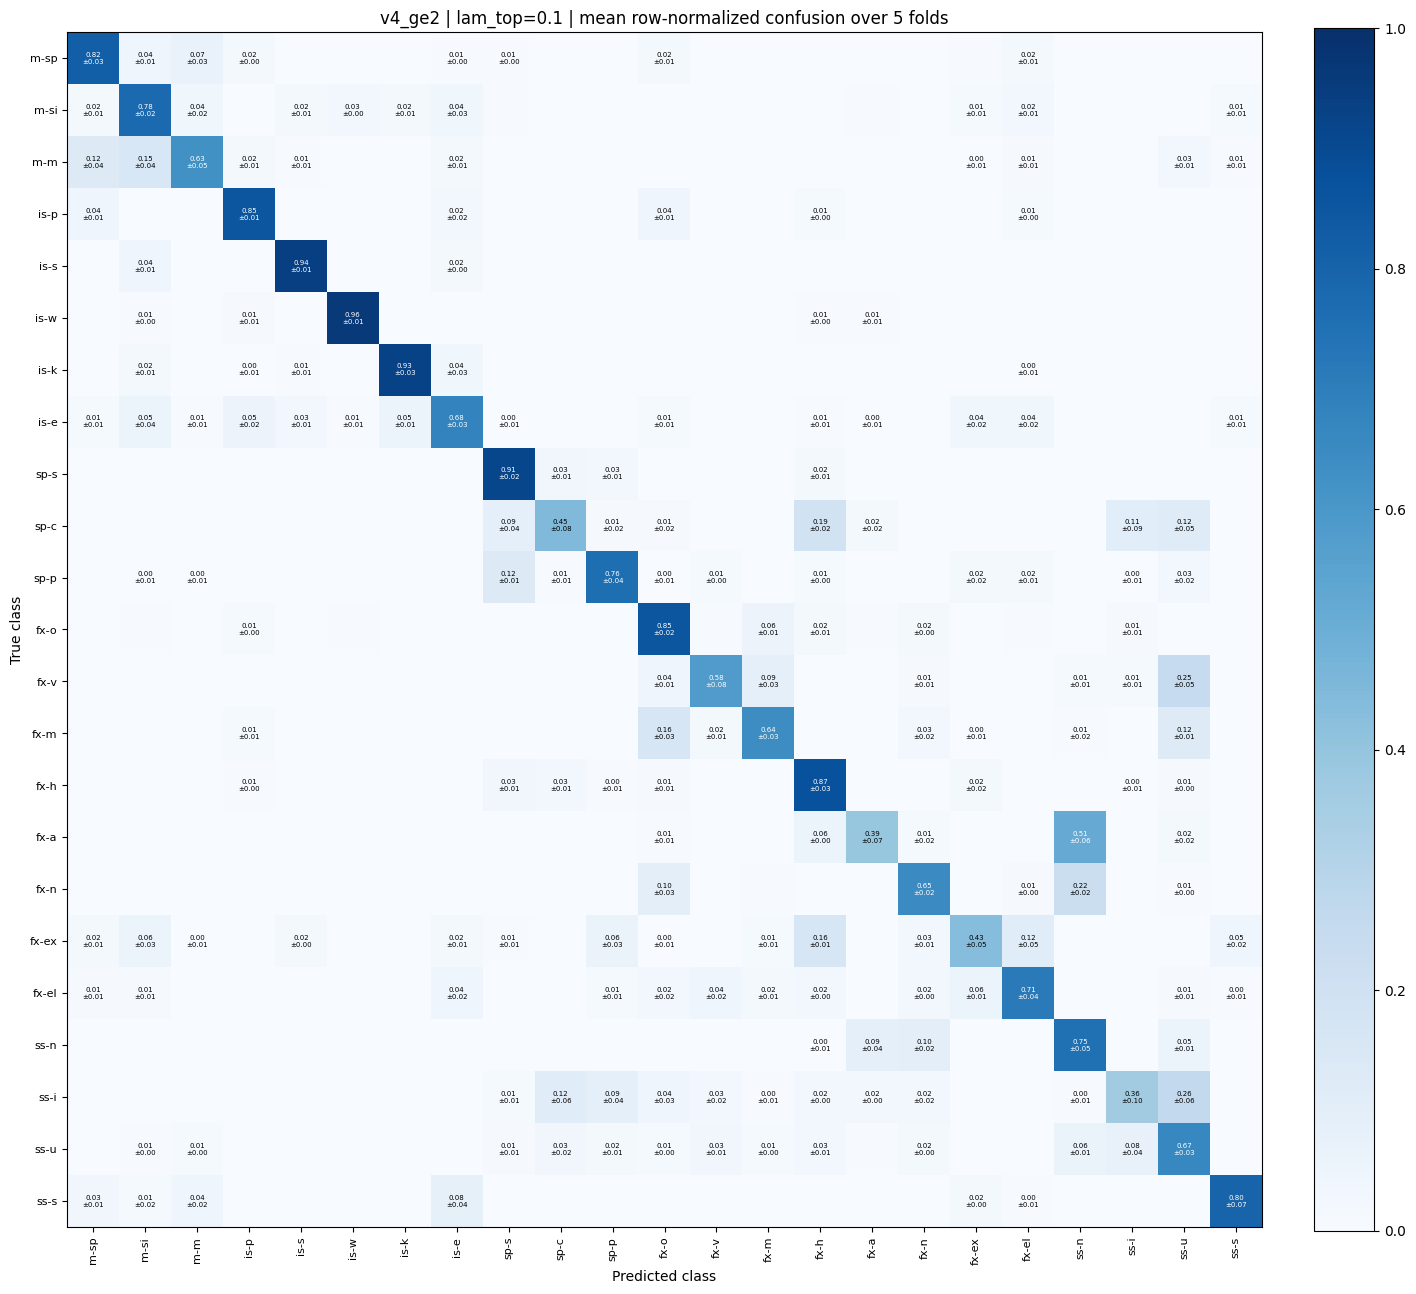

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge2_lam_top_0p1.png


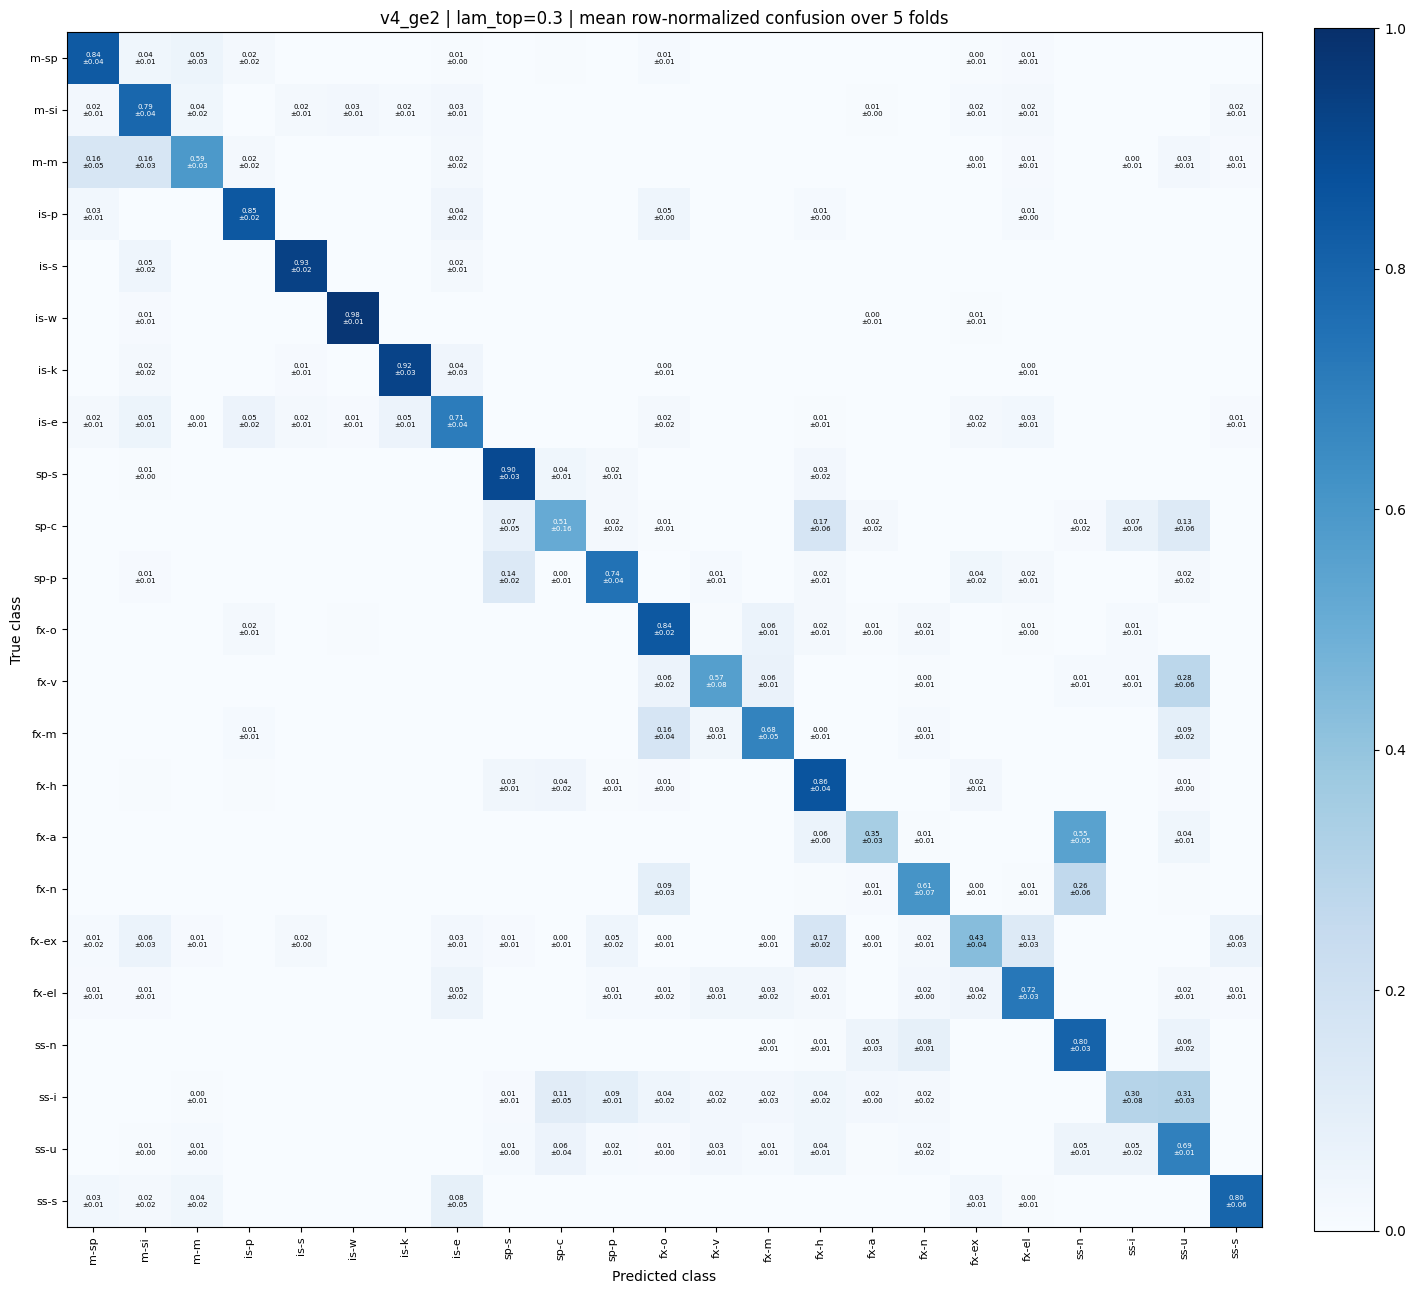

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge2_lam_top_0p3.png


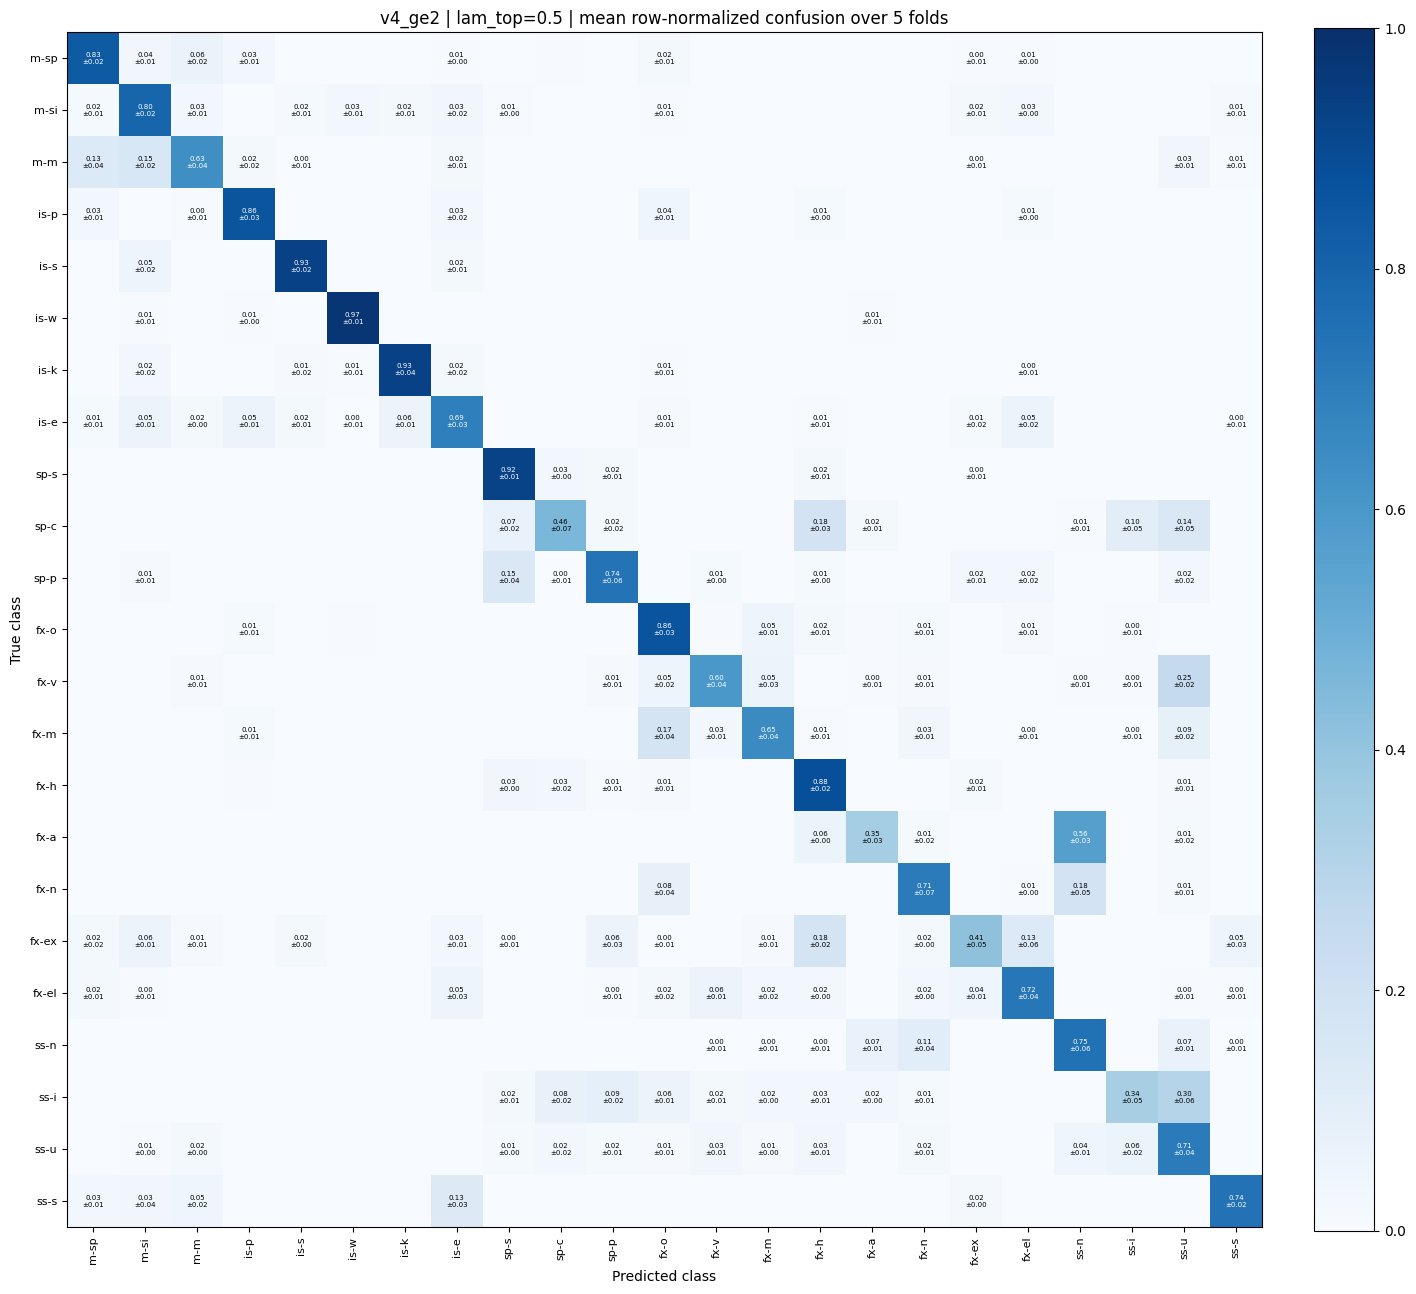

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge2_lam_top_0p5.png


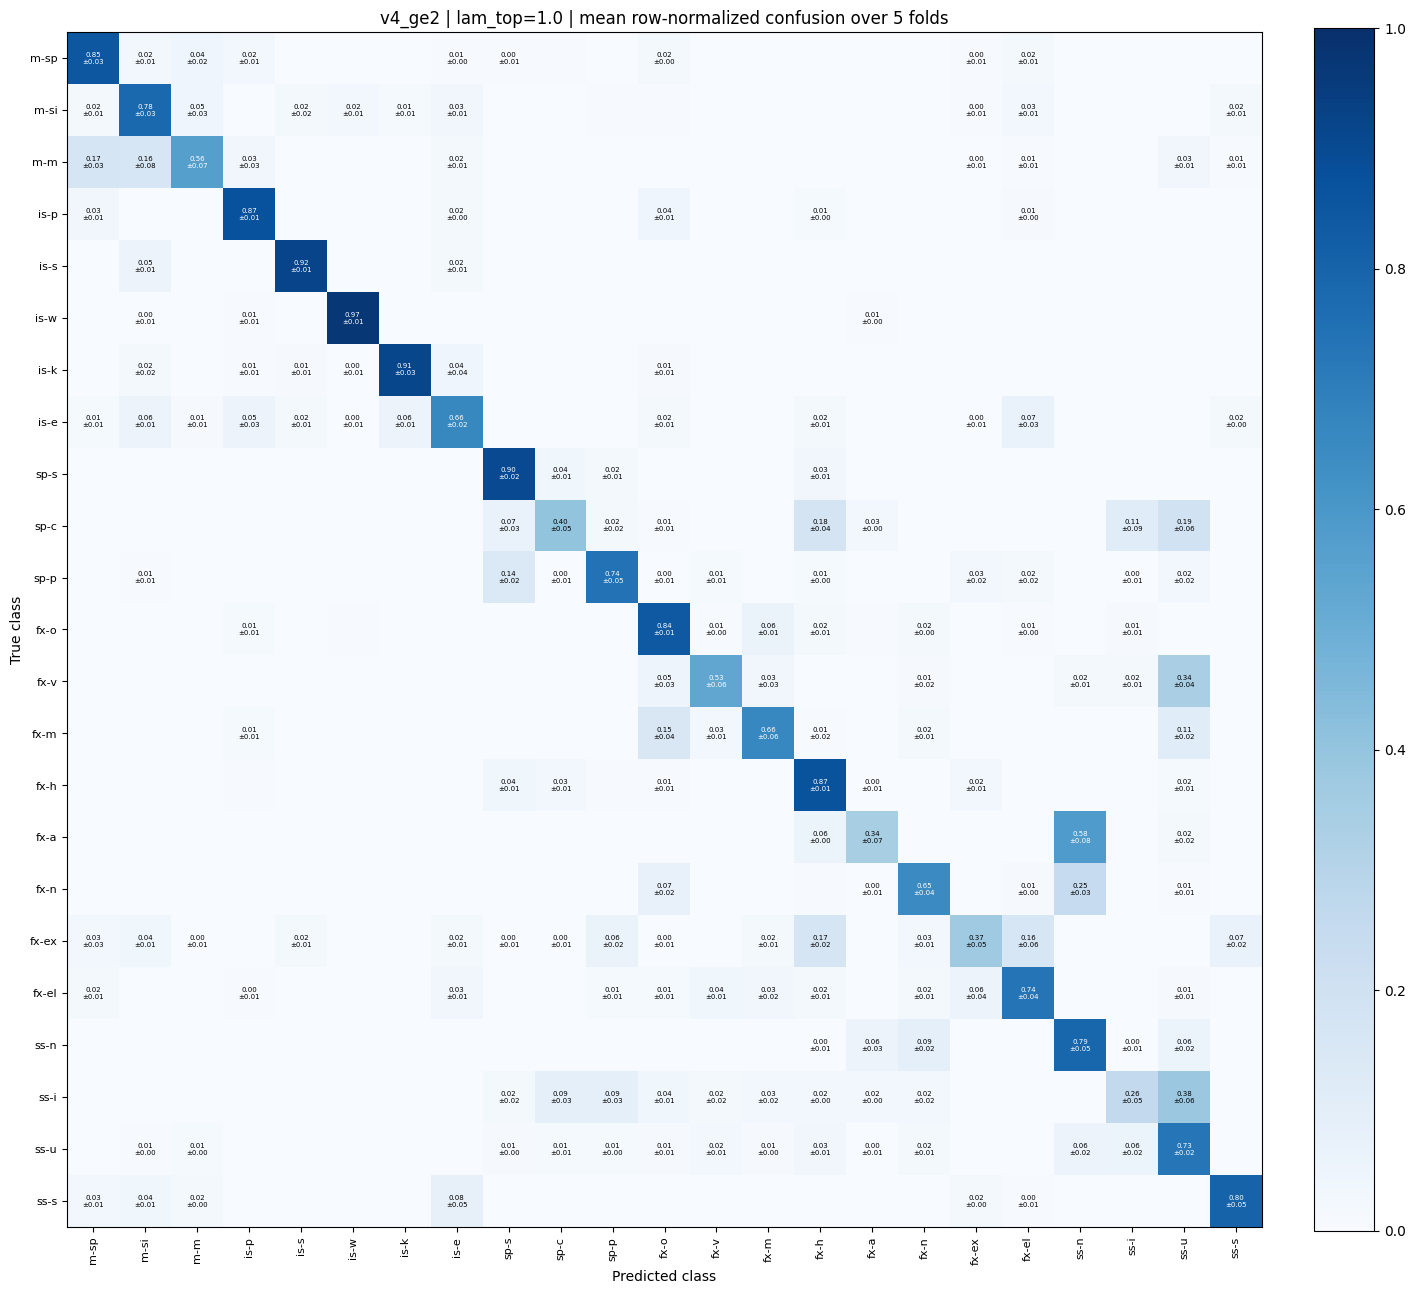

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge2_lam_top_1p0.png


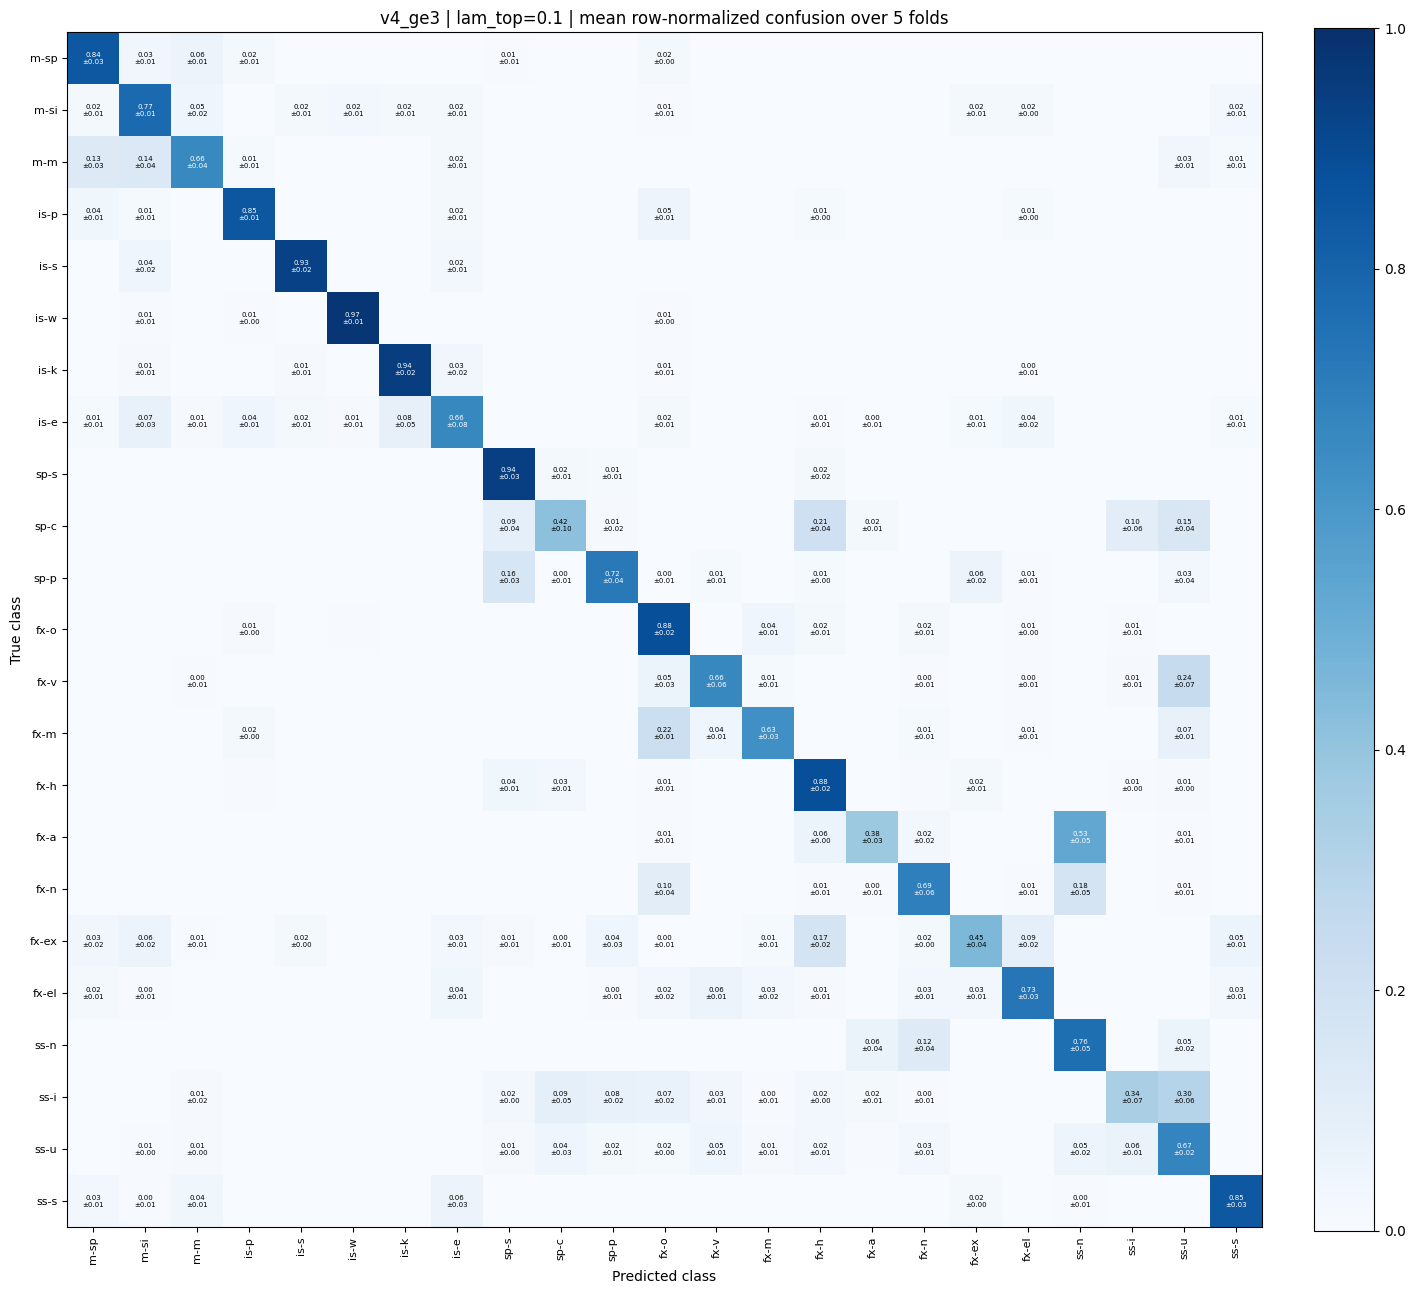

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge3_lam_top_0p1.png


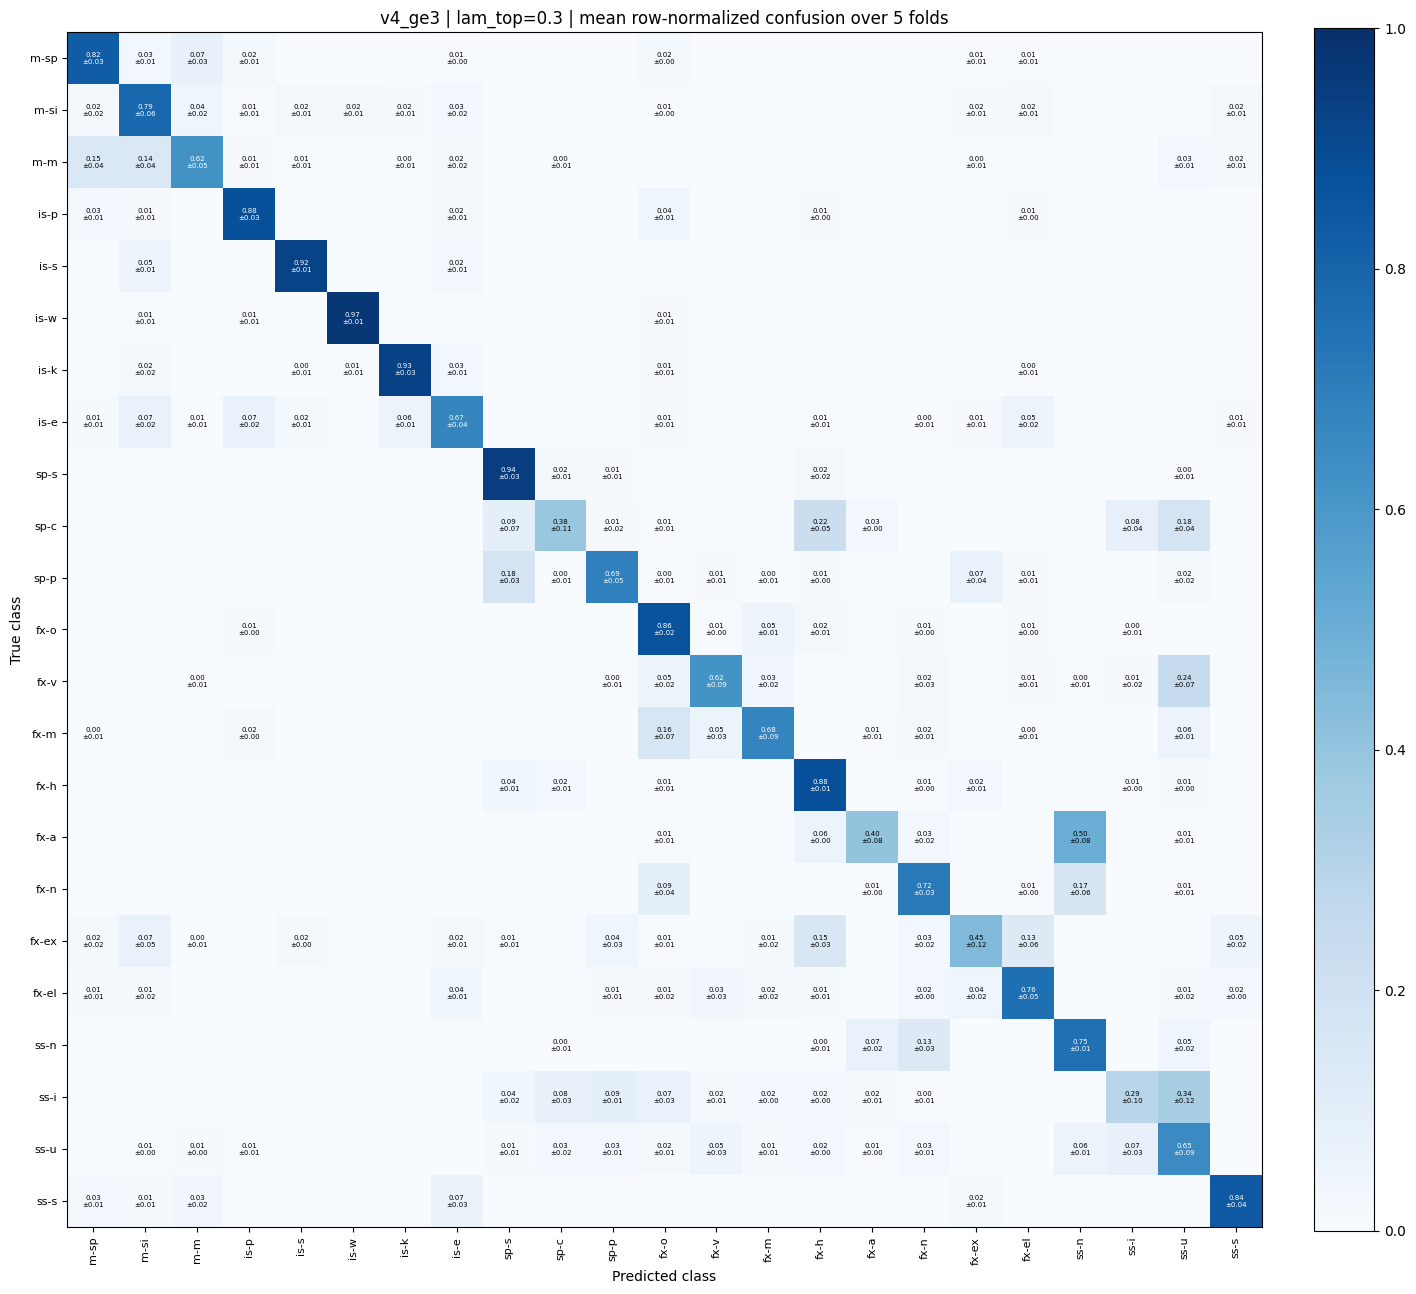

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge3_lam_top_0p3.png


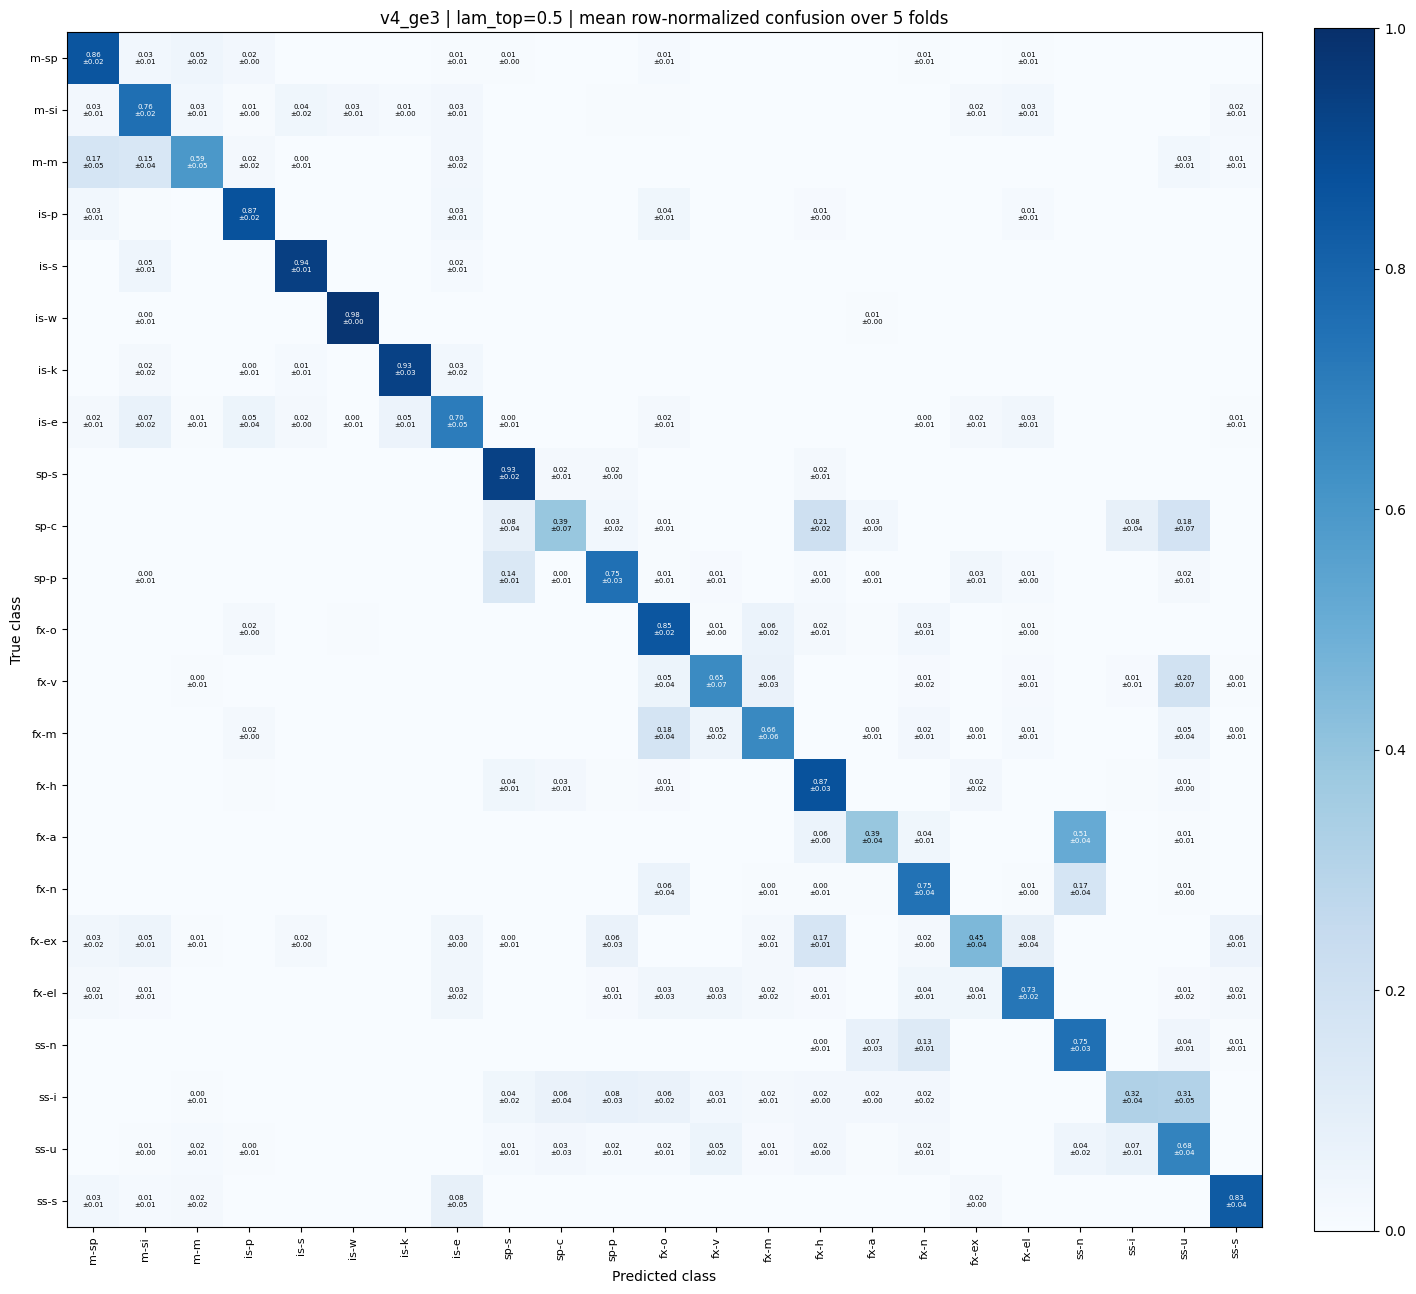

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge3_lam_top_0p5.png


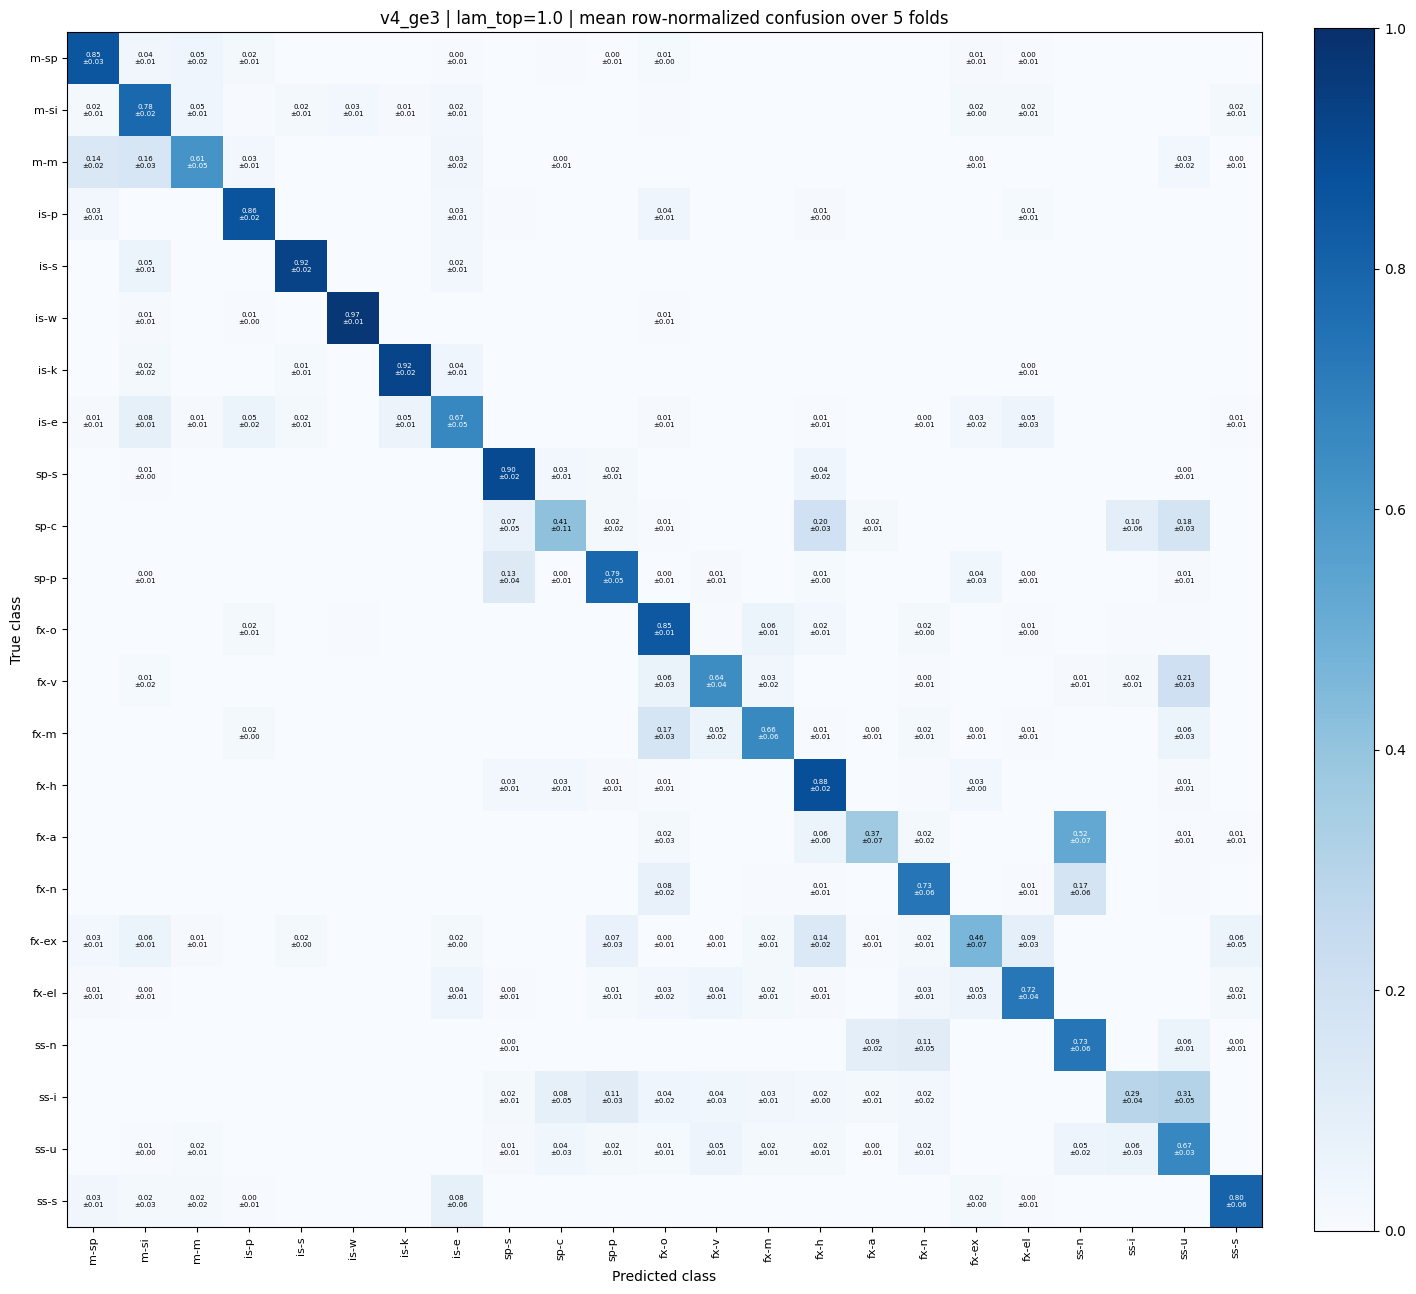

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge3_lam_top_1p0.png


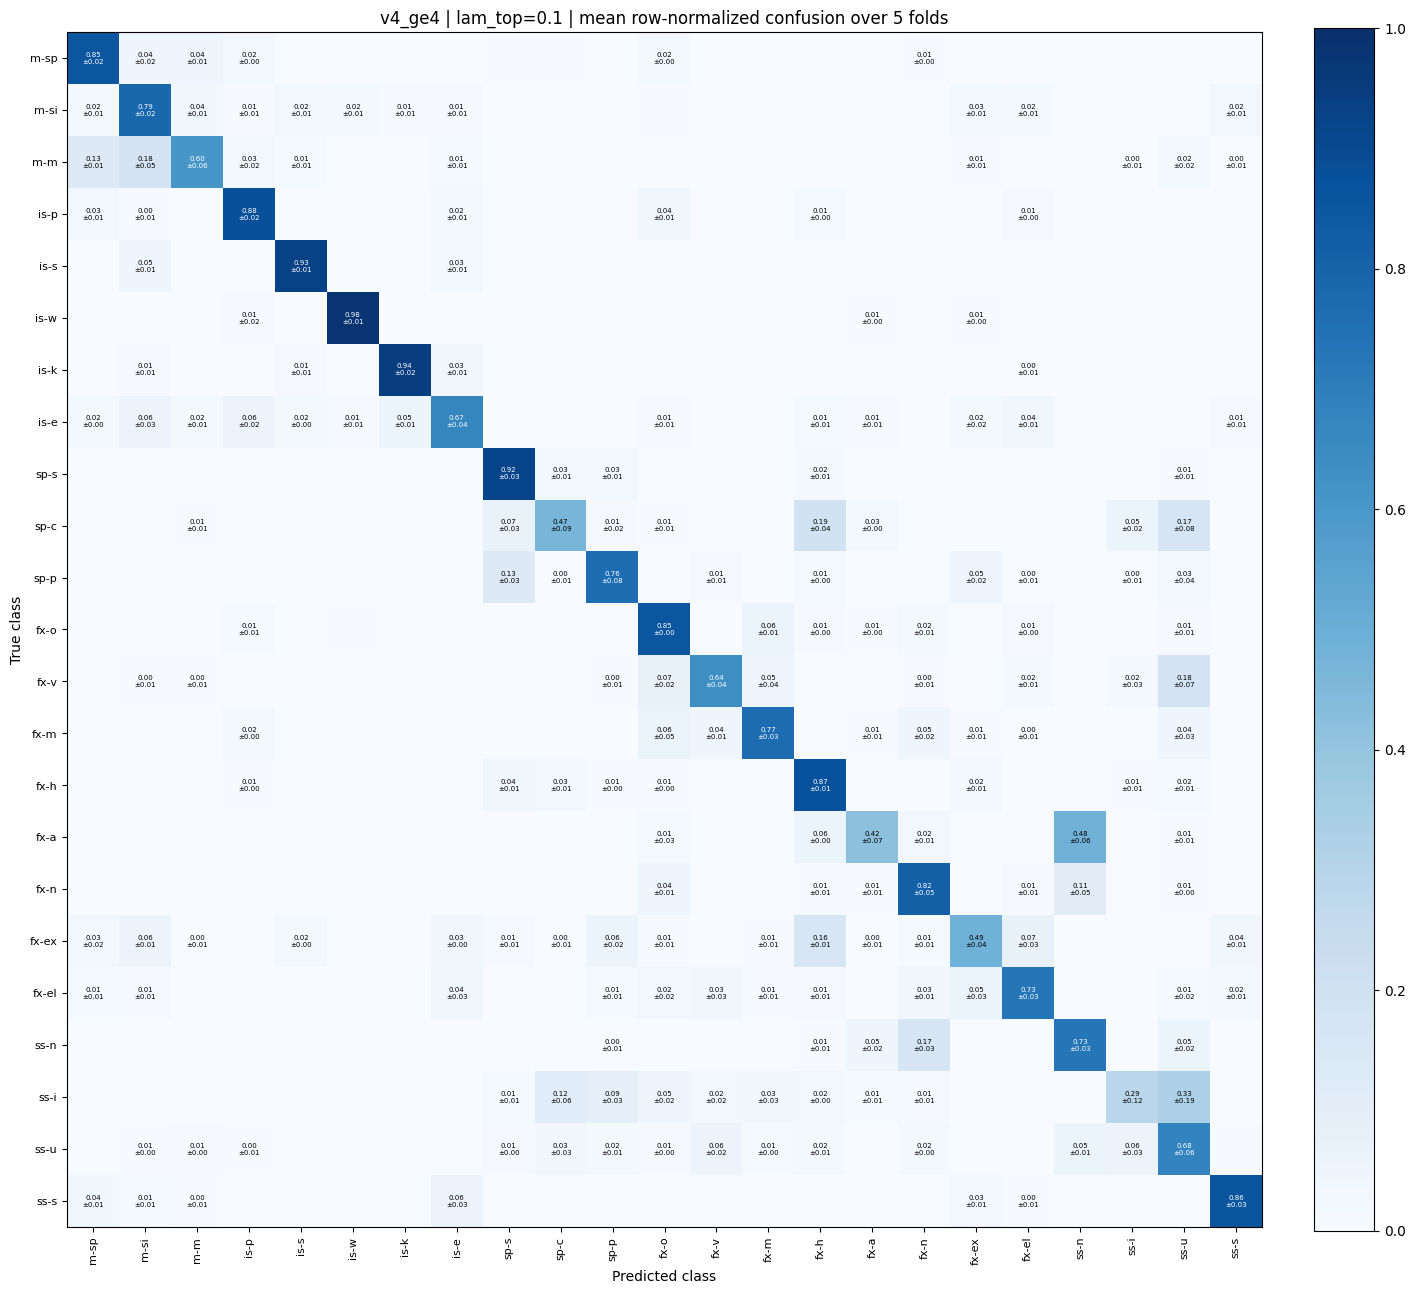

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge4_lam_top_0p1.png


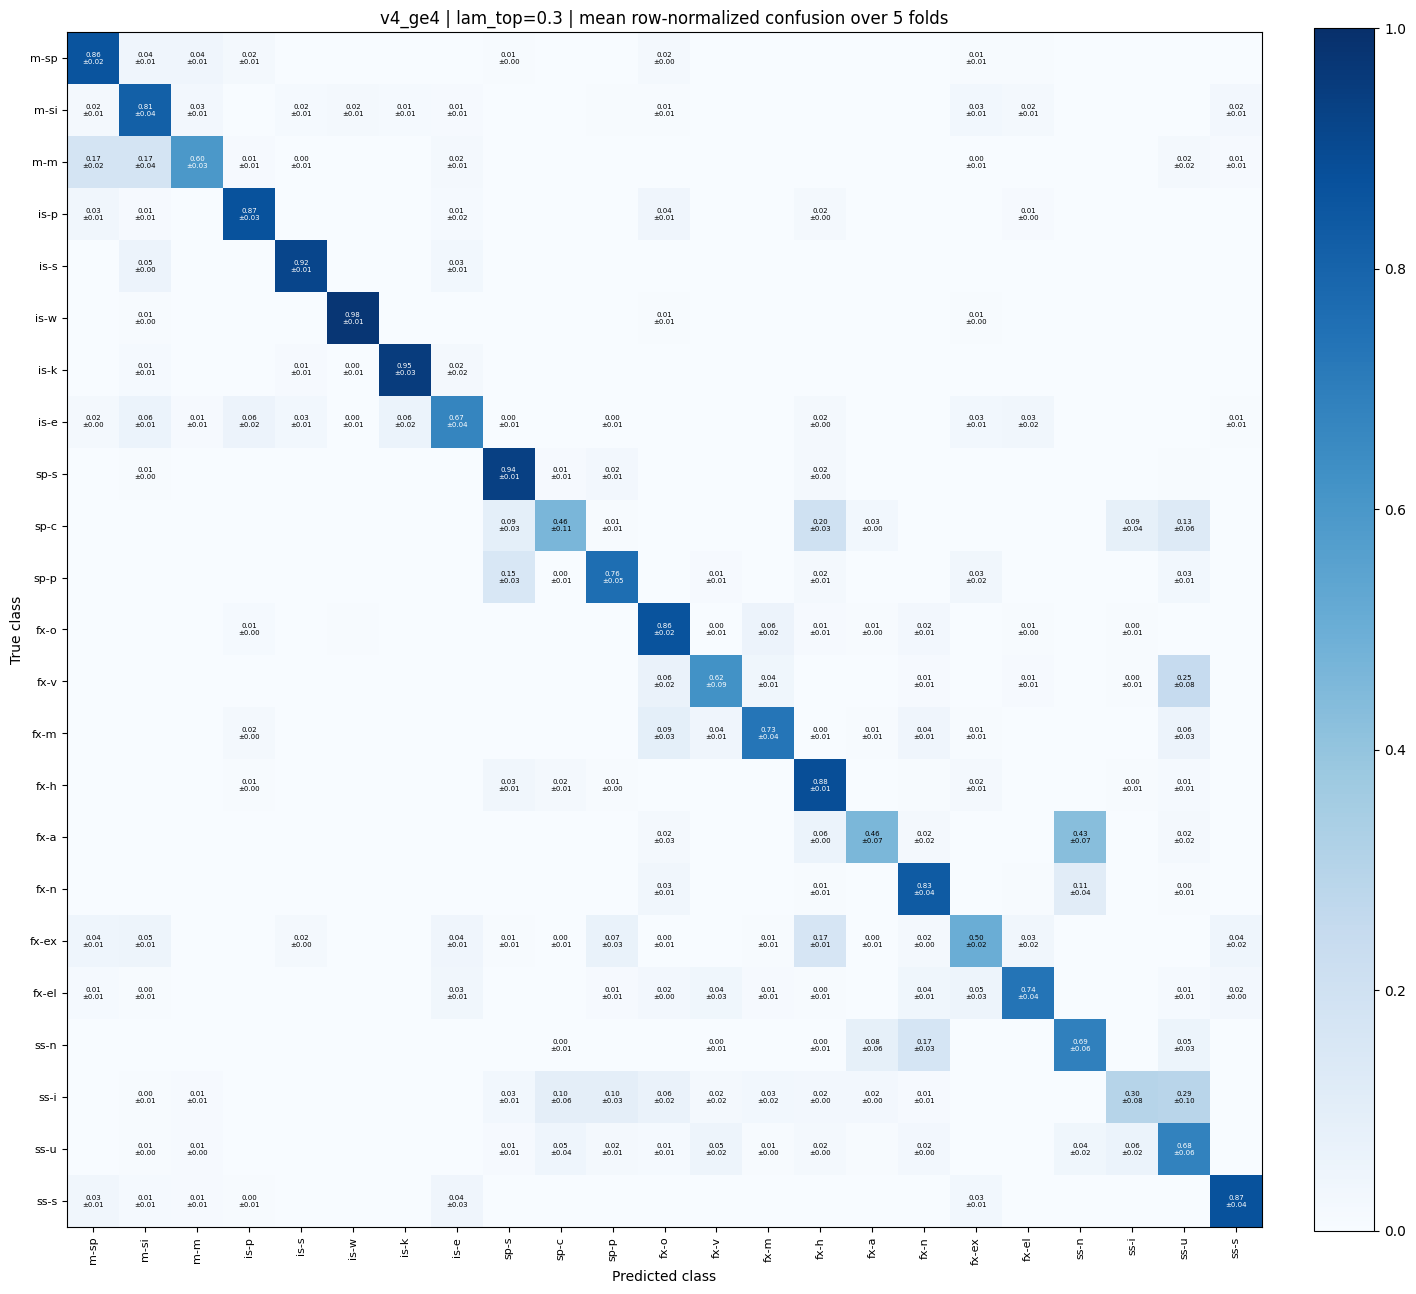

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge4_lam_top_0p3.png


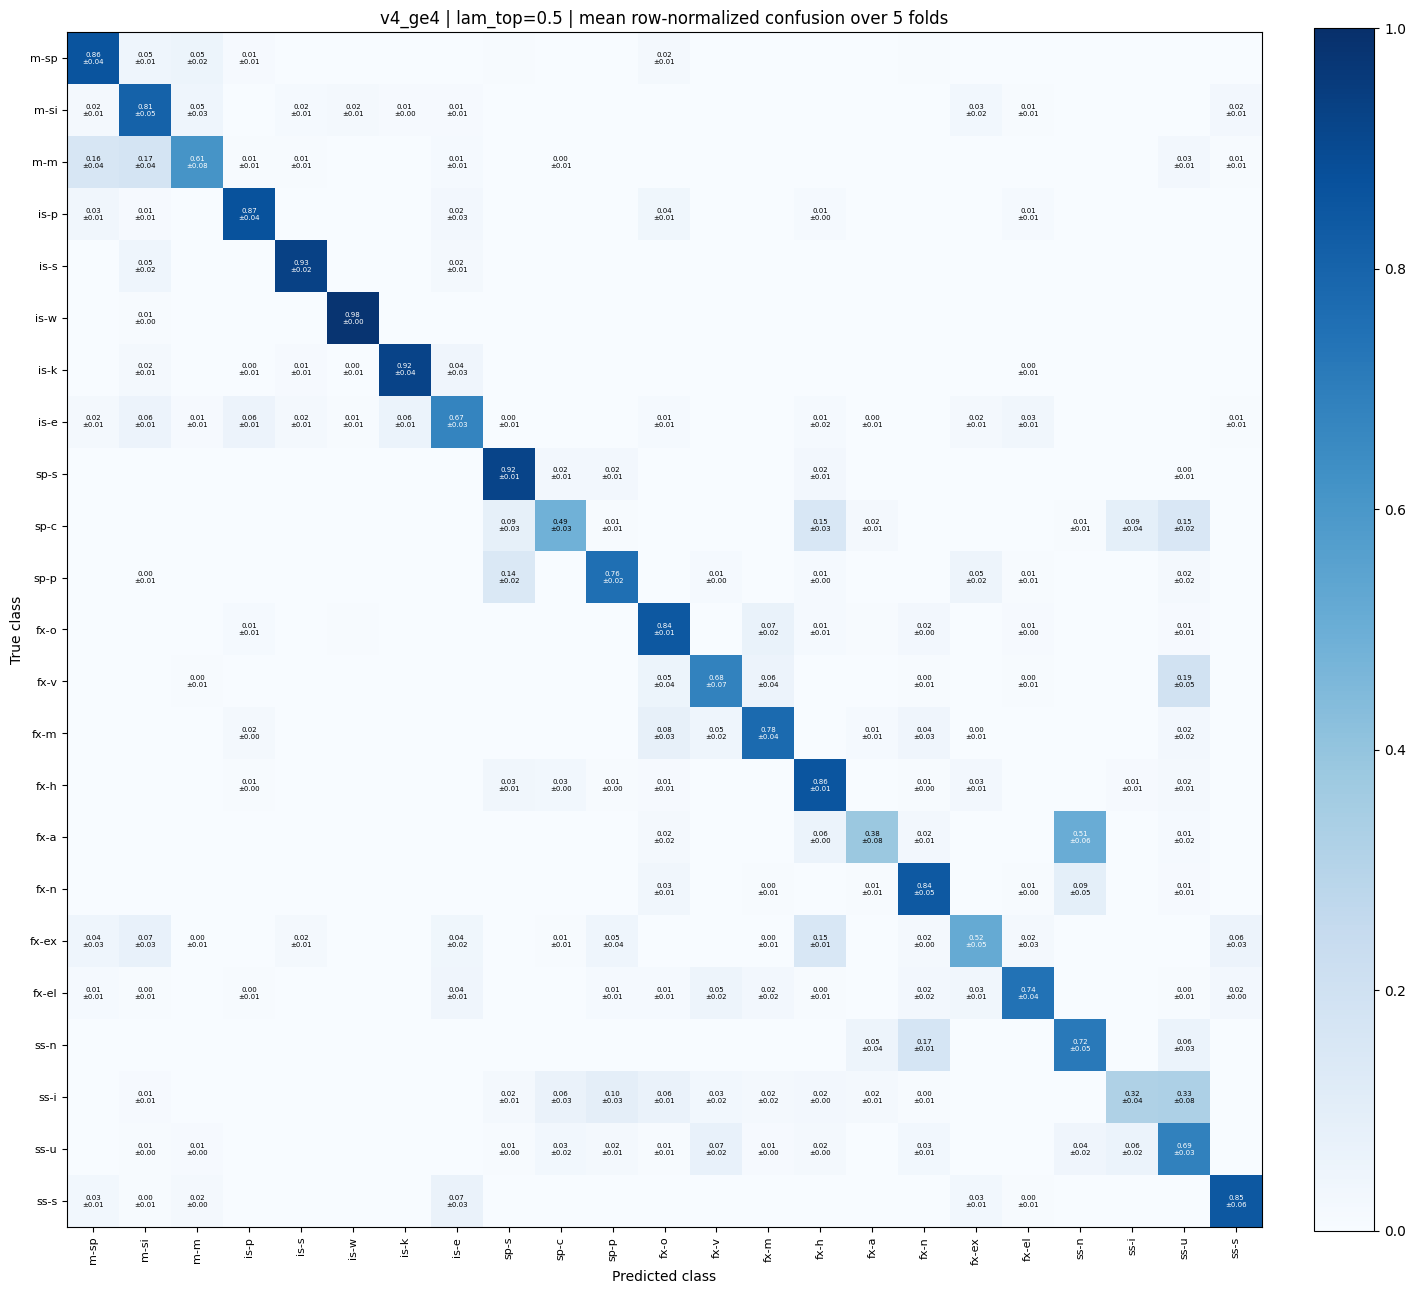

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge4_lam_top_0p5.png


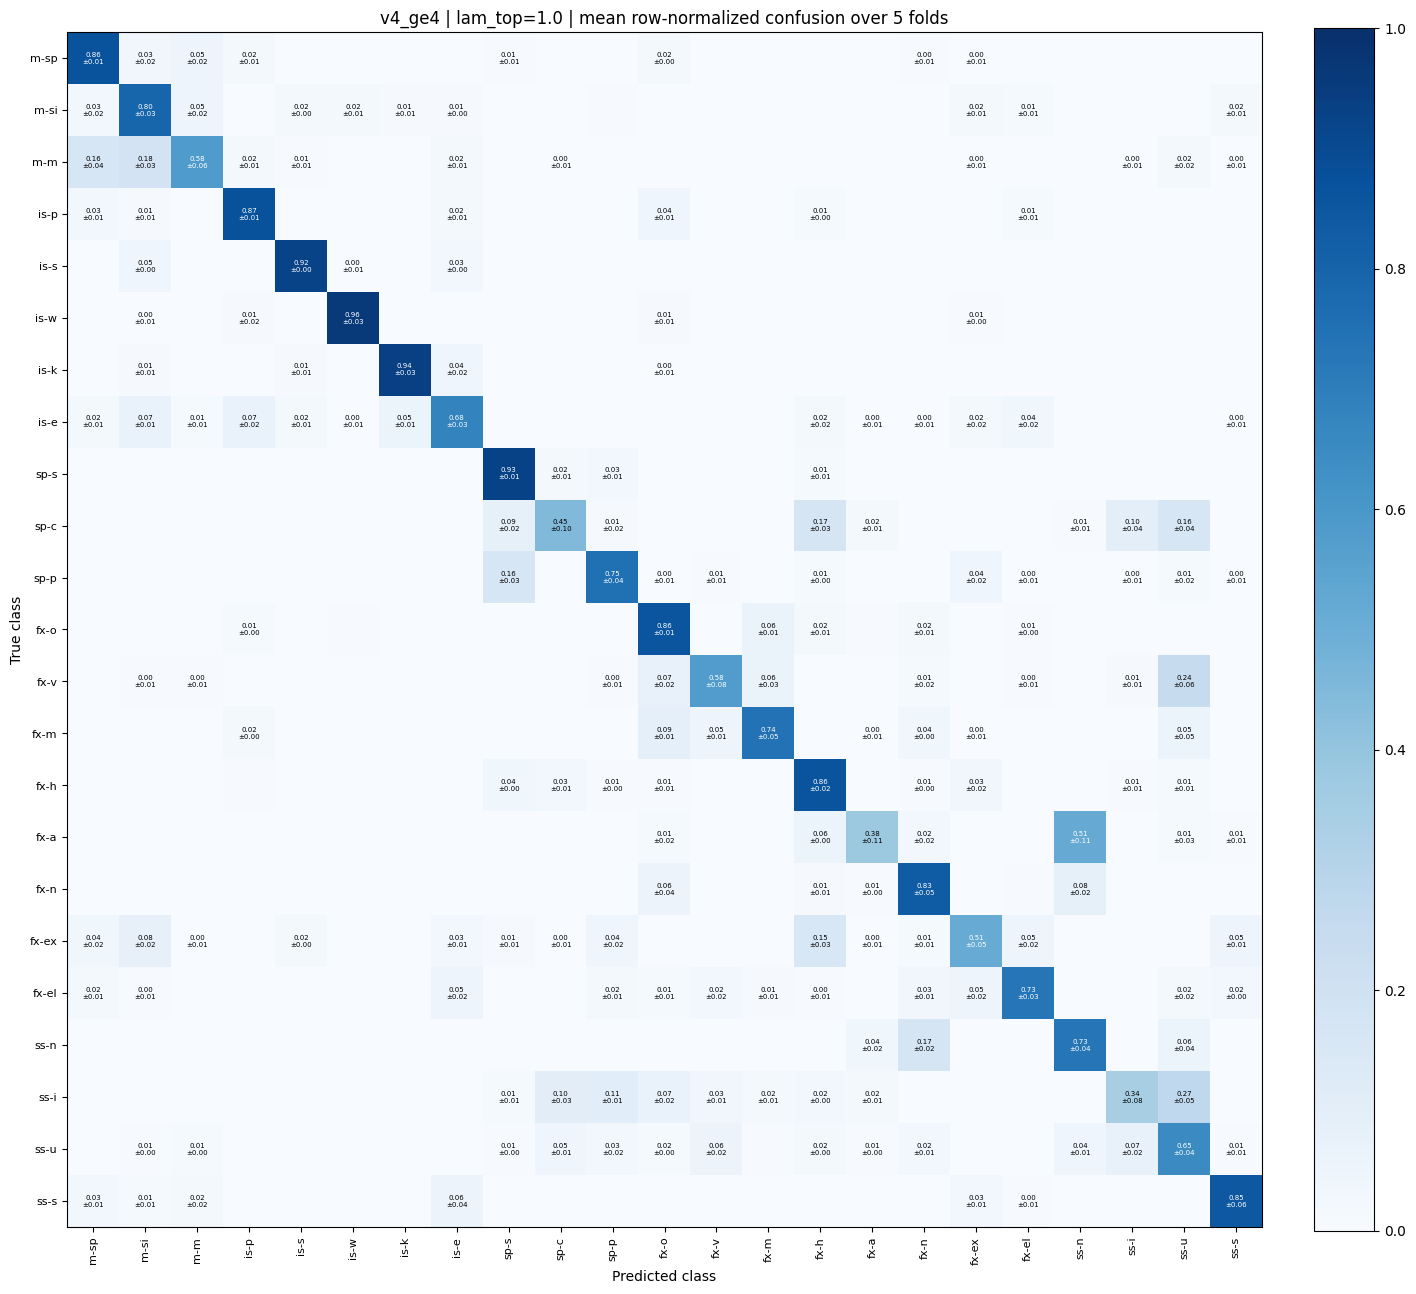

saved: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\v4_35k_hier_loss\plots\mean_confusion_matrix_v4_ge4_lam_top_1p0.png


,dataset_label,lam_top,fold_count,mean_confusion_csv,std_confusion_csv,plot_path
0,v4_all,0.1,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,v4_all,0.3,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,v4_all,0.5,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,v4_all,1.0,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...
4,v4_ge2,0.1,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,v4_ge2,0.3,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,v4_ge2,0.5,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,v4_ge2,1.0,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,v4_ge3,0.1,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,v4_ge3,0.3,5,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...,c:\Users\solok\Desktop\Dcase baseline\baseline...


In [12]:
def load_confusion_matrix(run_dir: str | Path):
    cm_path = Path(run_dir) / 'evaluation' / 'confusion_matrix_normalized_true.csv'
    if not cm_path.exists():
        return None, None
    cm_df = pd.read_csv(cm_path, index_col=0)
    return cm_df.index.astype(str).tolist(), cm_df.to_numpy(dtype=float)

def annotate_mean_std_confusion(ax, mean_cm, std_cm, fontsize=5):
    for i in range(mean_cm.shape[0]):
        for j in range(mean_cm.shape[1]):
            m = mean_cm[i, j]
            s = std_cm[i, j]
            if m < 0.005 and s < 0.005:
                continue
            color = 'white' if m > 0.5 else 'black'
            ax.text(j, i, f'{m:.2f}\n±{s:.2f}', ha='center', va='center', color=color, fontsize=fontsize)

def plot_mean_confusion(labels, mean_cm, std_cm, title: str, save_path: Path):
    fig_size = max(10, len(labels) * 0.62)
    fig, ax = plt.subplots(figsize=(fig_size, fig_size))
    im = ax.imshow(mean_cm, interpolation='nearest', cmap='Blues', vmin=0.0, vmax=1.0)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    annotate_mean_std_confusion(ax, mean_cm, std_cm, fontsize=5)
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('saved:', save_path)

cm_summary_rows = []
for (dataset_label, lam_top), group in summary.groupby(['dataset_label', 'lam_top'], sort=False):
    matrices = []
    labels = None
    for _, row in group.iterrows():
        cm_labels, cm = load_confusion_matrix(row['output_dir'])
        if cm is None:
            continue
        if labels is None:
            labels = cm_labels
        matrices.append(cm)
    if not matrices:
        print('[skip] no confusion matrices:', dataset_label, lam_top)
        continue
    stack = np.stack(matrices, axis=0)
    mean_cm = stack.mean(axis=0)
    std_cm = stack.std(axis=0, ddof=1) if stack.shape[0] > 1 else np.zeros_like(mean_cm)
    lam_tag = format_lam_top(lam_top)
    mean_path = OUTPUT_ROOT / f'mean_confusion_{dataset_label}_{lam_tag}.csv'
    std_path = OUTPUT_ROOT / f'std_confusion_{dataset_label}_{lam_tag}.csv'
    pd.DataFrame(mean_cm, index=labels, columns=labels).to_csv(mean_path)
    pd.DataFrame(std_cm, index=labels, columns=labels).to_csv(std_path)
    save_path = PLOTS_DIR / f'mean_confusion_matrix_{dataset_label}_{lam_tag}.png'
    title = f'{dataset_label} | lam_top={lam_top} | mean row-normalized confusion over {len(matrices)} folds'
    plot_mean_confusion(labels, mean_cm, std_cm, title, save_path)
    cm_summary_rows.append({
        'dataset_label': dataset_label,
        'lam_top': float(lam_top),
        'fold_count': len(matrices),
        'mean_confusion_csv': str(mean_path),
        'std_confusion_csv': str(std_path),
        'plot_path': str(save_path),
    })

cm_summary = pd.DataFrame(cm_summary_rows)
cm_summary.to_csv(OUTPUT_ROOT / 'mean_confusion_matrix_manifest.csv', index=False)
display(cm_summary)

## 10. UMAP visualization

This cell loads the best fold for each `(dataset_label, lam_top)` pair and visualizes the final-test latent representation `z`. If `umap-learn` is not installed, install it first with `python -m pip install umap-learn`.

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

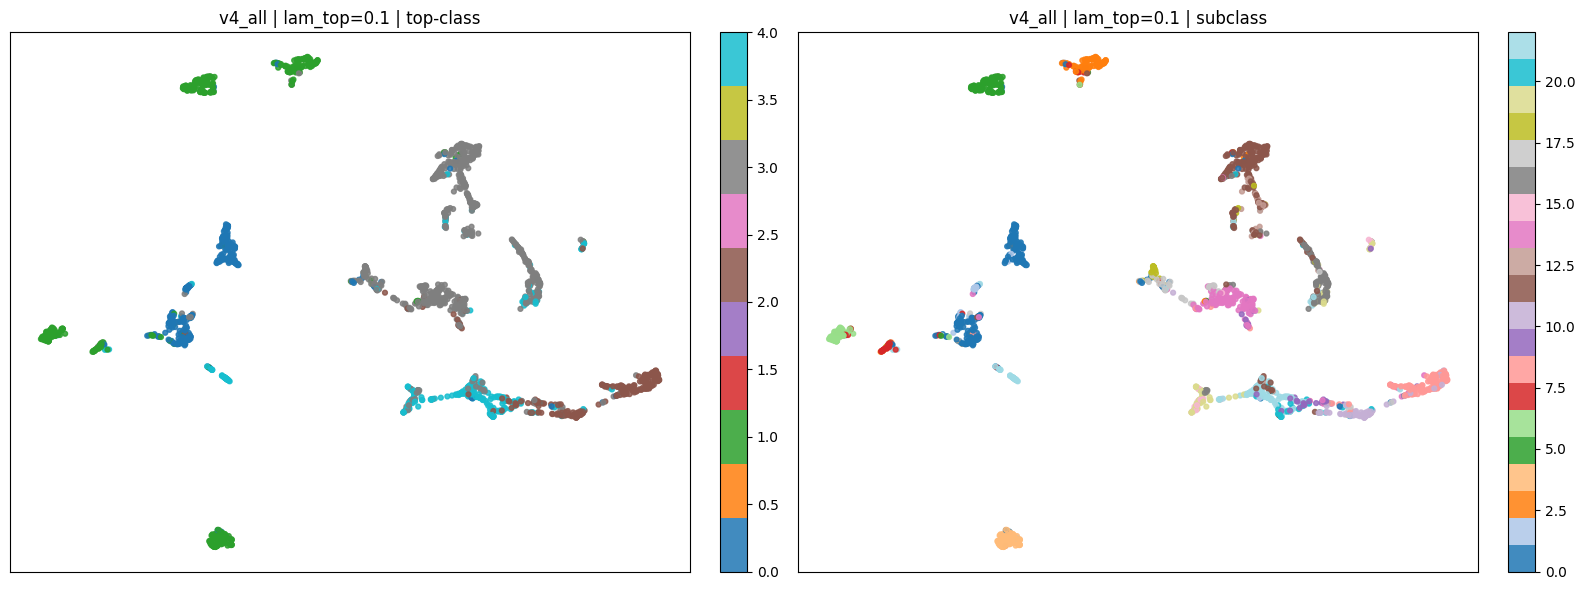

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

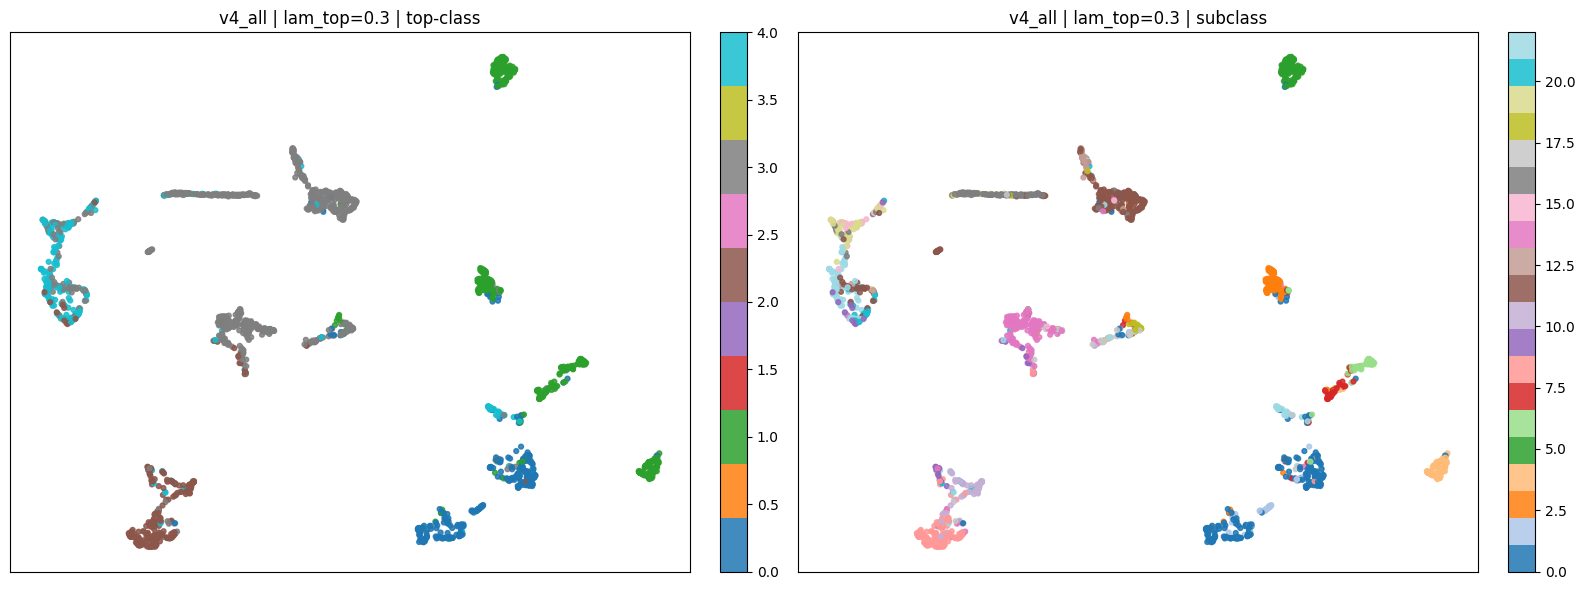

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

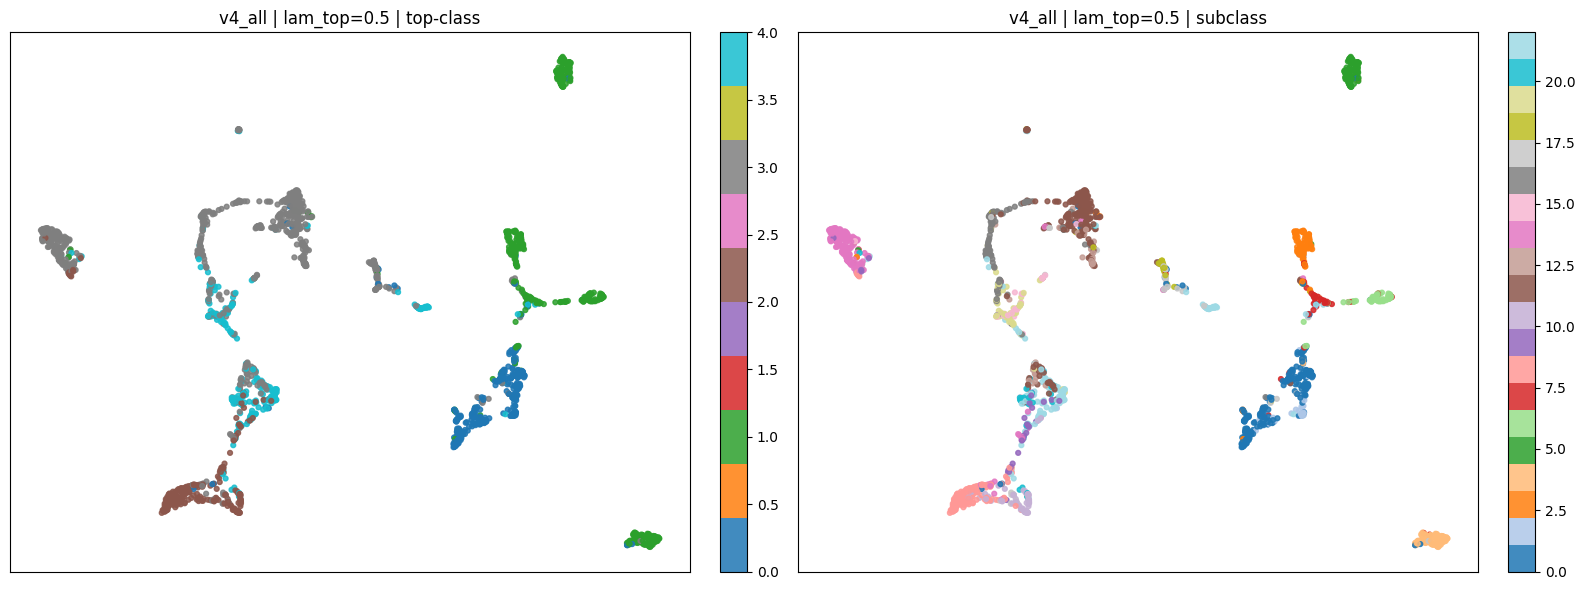

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

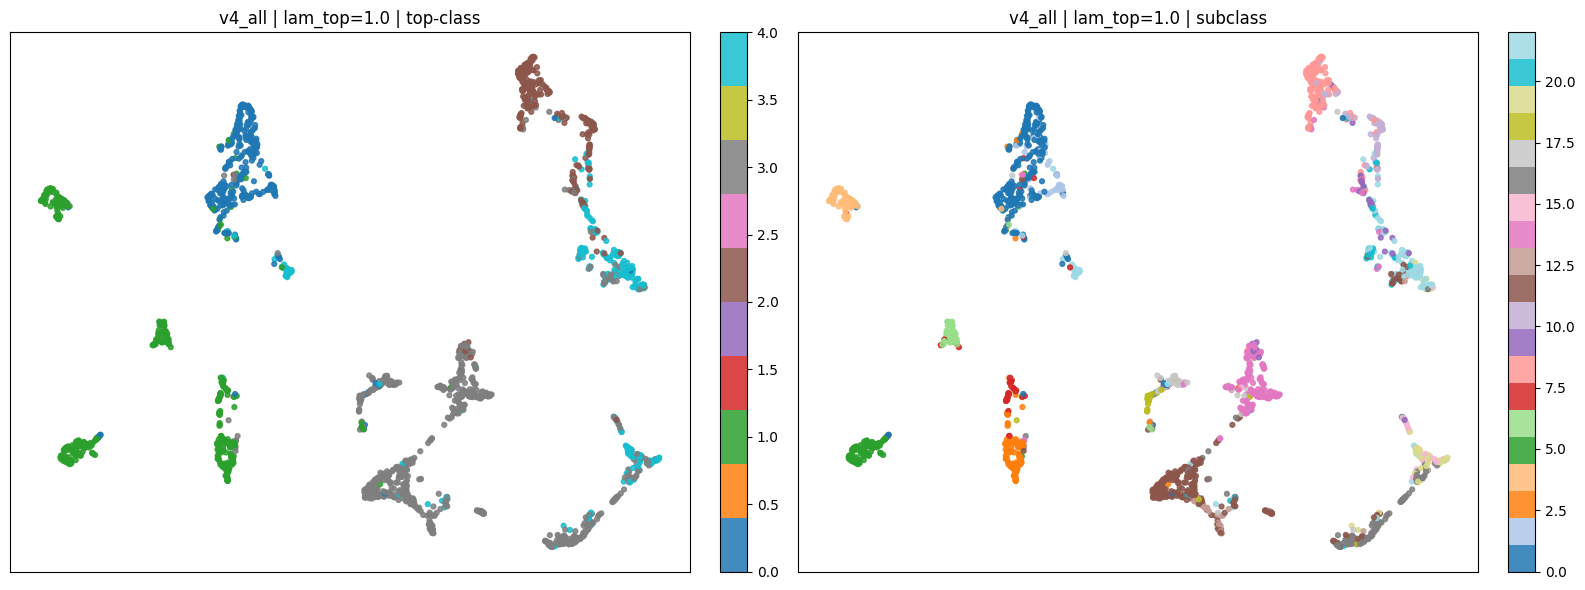

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

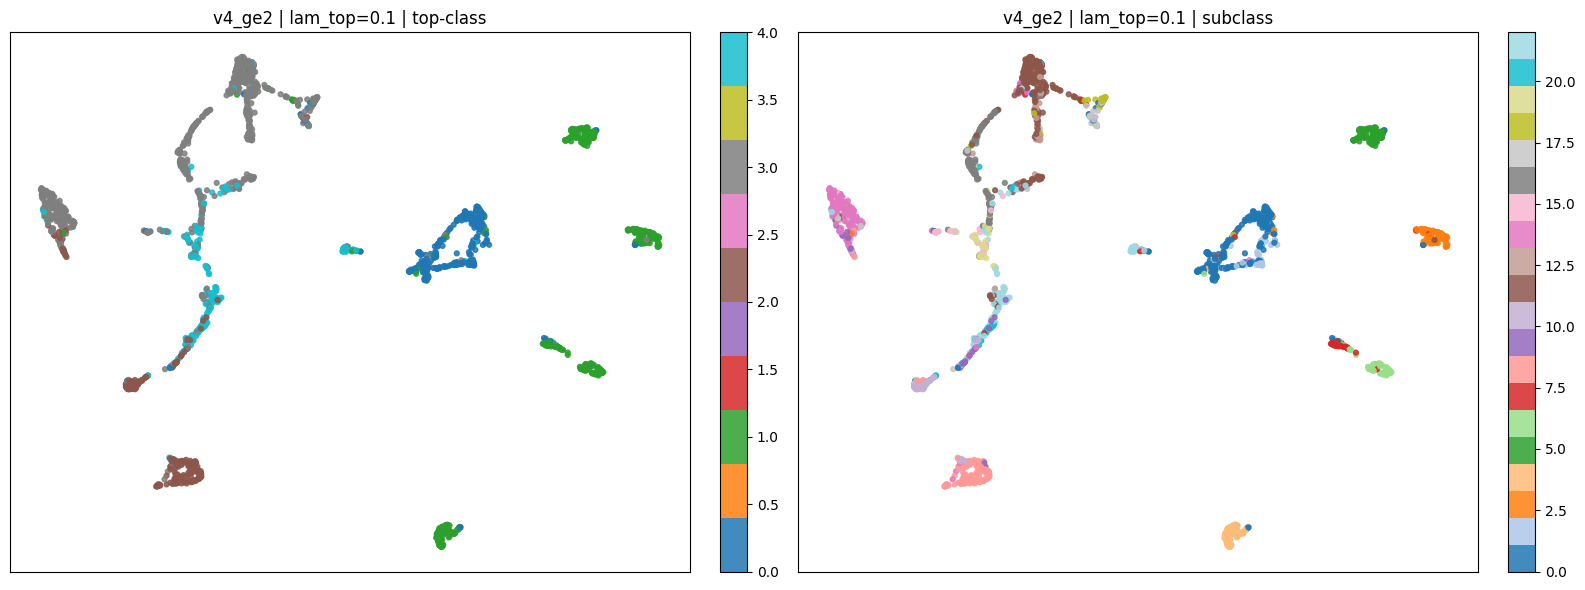

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

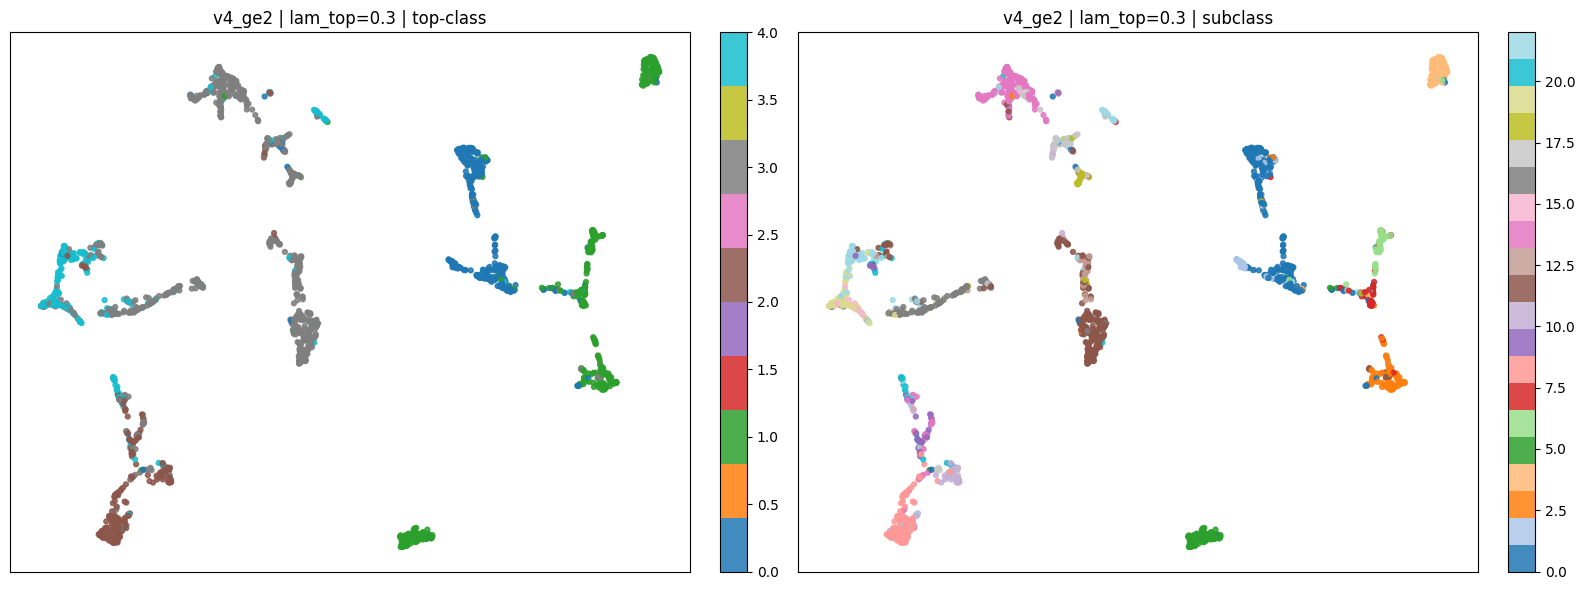

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

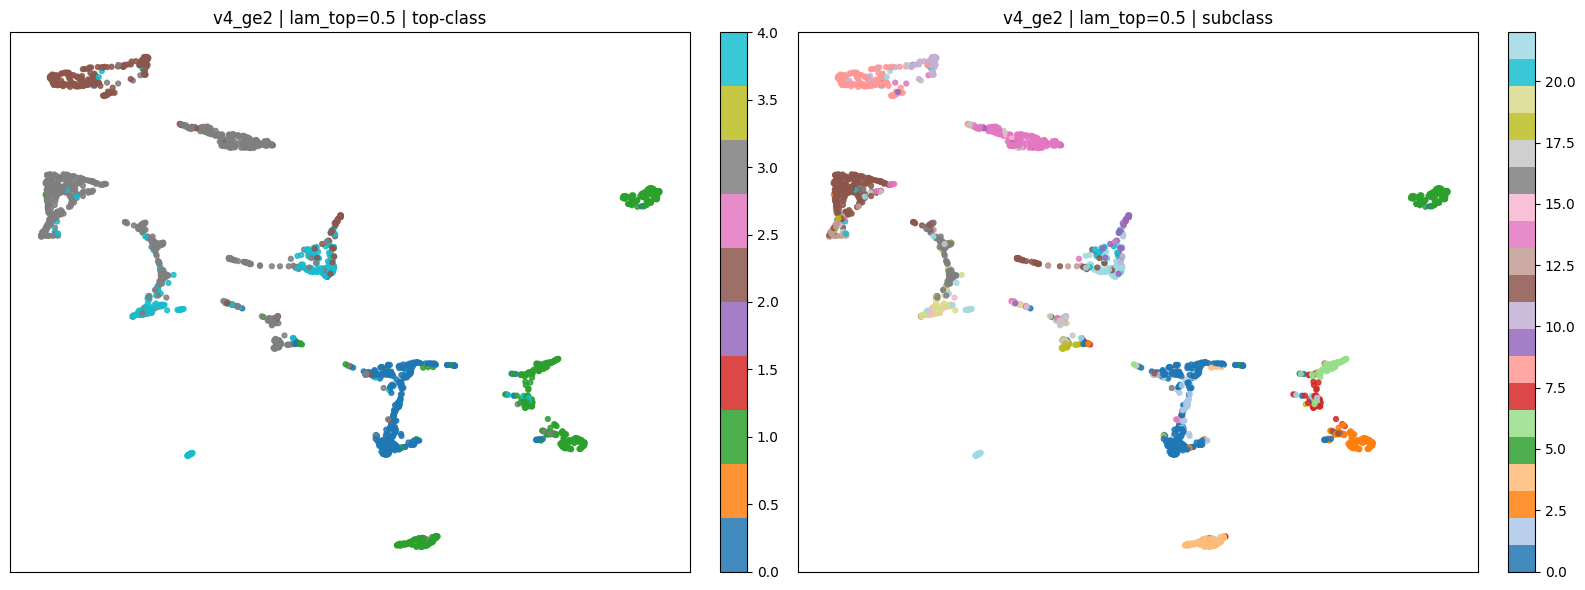

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

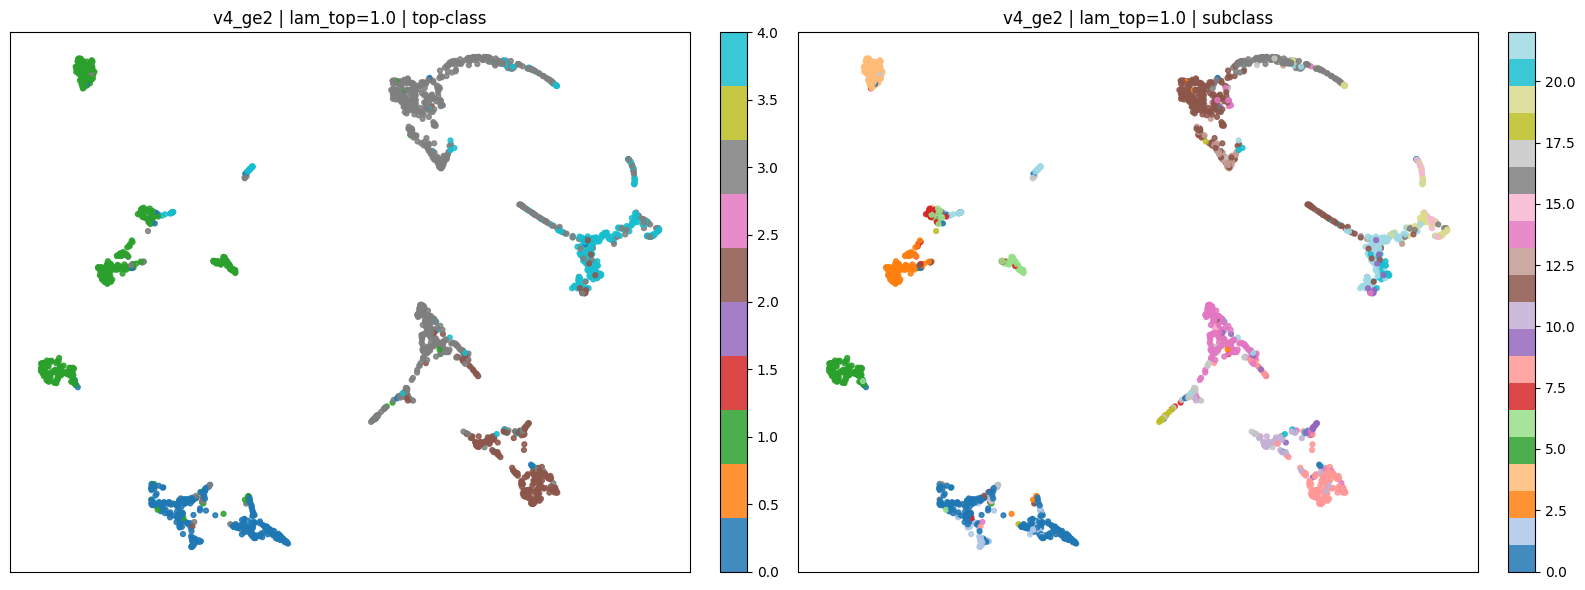

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

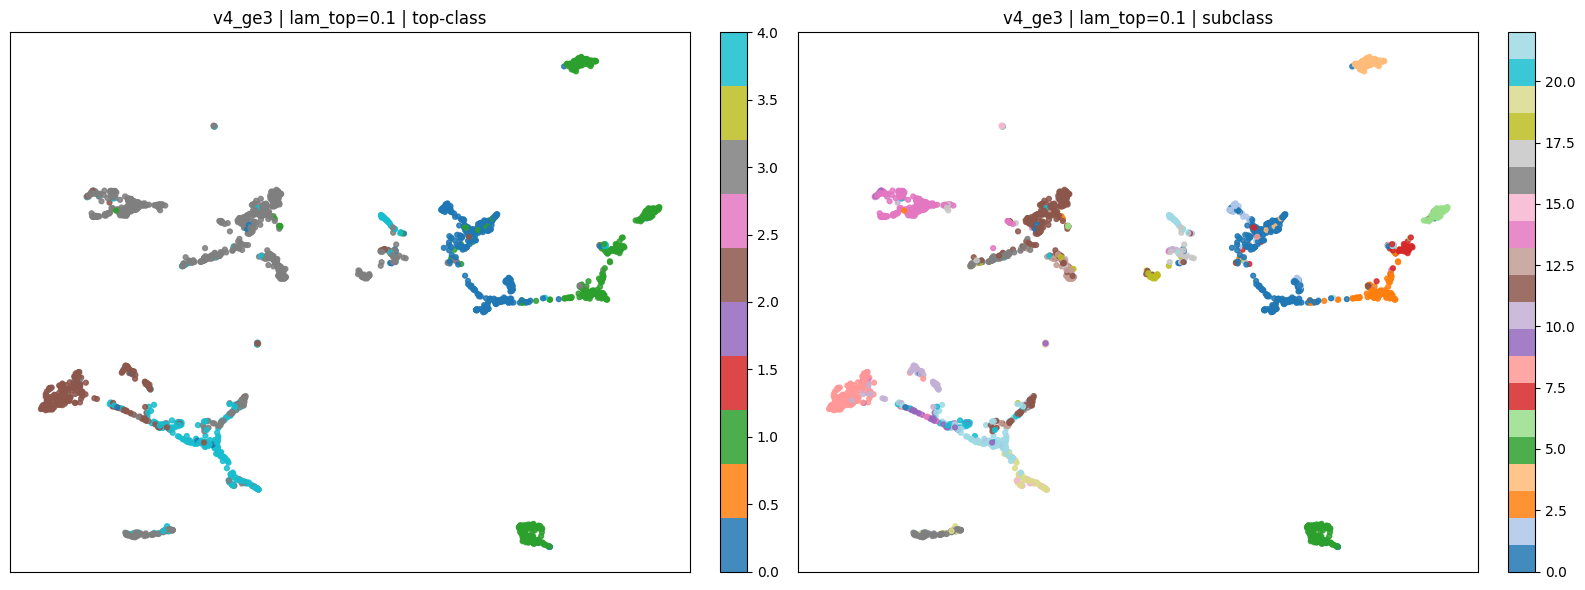

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

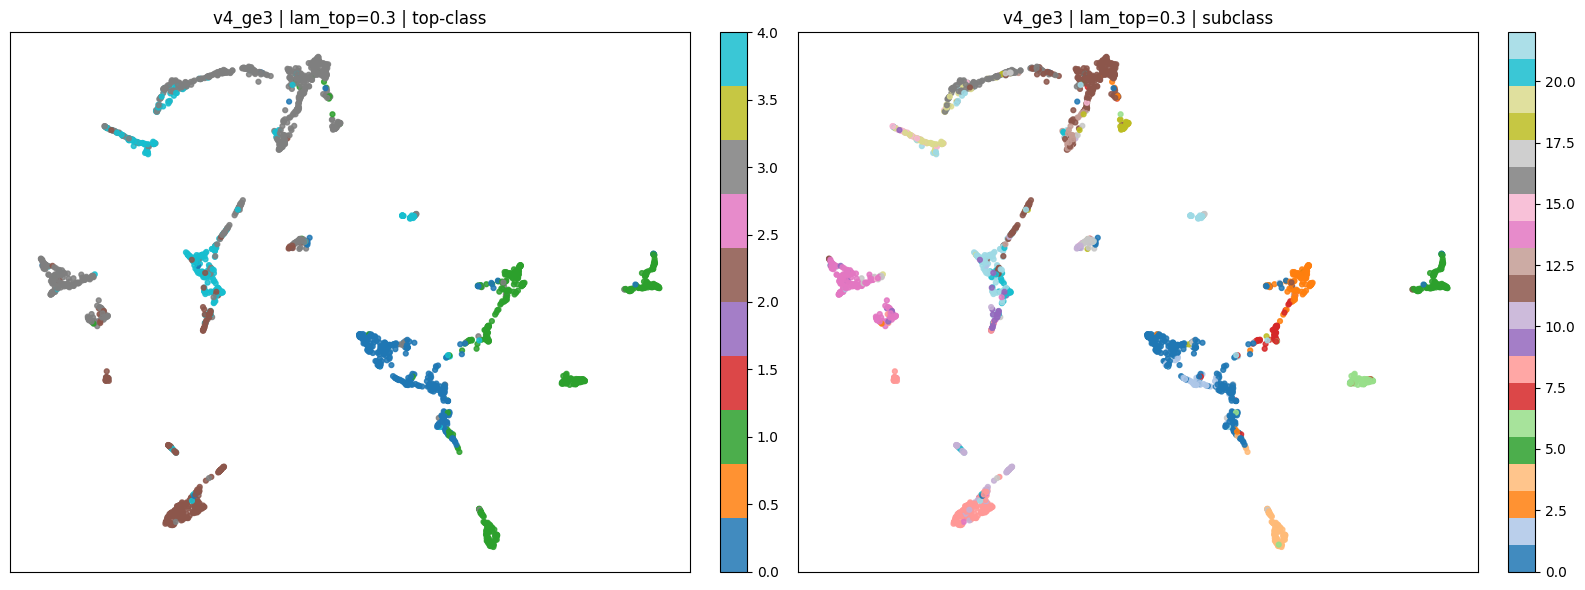

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

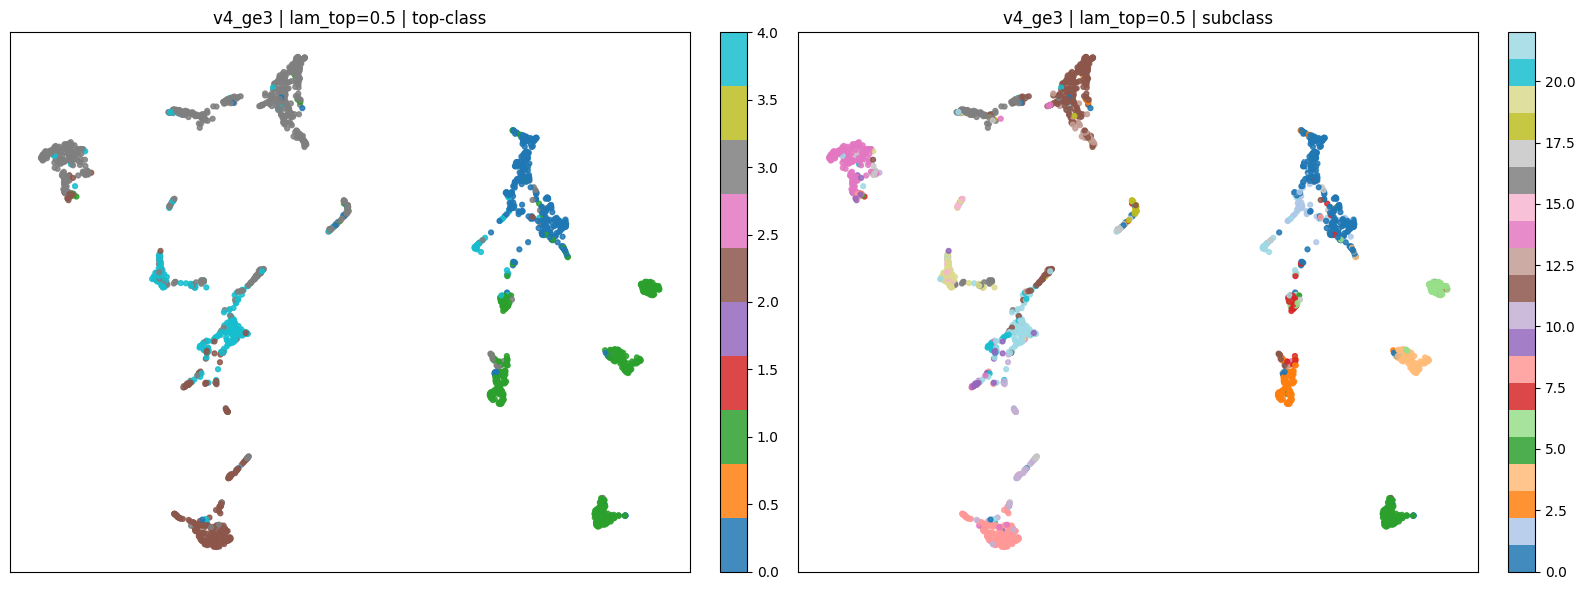

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

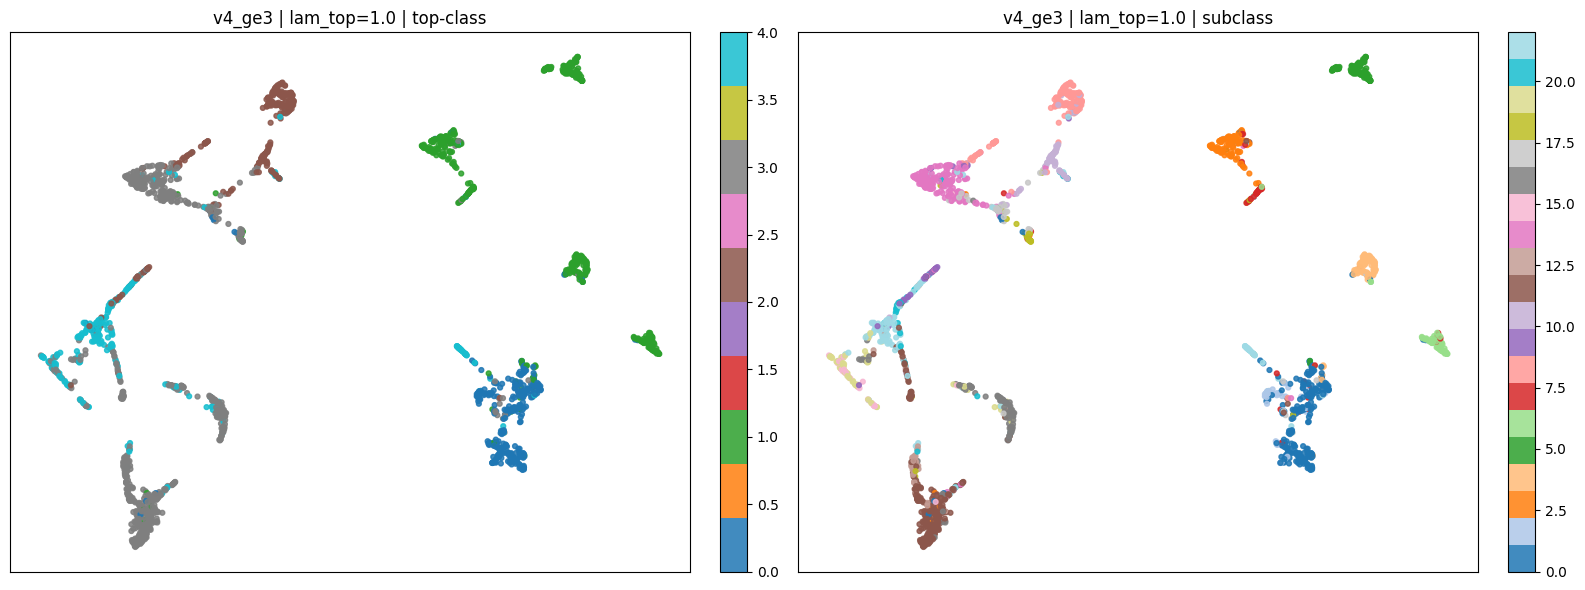

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

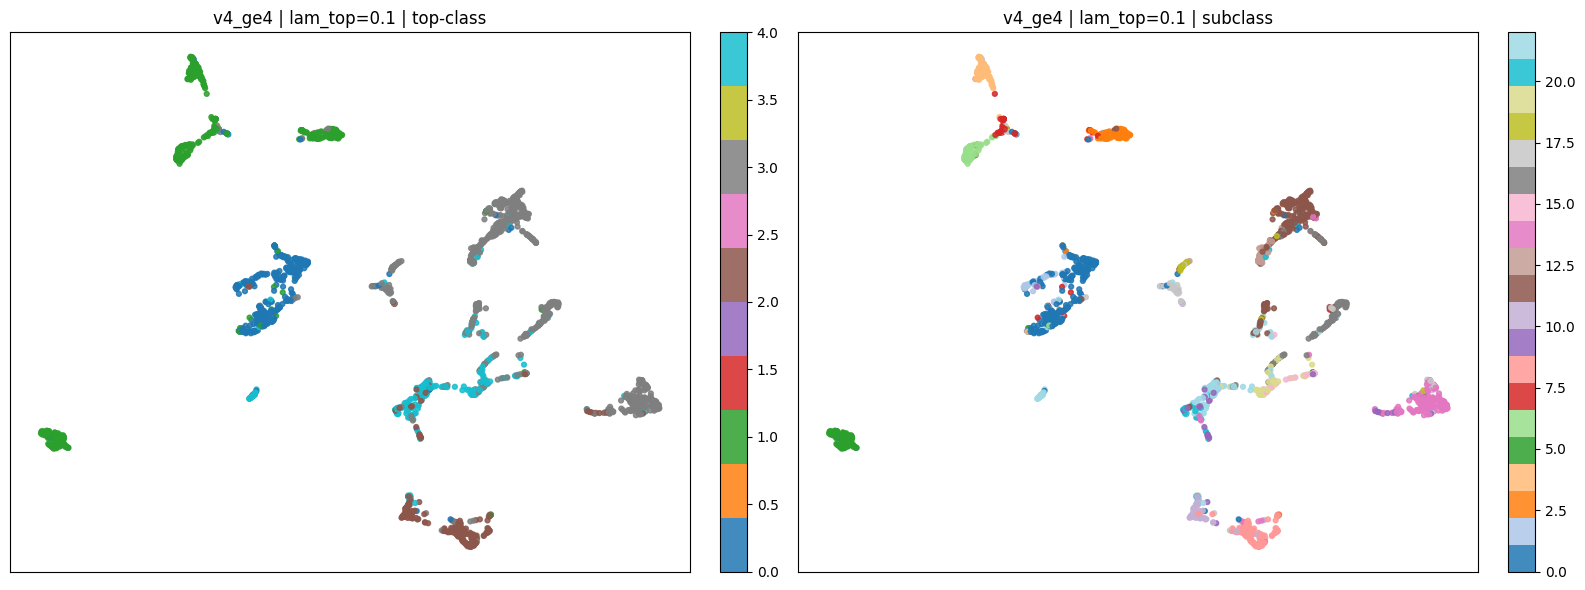

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

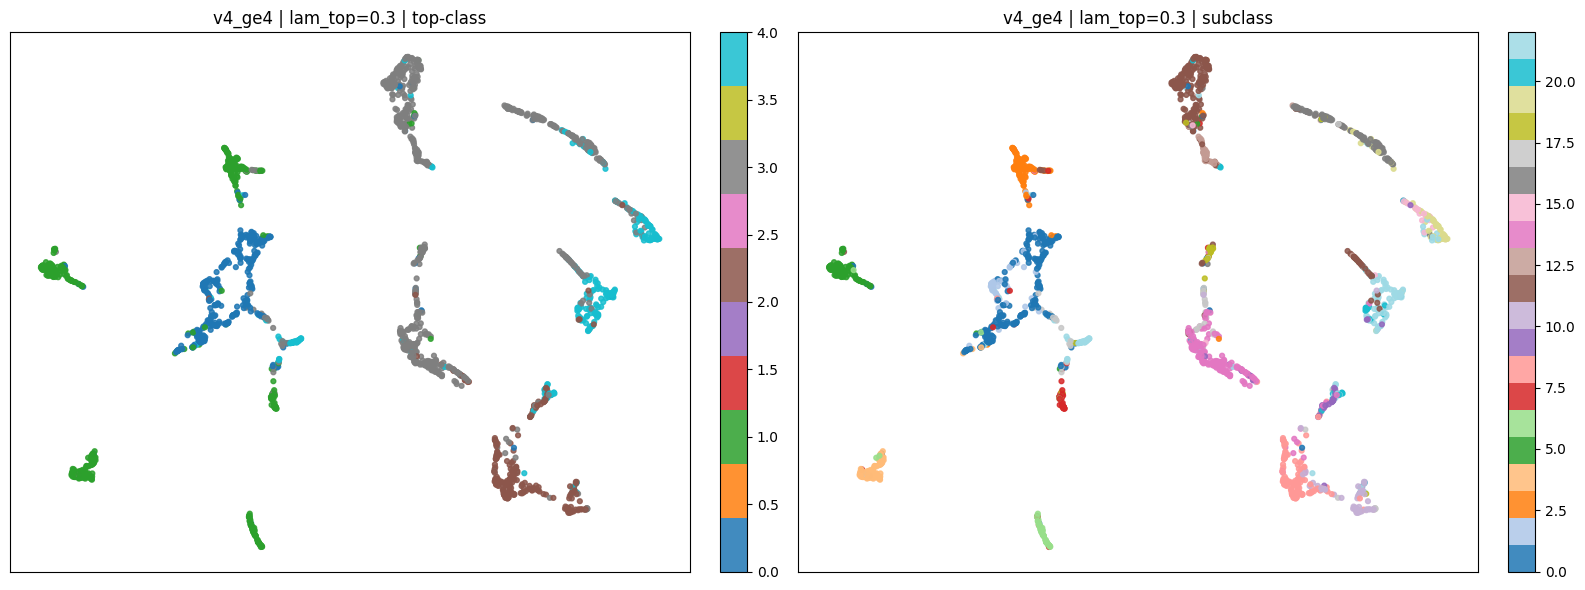

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

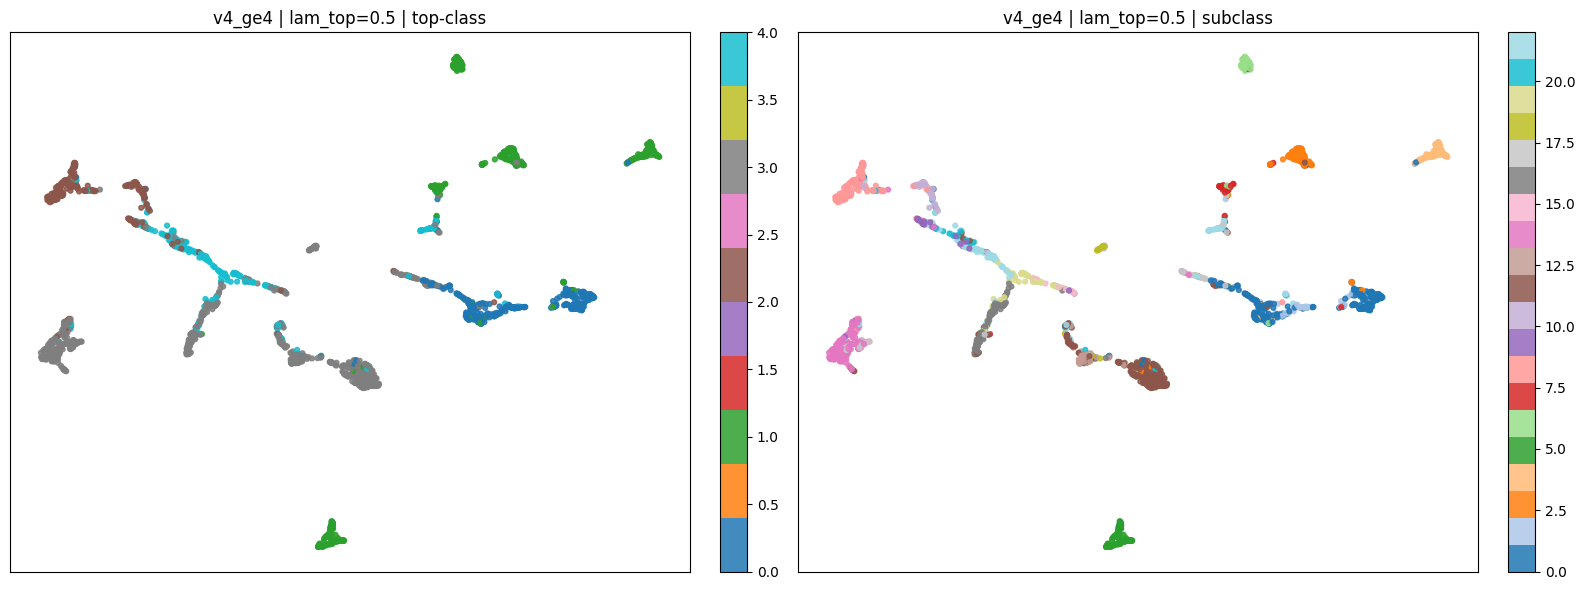

C:\Users\solok\AppData\Local\Temp\ipykernel_2800\1424915890.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)
c:\U

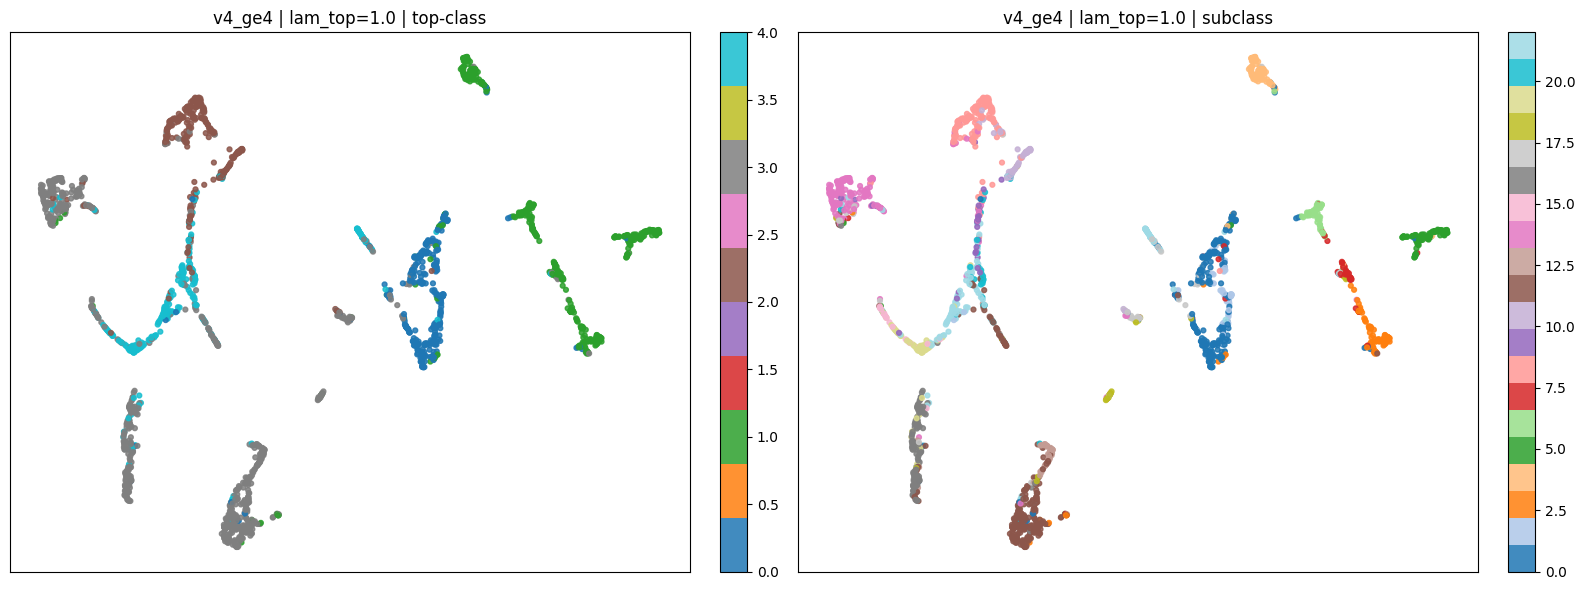

,dataset_label,lam_top,selected_fold,hierarchical_accuracy,plot_path
0,v4_all,0.1,fold_4,77.120000,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,v4_all,0.3,fold_4,77.040000,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,v4_all,0.5,fold_0,76.617329,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,v4_all,1.0,fold_4,77.018337,c:\Users\solok\Desktop\Dcase baseline\baseline...
4,v4_ge2,0.1,fold_0,78.279730,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,v4_ge2,0.3,fold_0,78.044718,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,v4_ge2,0.5,fold_1,77.870538,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,v4_ge2,1.0,fold_3,76.612241,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,v4_ge3,0.1,fold_1,78.760757,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,v4_ge3,0.3,fold_4,77.902726,c:\Users\solok\Desktop\Dcase baseline\baseline...


In [13]:
try:
    import umap
except ImportError as exc:
    raise ImportError('UMAP visualization needs umap-learn. Install with: python -m pip install umap-learn') from exc

@torch.no_grad()
def collect_latent_embeddings(model_path: str | Path, data_df: pd.DataFrame):
    checkpoint = torch.load(model_path, map_location=device)
    config = checkpoint['config']
    model = BaseClassifier(**config).to(device)
    model.load_state_dict(checkpoint['model_state'])
    model.eval()
    loader = cbc.build_loader(data_df, batch_size=BATCH_SIZE, shuffle=False, aug=False)
    zs, ys, tops = [], [], []
    for batch in loader:
        audio_emb = batch.get('audio_embedding', None)
        text_emb = batch.get('text_embedding', None)
        if audio_emb is not None:
            audio_emb = audio_emb.to(device)
        if text_emb is not None:
            text_emb = text_emb.to(device)
        z, _, _ = model(audio_emb, text_emb)
        zs.append(z.detach().cpu().numpy())
        ys.extend(batch['class_idx'].detach().cpu().numpy().tolist())
        tops.extend(batch['top_class_idx'].detach().cpu().numpy().tolist())
    return np.vstack(zs), np.asarray(ys), np.asarray(tops)

idx_to_class = {v: k for k, v in class_dict.items()}
idx_to_top = {v: k for k, v in top_class_dict.items()}

best_umap_rows = []
for (dataset_label, lam_top), group in summary.groupby(['dataset_label', 'lam_top'], sort=False):
    best_idx = pd.to_numeric(group['hierarchical_accuracy'], errors='coerce').idxmax()
    best = summary.loc[best_idx]
    model_path = Path(best['output_dir']) / 'best_model.pth'
    if not model_path.exists():
        print('[skip] missing model:', model_path)
        continue
    z, y, top_y = collect_latent_embeddings(model_path, final_test)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=SEED)
    emb2 = reducer.fit_transform(z)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sc0 = axes[0].scatter(emb2[:, 0], emb2[:, 1], c=top_y, s=12, cmap='tab10', alpha=0.85)
    axes[0].set_title(f'{dataset_label} | lam_top={lam_top} | top-class')
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    sc1 = axes[1].scatter(emb2[:, 0], emb2[:, 1], c=y, s=12, cmap='tab20', alpha=0.85)
    axes[1].set_title(f'{dataset_label} | lam_top={lam_top} | subclass')
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    fig.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)
    fig.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)
    fig.tight_layout()
    lam_tag = format_lam_top(lam_top)
    save_path = PLOTS_DIR / f'umap_final_test_{dataset_label}_{lam_tag}.png'
    fig.savefig(save_path, dpi=180, bbox_inches='tight')
    plt.show()
    best_umap_rows.append({
        'dataset_label': dataset_label,
        'lam_top': float(lam_top),
        'selected_fold': best['split'],
        'hierarchical_accuracy': best['hierarchical_accuracy'],
        'plot_path': str(save_path),
    })

umap_manifest = pd.DataFrame(best_umap_rows)
umap_manifest.to_csv(OUTPUT_ROOT / 'umap_final_test_manifest.csv', index=False)
display(umap_manifest)

## 11. Quick interpretation table

Use this table to compare:

- `v4_ge2/ge3/ge4` trend: how strictness trades off data amount and downstream performance.

In [14]:
ranked = fold_summary.sort_values('hierarchical_accuracy_mean', ascending=False).reset_index(drop=True)
display_cols = [
    'dataset_label', 'lam_top', 'added_bsd35k_samples', 'fold_count',
    'accuracy_mean', 'accuracy_std',
    'hierarchical_accuracy_mean', 'hierarchical_accuracy_std',
    'hierarchical_f1_mean', 'hierarchical_f1_std',
    'macro_accuracy_mean', 'macro_accuracy_std',
]
ranked[display_cols].to_csv(OUTPUT_ROOT / 'ranked_compact_summary.csv', index=False)
display(ranked[display_cols])

,dataset_label,lam_top,added_bsd35k_samples,fold_count,accuracy_mean,accuracy_std,hierarchical_accuracy_mean,hierarchical_accuracy_std,hierarchical_f1_mean,hierarchical_f1_std,macro_accuracy_mean,macro_accuracy_std
0,v4_ge4,0.5,7633,5,79.662409,0.702614,79.450552,0.766692,78.290503,0.745021,74.030002,0.827784
1,v4_ge4,0.3,7633,5,79.890511,0.436862,79.122119,0.865152,78.165277,0.839184,73.840064,1.115461
2,v4_ge4,0.1,7633,5,79.434307,0.529472,79.025241,0.322488,77.872979,0.487608,73.585483,0.642225
3,v4_ge4,1.0,7633,5,79.151460,0.707485,78.595527,1.030591,77.539512,1.060118,73.054353,1.066603
4,v4_ge3,0.5,15566,5,78.448905,0.386564,78.002338,0.489530,76.782074,0.551427,72.264060,0.475287
5,v4_ge3,0.1,15566,5,78.494526,0.469248,77.970971,0.558272,76.864766,0.586467,72.298309,0.800169
6,v4_ge3,0.3,15566,5,78.093066,0.792405,77.667437,0.179175,76.452707,0.257702,71.807108,0.216336
7,v4_ge2,0.5,23851,5,78.275547,0.455520,77.430881,0.518306,76.420406,0.492297,71.749622,0.679104
8,v4_ge3,1.0,15566,5,77.892336,0.520753,77.352623,0.443460,76.071328,0.563800,71.700809,0.685664
9,v4_ge2,0.1,23851,5,77.363139,0.796335,77.208175,0.892042,75.987345,0.821704,71.427653,0.989892
